# Guia Completa de Limpieza y Preprocesamiento de Datos

<div style="background: linear-gradient(135deg, #2c3e50 0%, #3498db 100%); padding: 30px; border-radius: 10px; color: white; margin-bottom: 20px;">
<h2 style="color: white; margin-top: 0;">El 80% del tiempo de un Data Scientist se dedica a limpiar y preparar datos</h2>
<p style="font-size: 16px;">Un modelo de Machine Learning es tan bueno como los datos que lo alimentan. Datos sucios producen modelos deficientes, sin importar cuan sofisticado sea el algoritmo. Esta guia cubre <strong>todas</strong> las tecnicas esenciales de limpieza y preprocesamiento en un solo lugar.</p>
</div>

---

## Tabla de Contenidos

| # | Seccion | Descripcion |
|---|---------|-------------|
| 0 | **Configuracion y Dataset** | Imports, estilos, creacion del dataset sintetico "sucio" |
| 1 | **Pipeline de Limpieza** | Diagrama de flujo de las 6 etapas + checklist de calidad |
| 2 | **Exploracion Inicial** | info(), describe(), tipos, visualizacion de nulos |
| 3 | **Valores Nulos** | MCAR/MAR/MNAR, estrategias de imputacion, comparacion visual |
| 4 | **Duplicados** | Deteccion y eliminacion de registros duplicados |
| 5 | **Outliers** | IQR, Z-score, MAD, Isolation Forest, winsorizar vs eliminar |
| 6 | **Tipos y Validacion** | Conversion de tipos, parseo de fechas, validacion con regex |
| 7 | **Encoding Categorico** | Label, One-Hot, Ordinal, Target, Frequency Encoding |
| 8 | **Escalado y Normalizacion** | MinMax, Standard, Robust, MaxAbs, PowerTransformer |
| 9 | **Feature Engineering** | Fechas, binning, ratios, transformacion logaritmica |
| 10 | **Pipelines de sklearn** | Pipeline + ColumnTransformer, ejemplo completo |
| 11 | **SQL vs Python** | Tabla comparativa, mismo ejemplo en ambos lenguajes |
| 12 | **Checklist Final** | Verificacion pre-modelo, tabla resumen de todas las tecnicas |

---

### Por que importa la limpieza de datos?

<div style="display: flex; gap: 15px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 200px; background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">Garbage In, Garbage Out</strong><br>
Si los datos de entrada tienen errores, el modelo aprendera patrones incorrectos.
</div>
<div style="flex: 1; min-width: 200px; background: #fdedec; padding: 15px; border-left: 4px solid #e74c3c; border-radius: 5px;">
<strong style="color: #2c3e50;">Costos Reales</strong><br>
IBM estima que los datos de mala calidad cuestan a las empresas $3.1 trillones al anno en EE.UU.
</div>
<div style="flex: 1; min-width: 200px; background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Mejora Directa</strong><br>
Limpiar datos suele mejorar el rendimiento del modelo mas que cambiar el algoritmo.
</div>
</div>

In [1]:
# === IMPORTS Y CONFIGURACION ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   MaxAbsScaler, LabelEncoder, OneHotEncoder,
                                   OrdinalEncoder, PowerTransformer)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy import stats
from IPython.display import display, HTML

# Estilos
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))
plt.style.use('seaborn-v0_8-whitegrid')

C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'

# === CREAR DATASET SINTETICO "SUCIO" ===
np.random.seed(42)
n = 500

df_dirty = pd.DataFrame({
    'id': range(1, n + 1),
    'nombre': np.random.choice(
        ['Juan Garcia', 'MARIA LOPEZ', '  pedro martinez  ', 'Ana Torres',
         'LUIS sanchez', None, 'pedro Martinez'], n),
    'edad': np.where(np.random.random(n) < 0.1, np.nan,
                     np.random.normal(35, 12, n).astype(int)),
    'salario': np.where(np.random.random(n) < 0.08, np.nan,
                        np.random.lognormal(10.5, 0.5, n)),
    'departamento': np.random.choice(
        ['Ventas', 'ventas', 'VENTAS', 'IT', 'it', 'Marketing', 'RRHH', None], n),
    'fecha_ingreso': [
        f'2020-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}'
        if np.random.random() > 0.1
        else (f'{np.random.randint(1,29)}/{np.random.randint(1,13)}/2020'
              if np.random.random() > 0.5 else None)
        for _ in range(n)
    ],
    'satisfaccion': np.random.choice(
        ['bajo', 'medio', 'alto', 'Bajo', 'ALTO', None], n),
    'evaluacion': np.where(np.random.random(n) < 0.05, np.nan,
                           np.round(np.random.uniform(1, 10, n), 1)),
    'ciudad': np.random.choice(
        ['Madrid', 'Barcelona', 'Sevilla', 'Valencia', 'madrid', 'BARCELONA'], n),
})

# Inyectar outliers
df_dirty.loc[10, 'salario'] = 500000
df_dirty.loc[20, 'edad'] = 150
df_dirty.loc[30, 'edad'] = -5

# Inyectar duplicados (15 filas duplicadas)
df_dirty = pd.concat([df_dirty, df_dirty.iloc[:15]], ignore_index=True)

print(f"Dataset sucio creado: {df_dirty.shape[0]} filas x {df_dirty.shape[1]} columnas")
print(f"Problemas inyectados: nulos, duplicados, outliers, tipos incorrectos, strings inconsistentes, fechas mixtas")
df_dirty.head(10)

Dataset sucio creado: 515 filas x 9 columnas
Problemas inyectados: nulos, duplicados, outliers, tipos incorrectos, strings inconsistentes, fechas mixtas


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
0,1,pedro Martinez,31.0,23073.425589,VENTAS,2020-01-18,None,5.0,Sevilla
1,2,Ana Torres,29.0,61594.486576,RRHH,2020-04-21,ALTO,5.3,madrid
2,3,LUIS sanchez,42.0,45608.292605,None,2020-04-01,Bajo,2.9,Valencia
3,4,pedro Martinez,53.0,21144.784963,ventas,2020-10-26,ALTO,2.0,BARCELONA
4,5,pedro martinez,49.0,18697.442936,IT,2020-04-23,None,8.5,Valencia
5,6,LUIS sanchez,43.0,36029.385374,RRHH,2020-11-09,None,5.5,Valencia
6,7,LUIS sanchez,27.0,55550.455489,RRHH,None,medio,1.1,BARCELONA
7,8,pedro Martinez,32.0,56266.686851,Marketing,2020-02-24,ALTO,8.2,BARCELONA
8,9,MARIA LOPEZ,31.0,43394.302758,ventas,2020-04-05,Bajo,9.8,Madrid
9,10,pedro martinez,29.0,37210.171085,ventas,2020-08-19,Bajo,6.5,Valencia


In [2]:
# === DIAGNOSTICO RAPIDO DEL DATASET SUCIO ===
print("=" * 60)
print("  DIAGNOSTICO RAPIDO: Todos los problemas detectados")
print("=" * 60)

problemas = {
    'Valores nulos': df_dirty.isnull().sum().sum(),
    'Filas duplicadas': df_dirty.duplicated().sum(),
    'Columnas tipo object': (df_dirty.dtypes == 'object').sum(),
    'Valores unicos en nombre': df_dirty['nombre'].nunique(),
    'Valores unicos en departamento': df_dirty['departamento'].nunique(),
    'Edades negativas': (df_dirty['edad'] < 0).sum(),
    'Edades > 120': (df_dirty['edad'] > 120).sum(),
    'Formatos de fecha distintos': 'Multiples (YYYY-MM-DD y DD/MM/YYYY)',
}

for problema, valor in problemas.items():
    print(f"  {problema:.<45} {valor}")

print(f"\nEl dataset tiene {len(problemas)} tipos de problemas que debemos resolver.")

  DIAGNOSTICO RAPIDO: Todos los problemas detectados
  Valores nulos................................ 372
  Filas duplicadas............................. 15
  Columnas tipo object......................... 5
  Valores unicos en nombre..................... 6
  Valores unicos en departamento............... 7
  Edades negativas............................. 1
  Edades > 120................................. 1
  Formatos de fecha distintos.................. Multiples (YYYY-MM-DD y DD/MM/YYYY)

El dataset tiene 8 tipos de problemas que debemos resolver.


---
## Seccion 1: Pipeline de Limpieza de Datos

<div style="background: #eaf2f8; padding: 20px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">El proceso de limpieza no es lineal ni unico.</strong> Sin embargo, seguir un pipeline estructurado asegura que no se omitan pasos criticos. Cada etapa depende de la anterior: no tiene sentido escalar datos si aun contienen nulos o duplicados.
</div>

### Las 6 Etapas del Pipeline

1. **Datos Crudos (Raw):** El dataset tal como fue recolectado, con todos sus defectos.
2. **Explorar:** Entender la estructura, tipos, distribuciones, y detectar problemas.
3. **Limpiar:** Eliminar nulos, duplicados, corregir errores de formato y strings.
4. **Transformar:** Encoding categorico, escalado numerico, normalizacion.
5. **Feature Engineering:** Crear nuevas variables a partir de las existentes.
6. **Modelo:** Datos listos para entrenar un modelo de ML.

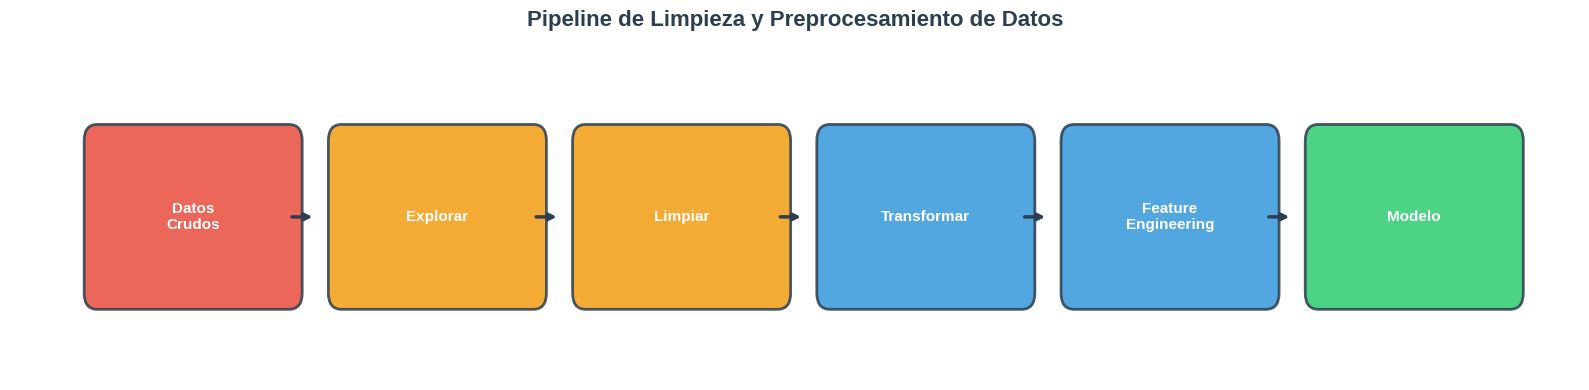

  CHECKLIST DE CALIDAD DE DATOS - 10 PREGUNTAS ESENCIALES
  [ ] 1. Hay valores nulos? En que columnas y que porcentaje?
  [ ] 2. Existen filas duplicadas exactas o casi-duplicadas?
  [ ] 3. Los tipos de datos son correctos (numerico, fecha, categorico)?
  [ ] 4. Hay outliers que podrian distorsionar el analisis?
  [ ] 5. Los strings son consistentes (mayusculas, espacios, acentos)?
  [ ] 6. Los rangos de valores son logicos (edad > 0, salario > 0)?
  [ ] 7. Las fechas tienen un formato uniforme?
  [ ] 8. Las categorias estan normalizadas (sin duplicados por variacion)?
  [ ] 9. Las distribuciones son razonables para cada variable?
  [ ] 10. Hay data leakage potencial (informacion del futuro en el training set)?


In [3]:
# === DIAGRAMA DEL PIPELINE DE LIMPIEZA ===
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 18)
ax.set_ylim(0, 3)
ax.axis('off')
ax.set_title('Pipeline de Limpieza y Preprocesamiento de Datos', fontsize=16,
             fontweight='bold', color=C_DARK, pad=20)

etapas = [
    ('Datos\nCrudos', C_DANGER),
    ('Explorar', C_ORANGE),
    ('Limpiar', C_ORANGE),
    ('Transformar', C_PRIMARY),
    ('Feature\nEngineering', C_PRIMARY),
    ('Modelo', C_SUCCESS),
]

for i, (nombre, color) in enumerate(etapas):
    x = 1 + i * 2.8
    rect = mpatches.FancyBboxPatch((x, 0.8), 2.2, 1.4, boxstyle="round,pad=0.15",
                                    facecolor=color, edgecolor=C_DARK, linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + 1.1, 1.5, nombre, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    if i < len(etapas) - 1:
        ax.annotate('', xy=(x + 2.5, 1.5), xytext=(x + 2.2, 1.5),
                     arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2.5))

plt.tight_layout()
plt.show()

# === CHECKLIST DE 10 PREGUNTAS DE CALIDAD ===
preguntas = [
    "1. Hay valores nulos? En que columnas y que porcentaje?",
    "2. Existen filas duplicadas exactas o casi-duplicadas?",
    "3. Los tipos de datos son correctos (numerico, fecha, categorico)?",
    "4. Hay outliers que podrian distorsionar el analisis?",
    "5. Los strings son consistentes (mayusculas, espacios, acentos)?",
    "6. Los rangos de valores son logicos (edad > 0, salario > 0)?",
    "7. Las fechas tienen un formato uniforme?",
    "8. Las categorias estan normalizadas (sin duplicados por variacion)?",
    "9. Las distribuciones son razonables para cada variable?",
    "10. Hay data leakage potencial (informacion del futuro en el training set)?",
]

print("=" * 65)
print("  CHECKLIST DE CALIDAD DE DATOS - 10 PREGUNTAS ESENCIALES")
print("=" * 65)
for p in preguntas:
    print(f"  [ ] {p}")
print("=" * 65)

### Importancia del orden en el pipeline

<div style="display: flex; gap: 15px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 200px; background: #fdedec; padding: 15px; border-left: 4px solid #e74c3c; border-radius: 5px;">
<strong style="color: #2c3e50;">Orden incorrecto</strong><br>
Si escalamos antes de imputar nulos, el scaler calculara media/std con NaN y fallara. Si hacemos encoding antes de normalizar strings, "Ventas" y "ventas" seran categorias diferentes.
</div>
<div style="flex: 1; min-width: 200px; background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Orden correcto</strong><br>
1. Normalizar strings -> 2. Eliminar duplicados -> 3. Tratar nulos -> 4. Tratar outliers -> 5. Encoding -> 6. Escalado. Cada paso depende de que el anterior se haya completado correctamente.
</div>
</div>

---
## Seccion 2: Exploracion Inicial del Dataset

<div style="background: #fef9e7; padding: 20px; border-left: 4px solid #f39c12; border-radius: 5px;">
<strong style="color: #2c3e50;">Antes de limpiar, hay que entender.</strong> La exploracion inicial responde: cuantas filas y columnas hay? que tipos de datos tiene cada columna? cuantos nulos existen? como se distribuyen las variables numericas?
</div>

### Herramientas clave de exploracion en Pandas

| Metodo | Que muestra |
|--------|-------------|
| `df.shape` | Dimensiones (filas, columnas) |
| `df.dtypes` | Tipo de dato de cada columna |
| `df.info()` | Resumen completo: tipos, nulos, memoria |
| `df.describe()` | Estadisticas descriptivas de columnas numericas |
| `df.isnull().sum()` | Conteo de nulos por columna |
| `df.duplicated().sum()` | Numero de filas duplicadas |
| `df.nunique()` | Valores unicos por columna |

### Interpretacion de describe() y dtypes

<div style="background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">

**Lo que `describe()` nos dice:**
- **count**: cuantos valores no-nulos hay (si count < total filas, hay nulos)
- **mean**: media aritmetica (sensible a outliers)
- **std**: desviacion estandar (dispersion de los datos)
- **min/max**: valores extremos (revisar si son logicos)
- **25%/50%/75%**: cuartiles (la mediana es el 50%)
- **Si mean >> median**: la distribucion esta sesgada a la derecha (outliers altos)

**Lo que `dtypes` nos dice:**
- **float64**: numerico con decimales (puede tener NaN)
- **int64**: entero (no puede tener NaN en versiones antiguas de pandas)
- **object**: texto o mezcla de tipos (revisar si deberia ser numerico o fecha)
- **datetime64**: fecha/hora correctamente parseada
- **category**: categorica optimizada en memoria
</div>

  EXPLORACION DEL DATASET SUCIO

--- Dimensiones: 515 filas x 9 columnas ---

--- Tipos de datos ---
id                 int64
nombre            object
edad             float64
salario          float64
departamento      object
fecha_ingreso     object
satisfaccion      object
evaluacion       float64
ciudad            object
dtype: object

--- Info del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             515 non-null    int64  
 1   nombre         442 non-null    object 
 2   edad           462 non-null    float64
 3   salario        482 non-null    float64
 4   departamento   454 non-null    object 
 5   fecha_ingreso  487 non-null    object 
 6   satisfaccion   424 non-null    object 
 7   evaluacion     482 non-null    float64
 8   ciudad         515 non-null    object 
dtypes: float64(3), int64(1), object(5)
memo

,id,edad,salario,evaluacion
count,515.000000,462.000000,482.000000,482.000000
mean,243.436893,35.774892,42939.377719,5.503112
std,148.096264,13.931549,36333.199836,2.495745
min,1.000000,-5.000000,9348.267862,1.000000
25%,114.500000,27.000000,25819.231849,3.400000
50%,243.000000,34.000000,36818.698897,5.500000
75%,371.500000,44.000000,50502.829992,7.600000
max,500.000000,150.000000,500000.000000,10.000000



--- Conteo de valores nulos por columna ---


,Nulos,Porcentaje (%)
satisfaccion,91,17.67
nombre,73,14.17
departamento,61,11.84
edad,53,10.29
salario,33,6.41
evaluacion,33,6.41
fecha_ingreso,28,5.44



--- Filas duplicadas: 15 ---
--- Valores unicos por columna ---


id               500
nombre             6
edad              67
salario          467
departamento       7
fecha_ingreso    275
satisfaccion       5
evaluacion        91
ciudad             6
dtype: int64

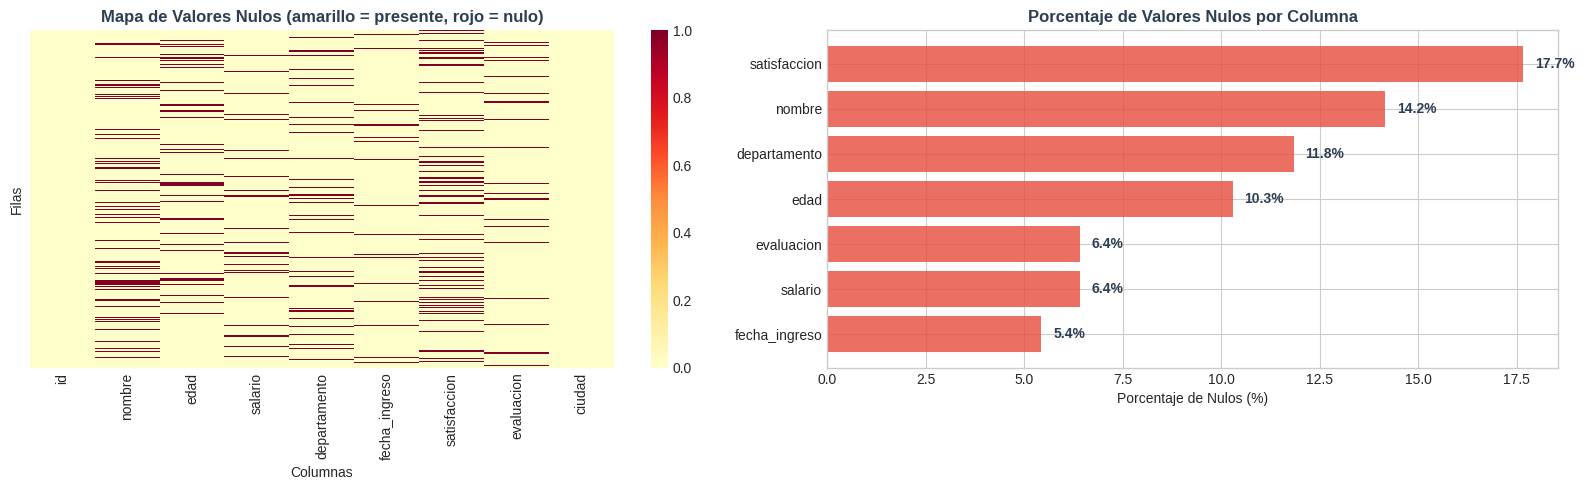

In [4]:
# === EXPLORACION INICIAL ===
print("=" * 60)
print("  EXPLORACION DEL DATASET SUCIO")
print("=" * 60)

print(f"\n--- Dimensiones: {df_dirty.shape[0]} filas x {df_dirty.shape[1]} columnas ---\n")

print("--- Tipos de datos ---")
print(df_dirty.dtypes)

print("\n--- Info del DataFrame ---")
df_dirty.info()

print("\n--- Estadisticas descriptivas (numericas) ---")
display(df_dirty.describe())

print("\n--- Conteo de valores nulos por columna ---")
nulos = df_dirty.isnull().sum()
nulos_pct = (df_dirty.isnull().sum() / len(df_dirty) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
display(resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False))

print(f"\n--- Filas duplicadas: {df_dirty.duplicated().sum()} ---")
print(f"--- Valores unicos por columna ---")
display(df_dirty.nunique())

# === HEATMAP DE VALORES NULOS ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap de nulos
sns.heatmap(df_dirty.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Mapa de Valores Nulos (amarillo = presente, rojo = nulo)', 
                  fontsize=12, fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Columnas')
axes[0].set_ylabel('Filas')

# Barplot de porcentaje de nulos
cols_con_nulos = nulos_pct[nulos_pct > 0].sort_values(ascending=True)
bars = axes[1].barh(cols_con_nulos.index, cols_con_nulos.values, color=C_DANGER, alpha=0.8)
axes[1].set_xlabel('Porcentaje de Nulos (%)')
axes[1].set_title('Porcentaje de Valores Nulos por Columna',
                  fontsize=12, fontweight='bold', color=C_DARK)
for bar, val in zip(bars, cols_con_nulos.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.show()

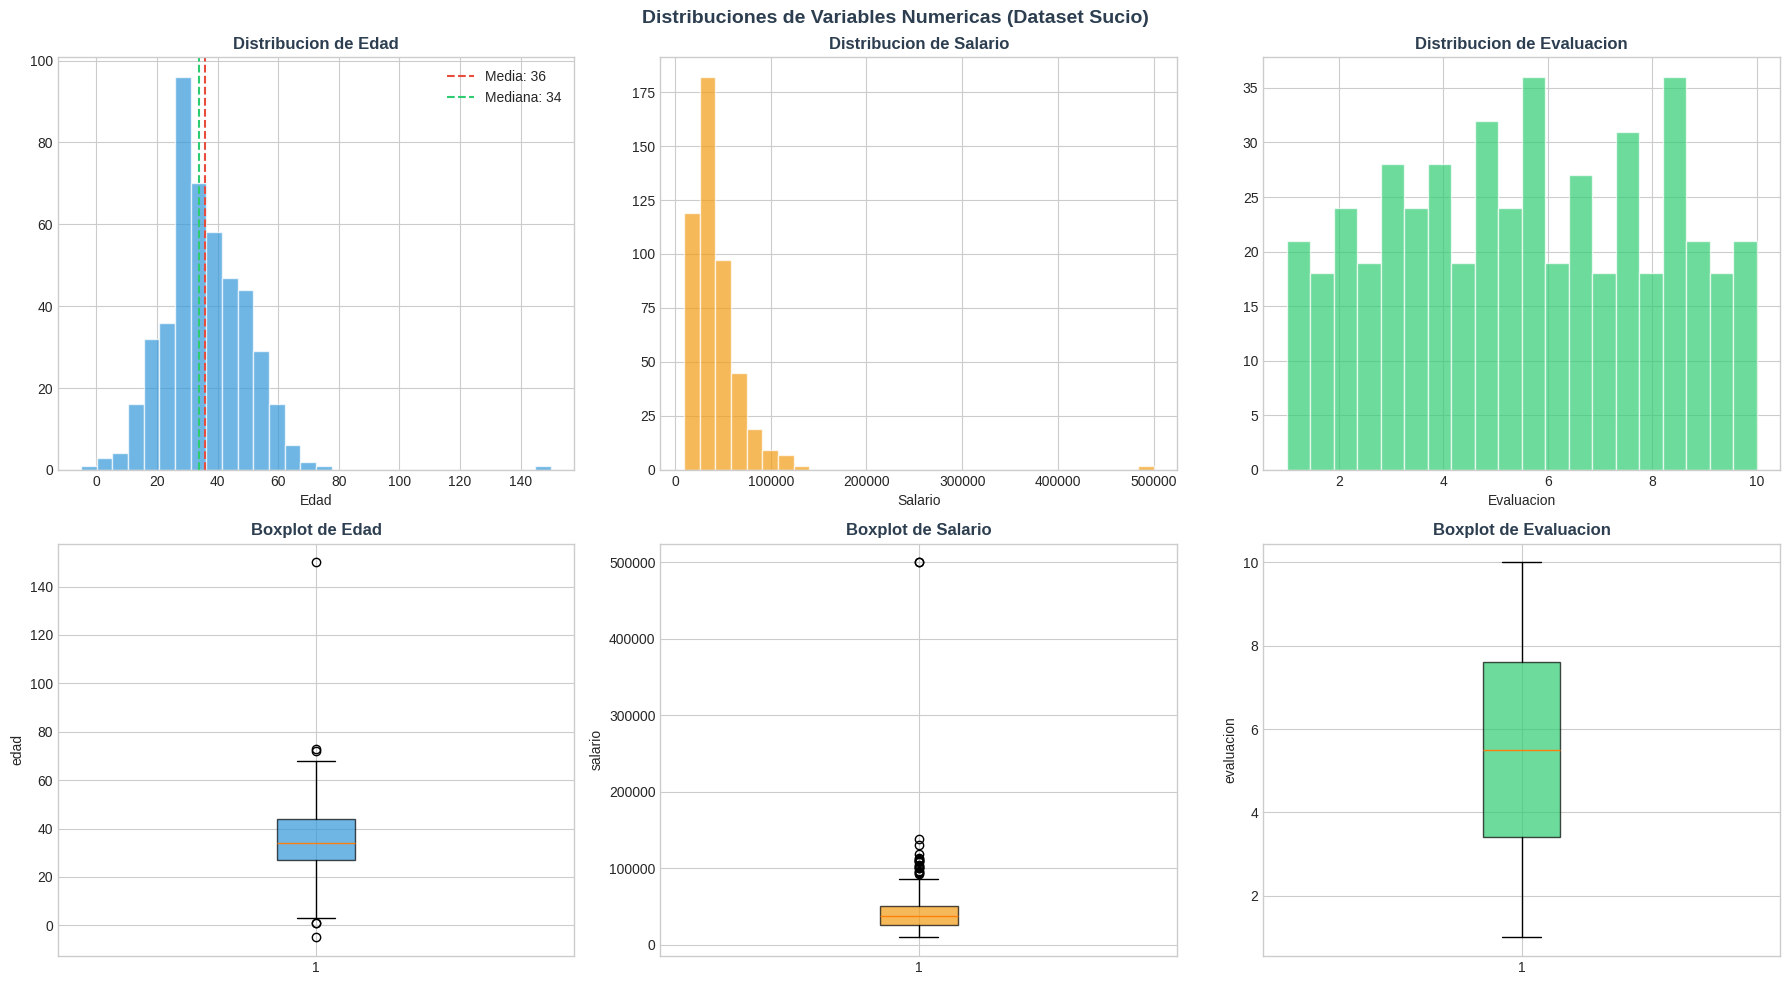


--- Distribucion de variables categoricas ---

departamento:
departamento
IT           74
Ventas       71
ventas       66
VENTAS       65
it           63
Marketing    58
RRHH         57
Name: count, dtype: int64

satisfaccion:
satisfaccion
Bajo     107
ALTO      86
alto      86
medio     77
bajo      68
Name: count, dtype: int64

ciudad:
ciudad
madrid       93
BARCELONA    92
Sevilla      86
Valencia     85
Barcelona    84
Madrid       75
Name: count, dtype: int64


In [5]:
# === EXPLORACION AVANZADA: Distribuciones y correlaciones ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuciones de Variables Numericas (Dataset Sucio)', fontsize=14,
             fontweight='bold', color=C_DARK)

# Histograma de edad
axes[0, 0].hist(df_dirty['edad'].dropna(), bins=30, color=C_PRIMARY, alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Distribucion de Edad', fontweight='bold', color=C_DARK)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].axvline(df_dirty['edad'].mean(), color=C_DANGER, linestyle='--', label=f'Media: {df_dirty["edad"].mean():.0f}')
axes[0, 0].axvline(df_dirty['edad'].median(), color=C_SUCCESS, linestyle='--', label=f'Mediana: {df_dirty["edad"].median():.0f}')
axes[0, 0].legend()

# Histograma de salario
axes[0, 1].hist(df_dirty['salario'].dropna(), bins=30, color=C_ORANGE, alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Distribucion de Salario', fontweight='bold', color=C_DARK)
axes[0, 1].set_xlabel('Salario')

# Histograma de evaluacion
axes[0, 2].hist(df_dirty['evaluacion'].dropna(), bins=20, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[0, 2].set_title('Distribucion de Evaluacion', fontweight='bold', color=C_DARK)
axes[0, 2].set_xlabel('Evaluacion')

# Boxplots
for i, col in enumerate(['edad', 'salario', 'evaluacion']):
    bp = axes[1, i].boxplot(df_dirty[col].dropna(), patch_artist=True,
                             boxprops=dict(facecolor=[C_PRIMARY, C_ORANGE, C_SUCCESS][i], alpha=0.7))
    axes[1, i].set_title(f'Boxplot de {col.title()}', fontweight='bold', color=C_DARK)
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Conteo de categoricas
print("\n--- Distribucion de variables categoricas ---")
for col in ['departamento', 'satisfaccion', 'ciudad']:
    print(f"\n{col}:")
    print(df_dirty[col].value_counts())

---
## Seccion 3: Tratamiento de Valores Nulos

<div style="background: #fdedec; padding: 20px; border-left: 4px solid #e74c3c; border-radius: 5px;">
<strong style="color: #2c3e50;">Los valores nulos son el problema mas comun en datasets reales.</strong> Antes de elegir una estrategia de imputacion, es fundamental entender <em>por que</em> faltan los datos. El mecanismo de ausencia determina la estrategia correcta.
</div>

### Tipos de datos faltantes (Mecanismo de ausencia)

| Tipo | Nombre Completo | Significado | Ejemplo |
|------|----------------|-------------|---------|
| **MCAR** | Missing Completely At Random | La probabilidad de que falte un dato NO depende de ninguna variable (ni observada ni no observada). | Un sensor falla aleatoriamente. |
| **MAR** | Missing At Random | La probabilidad de que falte un dato depende de OTRAS variables observadas, pero no del valor faltante en si. | Los empleados jovenes omiten su salario, pero esto se correlaciona con la edad (que si tenemos). |
| **MNAR** | Missing Not At Random | La probabilidad de que falte un dato depende del PROPIO valor que falta. | Las personas con salarios muy altos no reportan su ingreso precisamente porque es alto. |

### Estrategias de imputacion

| Estrategia | Cuando usarla | Ventaja | Desventaja |
|------------|--------------|---------|------------|
| `dropna()` | Pocos nulos (<5%), MCAR | Simple, no introduce sesgo | Pierde informacion |
| Media | Numerica, MCAR, distribucion simetrica | Simple | Reduce varianza, sesga si no es MCAR |
| Mediana | Numerica, outliers presentes | Robusta a outliers | Reduce varianza |
| Moda | Categorica | Simple | Sesga hacia la categoria mas frecuente |
| `ffill/bfill` | Series temporales | Preserva tendencia | No aplica a datos no ordenados |
| KNN Imputer | MAR, relaciones entre variables | Usa informacion multivariable | Costoso computacionalmente |
| Imputacion por grupo | MAR, variable explicativa clara | Preserva relaciones entre grupos | Requiere variable de agrupacion |

  ANALISIS DEL PATRON DE DATOS FALTANTES

Columnas con nulos: ['nombre', 'edad', 'salario', 'departamento', 'fecha_ingreso', 'satisfaccion', 'evaluacion']

Correlacion entre patrones de nulos:
(Un valor alto indica que los nulos tienden a ocurrir juntos)


,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion
nombre,1.000,0.009,-0.061,-0.011,0.001,0.016,-0.061
edad,0.009,1.000,-0.063,-0.045,-0.025,0.128,0.016
salario,-0.061,-0.063,1.000,-0.022,-0.028,0.024,0.029
departamento,-0.011,-0.045,-0.022,1.000,0.018,0.019,0.027
fecha_ingreso,0.001,-0.025,-0.028,0.018,1.000,-0.044,-0.028
satisfaccion,0.016,0.128,0.024,0.019,-0.044,1.000,-0.038
evaluacion,-0.061,0.016,0.029,0.027,-0.028,-0.038,1.000


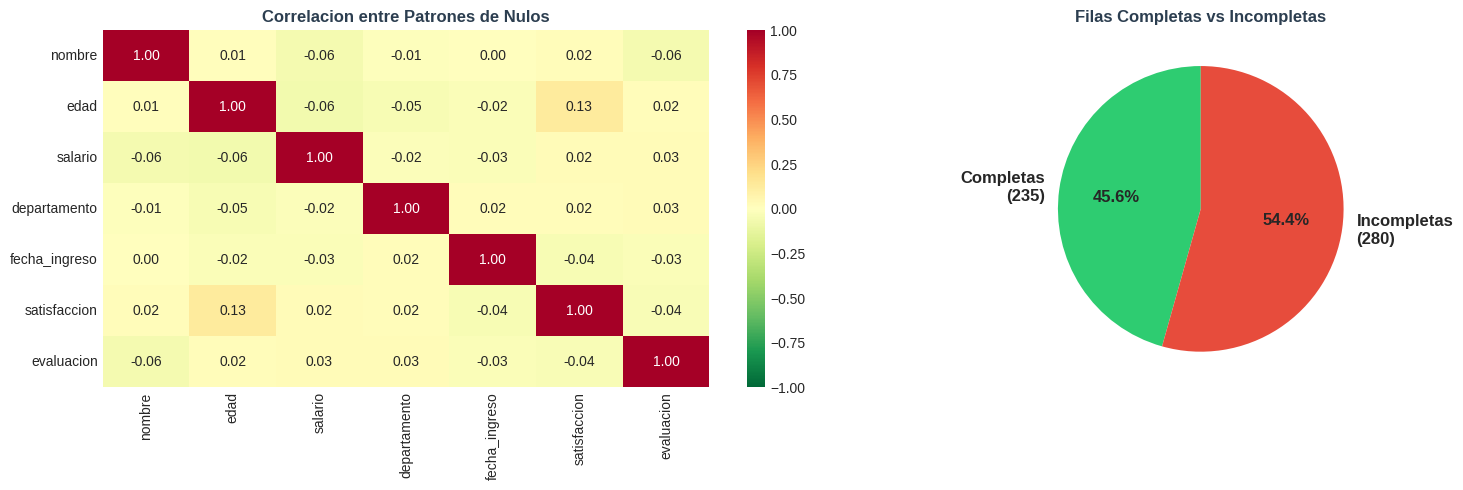

In [6]:
# === DETECTAR PATRON DE DATOS FALTANTES ===
print("=" * 60)
print("  ANALISIS DEL PATRON DE DATOS FALTANTES")
print("=" * 60)

# Correlacion entre nulos (que columnas tienen nulos juntas)
null_cols = df_dirty.columns[df_dirty.isnull().any()]
null_matrix = df_dirty[null_cols].isnull().astype(int)

print(f"\nColumnas con nulos: {list(null_cols)}")
print(f"\nCorrelacion entre patrones de nulos:")
print("(Un valor alto indica que los nulos tienden a ocurrir juntos)")
display(null_matrix.corr().round(3))

# Visualizar patrones de nulidad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Patron de nulos como correlacion
sns.heatmap(null_matrix.corr(), annot=True, cmap='RdYlGn_r', center=0,
            ax=axes[0], fmt='.2f', vmin=-1, vmax=1)
axes[0].set_title('Correlacion entre Patrones de Nulos', fontweight='bold', color=C_DARK)

# Porcentaje de filas completas vs incompletas
n_completas = df_dirty.dropna().shape[0]
n_incompletas = df_dirty.shape[0] - n_completas
axes[1].pie([n_completas, n_incompletas], 
            labels=[f'Completas\n({n_completas})', f'Incompletas\n({n_incompletas})'],
            colors=[C_SUCCESS, C_DANGER], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Filas Completas vs Incompletas', fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.show()

In [7]:
# === ESTRATEGIA 1: ELIMINAR NULOS (dropna) ===
print("=" * 60)
print("  ESTRATEGIA 1: ELIMINAR FILAS/COLUMNAS CON NULOS")
print("=" * 60)

df_work = df_dirty.copy()
print(f"\nANTES: {df_work.shape[0]} filas")
print(f"Nulos en 'edad': {df_work['edad'].isnull().sum()}")
print(f"Nulos en 'salario': {df_work['salario'].isnull().sum()}")

# dropna en filas
df_dropna_rows = df_work.dropna(subset=['edad', 'salario'])
print(f"\nDESPUES (dropna filas en edad+salario): {df_dropna_rows.shape[0]} filas")
print(f"Filas perdidas: {df_work.shape[0] - df_dropna_rows.shape[0]}")

# dropna con threshold
df_dropna_thresh = df_work.dropna(thresh=7)  # al menos 7 valores no nulos por fila
print(f"\nDESPUES (thresh=7, minimo 7 no-nulos): {df_dropna_thresh.shape[0]} filas")

# === ESTRATEGIA 2: IMPUTAR CON MEDIA, MEDIANA, MODA ===
print("\n" + "=" * 60)
print("  ESTRATEGIA 2: IMPUTACION CON MEDIA / MEDIANA / MODA")
print("=" * 60)

df_imp = df_dirty.copy()

# ANTES
print(f"\n--- ANTES ---")
print(f"edad: media={df_imp['edad'].mean():.1f}, mediana={df_imp['edad'].median():.1f}, nulos={df_imp['edad'].isnull().sum()}")
print(f"salario: media={df_imp['salario'].mean():.0f}, mediana={df_imp['salario'].median():.0f}, nulos={df_imp['salario'].isnull().sum()}")

# Imputar edad con MEDIANA (robusta a outliers como edad=150)
mediana_edad = df_imp['edad'].median()
df_imp['edad_mediana'] = df_imp['edad'].fillna(mediana_edad)

# Imputar salario con MEDIA
media_salario = df_imp['salario'].mean()
df_imp['salario_media'] = df_imp['salario'].fillna(media_salario)

# Imputar satisfaccion con MODA
moda_satisfaccion = df_imp['satisfaccion'].mode()[0]
df_imp['satisfaccion_moda'] = df_imp['satisfaccion'].fillna(moda_satisfaccion)

print(f"\n--- DESPUES ---")
print(f"edad_mediana: nulos={df_imp['edad_mediana'].isnull().sum()} (imputado con mediana={mediana_edad})")
print(f"salario_media: nulos={df_imp['salario_media'].isnull().sum()} (imputado con media={media_salario:.0f})")
print(f"satisfaccion_moda: nulos={df_imp['satisfaccion_moda'].isnull().sum()} (imputado con moda='{moda_satisfaccion}')")

  ESTRATEGIA 1: ELIMINAR FILAS/COLUMNAS CON NULOS

ANTES: 515 filas
Nulos en 'edad': 53
Nulos en 'salario': 33

DESPUES (dropna filas en edad+salario): 430 filas
Filas perdidas: 85

DESPUES (thresh=7, minimo 7 no-nulos): 504 filas

  ESTRATEGIA 2: IMPUTACION CON MEDIA / MEDIANA / MODA

--- ANTES ---
edad: media=35.8, mediana=34.0, nulos=53
salario: media=42939, mediana=36819, nulos=33

--- DESPUES ---
edad_mediana: nulos=0 (imputado con mediana=34.0)
salario_media: nulos=0 (imputado con media=42939)
satisfaccion_moda: nulos=0 (imputado con moda='Bajo')


### Forward Fill y Backward Fill (para series temporales)

<div style="background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">ffill (forward fill)</strong> propaga el ultimo valor valido hacia adelante para rellenar nulos. <strong>bfill (backward fill)</strong> propaga el siguiente valor valido hacia atras. Estos metodos solo tienen sentido cuando los datos estan <em>ordenados temporalmente</em>, porque asumen continuidad en el tiempo.
</div>

  FFILL y BFILL (para datos con orden temporal)

Serie original:
2024-01-01    100.0
2024-01-02      NaN
2024-01-03      NaN
2024-01-04    103.0
2024-01-05    105.0
2024-01-06      NaN
2024-01-07    108.0
2024-01-08      NaN
2024-01-09      NaN
2024-01-10      NaN
2024-01-11    115.0
2024-01-12    117.0
2024-01-13      NaN
2024-01-14    120.0
2024-01-15    122.0
Freq: D

------------------------------------------------------------
Forward Fill (ffill): propaga ultimo valor valido hacia adelante
2024-01-01    100.0
2024-01-02    100.0
2024-01-03    100.0
2024-01-04    103.0
2024-01-05    105.0
2024-01-06    105.0
2024-01-07    108.0
2024-01-08    108.0
2024-01-09    108.0
2024-01-10    108.0
2024-01-11    115.0
2024-01-12    117.0
2024-01-13    117.0
2024-01-14    120.0
2024-01-15    122.0
Freq: D

------------------------------------------------------------
Backward Fill (bfill): propaga siguiente valor valido hacia atras
2024-01-01    100.0
2024-01-02    103.0
2024-01-03    103.0
2024

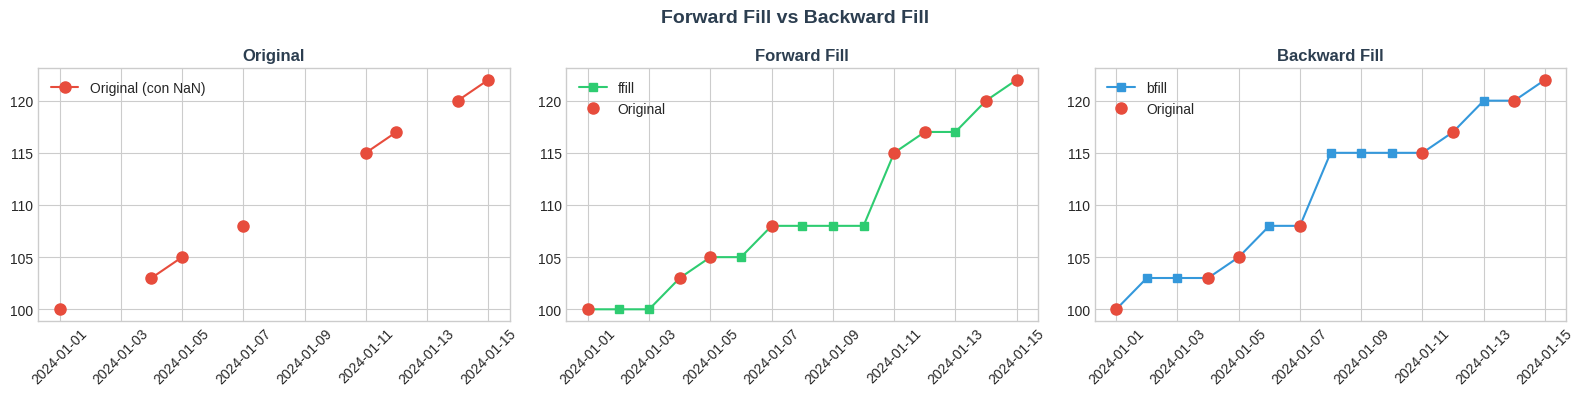

In [8]:
# === FORWARD FILL y BACKWARD FILL ===
print("=" * 60)
print("  FFILL y BFILL (para datos con orden temporal)")
print("=" * 60)

# Crear serie temporal de ejemplo
fechas = pd.date_range('2024-01-01', periods=15, freq='D')
serie = pd.Series([100, np.nan, np.nan, 103, 105, np.nan, 108, np.nan, np.nan, np.nan, 115, 117, np.nan, 120, 122],
                  index=fechas, name='valor')

print("\nSerie original:")
print(serie.to_string())

print(f"\n{'---'*20}")
print("Forward Fill (ffill): propaga ultimo valor valido hacia adelante")
print(serie.ffill().to_string())

print(f"\n{'---'*20}")
print("Backward Fill (bfill): propaga siguiente valor valido hacia atras")
print(serie.bfill().to_string())

print(f"\n{'---'*20}")
print("Forward Fill con limite (limit=1): solo rellena 1 hueco consecutivo")
print(serie.ffill(limit=1).to_string())

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Forward Fill vs Backward Fill', fontsize=14, fontweight='bold', color=C_DARK)

axes[0].plot(serie.index, serie, 'o-', color=C_DANGER, markersize=8, label='Original (con NaN)')
axes[0].set_title('Original', fontweight='bold', color=C_DARK)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(serie.ffill().index, serie.ffill(), 's-', color=C_SUCCESS, markersize=6, label='ffill')
axes[1].plot(serie.index, serie, 'o', color=C_DANGER, markersize=8, label='Original')
axes[1].set_title('Forward Fill', fontweight='bold', color=C_DARK)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(serie.bfill().index, serie.bfill(), 's-', color=C_PRIMARY, markersize=6, label='bfill')
axes[2].plot(serie.index, serie, 'o', color=C_DANGER, markersize=8, label='Original')
axes[2].set_title('Backward Fill', fontweight='bold', color=C_DARK)
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# === ESTRATEGIA 3: KNN IMPUTER ===
print("=" * 60)
print("  ESTRATEGIA 3: KNN IMPUTER (imputacion multivariable)")
print("=" * 60)

df_knn = df_dirty[['edad', 'salario', 'evaluacion']].copy()
print(f"\nANTES:")
print(f"  Nulos - edad: {df_knn['edad'].isnull().sum()}, salario: {df_knn['salario'].isnull().sum()}, evaluacion: {df_knn['evaluacion'].isnull().sum()}")

knn_imp = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    knn_imp.fit_transform(df_knn),
    columns=df_knn.columns
)
print(f"\nDESPUES (KNN k=5):")
print(f"  Nulos - edad: {df_knn_imputed['edad'].isnull().sum()}, salario: {df_knn_imputed['salario'].isnull().sum()}, evaluacion: {df_knn_imputed['evaluacion'].isnull().sum()}")

# === ESTRATEGIA 4: IMPUTACION POR GRUPO ===
print("\n" + "=" * 60)
print("  ESTRATEGIA 4: IMPUTACION POR GRUPO")
print("=" * 60)

df_grupo = df_dirty.copy()
df_grupo['departamento_clean'] = df_grupo['departamento'].str.lower().str.strip()

print(f"\nANTES: nulos en salario = {df_grupo['salario'].isnull().sum()}")

# Imputar salario con la mediana del departamento
df_grupo['salario_grupo'] = df_grupo.groupby('departamento_clean')['salario'].transform(
    lambda x: x.fillna(x.median())
)
# Los que aun tienen NaN (departamento tambien era nulo), imputar con mediana global
df_grupo['salario_grupo'] = df_grupo['salario_grupo'].fillna(df_grupo['salario'].median())

print(f"DESPUES: nulos en salario_grupo = {df_grupo['salario_grupo'].isnull().sum()}")
print(f"\nMediana de salario por departamento:")
display(df_grupo.groupby('departamento_clean')['salario'].median().round(0))

  ESTRATEGIA 3: KNN IMPUTER (imputacion multivariable)

ANTES:
  Nulos - edad: 53, salario: 33, evaluacion: 33

DESPUES (KNN k=5):
  Nulos - edad: 0, salario: 0, evaluacion: 0

  ESTRATEGIA 4: IMPUTACION POR GRUPO

ANTES: nulos en salario = 33
DESPUES: nulos en salario_grupo = 0

Mediana de salario por departamento:


departamento_clean
it           35643.0
marketing    34814.0
rrhh         36029.0
ventas       37210.0
Name: salario, dtype: float64

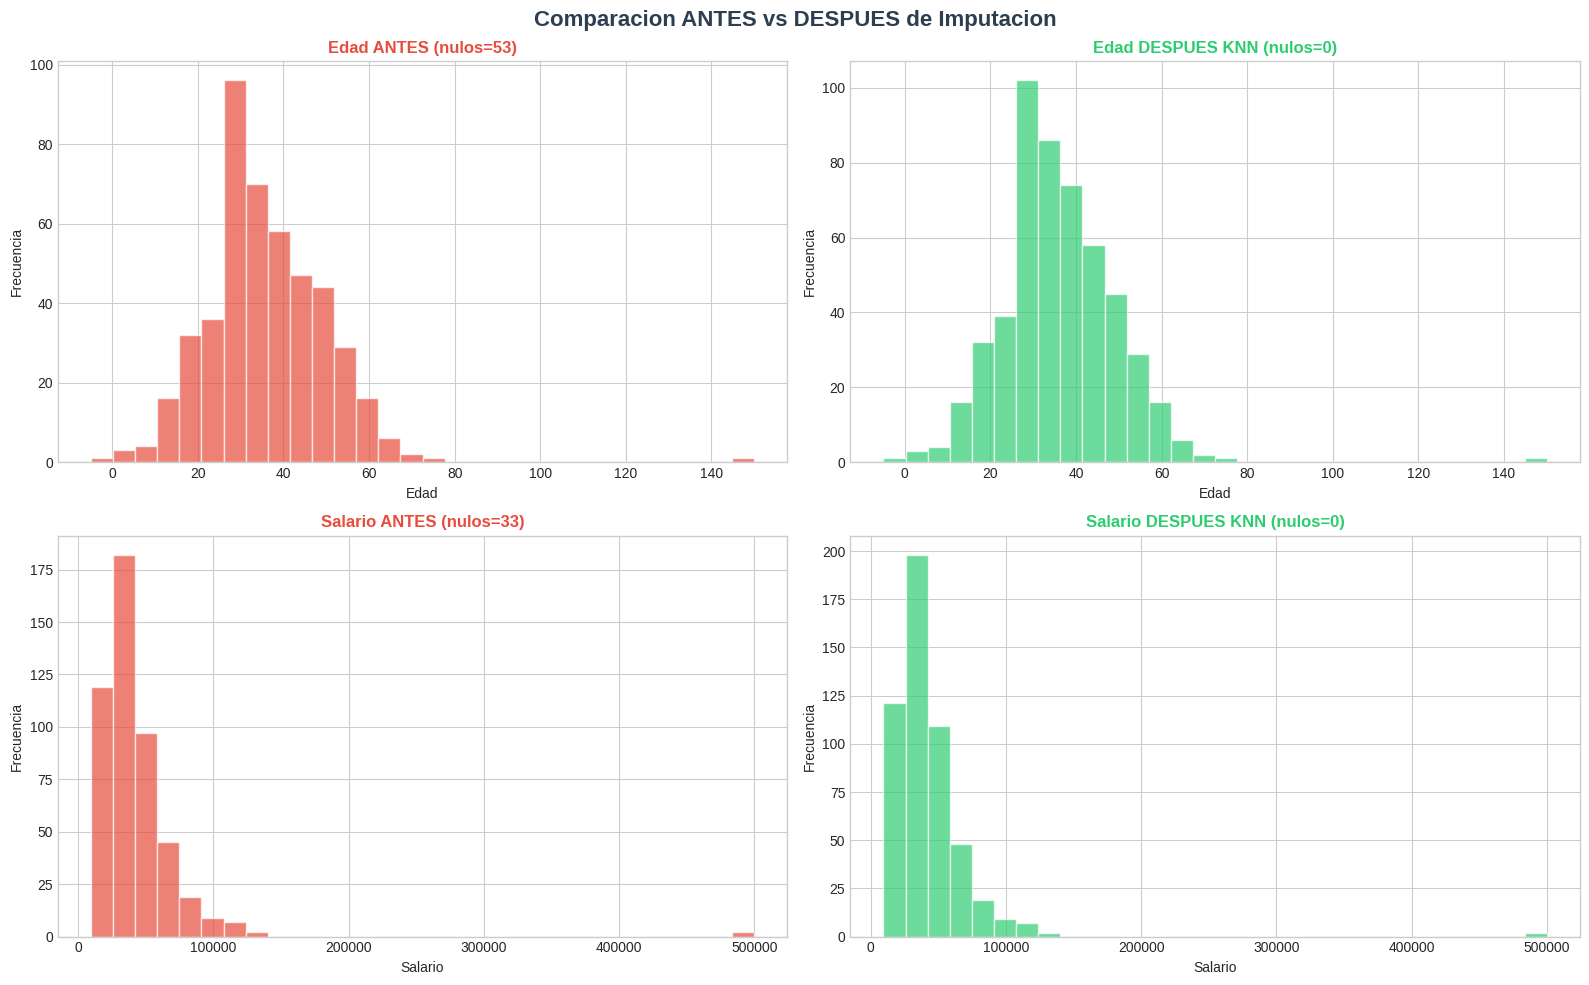

  SKLEARN: SimpleImputer (para uso en pipelines)
SimpleImputer(strategy='mean'):   media usada = 35.77
SimpleImputer(strategy='median'): mediana usada = 34.00
Nulos restantes: mean=0, median=0


In [10]:
# === COMPARACION VISUAL: ANTES vs DESPUES de imputacion ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparacion ANTES vs DESPUES de Imputacion', fontsize=16,
             fontweight='bold', color=C_DARK)

# Edad: ANTES
axes[0, 0].hist(df_dirty['edad'].dropna(), bins=30, color=C_DANGER, alpha=0.7, edgecolor='white')
axes[0, 0].set_title(f'Edad ANTES (nulos={df_dirty["edad"].isnull().sum()})', fontweight='bold', color=C_DANGER)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')

# Edad: DESPUES (KNN)
axes[0, 1].hist(df_knn_imputed['edad'], bins=30, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[0, 1].set_title(f'Edad DESPUES KNN (nulos={df_knn_imputed["edad"].isnull().sum()})', fontweight='bold', color=C_SUCCESS)
axes[0, 1].set_xlabel('Edad')
axes[0, 1].set_ylabel('Frecuencia')

# Salario: ANTES
axes[1, 0].hist(df_dirty['salario'].dropna(), bins=30, color=C_DANGER, alpha=0.7, edgecolor='white')
axes[1, 0].set_title(f'Salario ANTES (nulos={df_dirty["salario"].isnull().sum()})', fontweight='bold', color=C_DANGER)
axes[1, 0].set_xlabel('Salario')
axes[1, 0].set_ylabel('Frecuencia')

# Salario: DESPUES (KNN)
axes[1, 1].hist(df_knn_imputed['salario'], bins=30, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[1, 1].set_title(f'Salario DESPUES KNN (nulos={df_knn_imputed["salario"].isnull().sum()})', fontweight='bold', color=C_SUCCESS)
axes[1, 1].set_xlabel('Salario')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# SimpleImputer de sklearn (para pipelines)
print("=" * 60)
print("  SKLEARN: SimpleImputer (para uso en pipelines)")
print("=" * 60)
imp_mean = SimpleImputer(strategy='mean')
imp_median = SimpleImputer(strategy='median')
imp_most_frequent = SimpleImputer(strategy='most_frequent')

edad_antes = df_dirty[['edad']].copy()
edad_mean = pd.DataFrame(imp_mean.fit_transform(edad_antes), columns=['edad_mean'])
edad_median = pd.DataFrame(imp_median.fit_transform(edad_antes), columns=['edad_median'])

print(f"SimpleImputer(strategy='mean'):   media usada = {imp_mean.statistics_[0]:.2f}")
print(f"SimpleImputer(strategy='median'): mediana usada = {imp_median.statistics_[0]:.2f}")
print(f"Nulos restantes: mean={edad_mean.isnull().sum().values[0]}, median={edad_median.isnull().sum().values[0]}")

### Resumen de imputacion: cual estrategia elegir?

<div style="background: #fef9e7; padding: 15px; border-left: 4px solid #f39c12; border-radius: 5px;">

**Arbol de decision para elegir estrategia de imputacion:**

1. Es el porcentaje de nulos mayor al 60%? -> **Considerar eliminar la columna**
2. Es el porcentaje de nulos menor al 5% y MCAR? -> **dropna()**
3. Es una variable categorica? -> **Moda** o **Frequency-based**
4. Es una variable numerica con outliers? -> **Mediana**
5. Es una variable numerica sin outliers y simetrica? -> **Media**
6. Hay relacion con otras variables? -> **KNN Imputer** o **Imputacion por grupo**
7. Es una serie temporal? -> **ffill/bfill** o **interpolacion**

**Regla de oro:** siempre comparar la distribucion antes y despues de imputar. Si la forma de la distribucion cambia drasticamente, la estrategia de imputacion no es adecuada.
</div>

---
## Seccion 4: Deteccion y Eliminacion de Duplicados

<div style="background: #fef9e7; padding: 20px; border-left: 4px solid #f39c12; border-radius: 5px;">
<strong style="color: #2c3e50;">Los duplicados inflan las metricas y sesgan los modelos.</strong> Pueden ser <em>exactos</em> (todas las columnas iguales) o <em>aproximados</em> (la mayoria de columnas coinciden, con pequennas variaciones por errores de entrada).
</div>

### Tipos de duplicados

| Tipo | Descripcion | Deteccion |
|------|-------------|-----------|
| **Exacto** | Todas las columnas son identicas | `df.duplicated()` |
| **Por subconjunto** | Un subconjunto de columnas clave coincide | `df.duplicated(subset=['col1', 'col2'])` |
| **Aproximado** | Variaciones menores (espacios, mayusculas) | Requiere limpieza previa + comparacion |

  DUPLICADOS: DETECCION Y ELIMINACION

ANTES: 515 filas totales
Duplicados exactos: 15

Primeras filas duplicadas encontradas:


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
0,1,pedro Martinez,31.0,23073.425589,VENTAS,2020-01-18,None,5.0,Sevilla
1,2,Ana Torres,29.0,61594.486576,RRHH,2020-04-21,ALTO,5.3,madrid
2,3,LUIS sanchez,42.0,45608.292605,None,2020-04-01,Bajo,2.9,Valencia
3,4,pedro Martinez,53.0,21144.784963,ventas,2020-10-26,ALTO,2.0,BARCELONA
4,5,pedro martinez,49.0,18697.442936,IT,2020-04-23,None,8.5,Valencia
5,6,LUIS sanchez,43.0,36029.385374,RRHH,2020-11-09,None,5.5,Valencia
6,7,LUIS sanchez,27.0,55550.455489,RRHH,None,medio,1.1,BARCELONA
7,8,pedro Martinez,32.0,56266.686851,Marketing,2020-02-24,ALTO,8.2,BARCELONA
8,9,MARIA LOPEZ,31.0,43394.302758,ventas,2020-04-05,Bajo,9.8,Madrid
9,10,pedro martinez,29.0,37210.171085,ventas,2020-08-19,Bajo,6.5,Valencia



DESPUES (drop_duplicates keep='first'): 500 filas
Filas eliminadas: 15

------------------------------------------------------------
  DUPLICADOS POR SUBCONJUNTO (nombre + departamento)
------------------------------------------------------------
Duplicados por nombre+departamento: 459
Despues de eliminar: 56 filas (de 515)

------------------------------------------------------------
  DUPLICADOS APROXIMADOS (detectar variaciones en strings)
------------------------------------------------------------
Valores unicos de 'nombre' SIN normalizar: 6
Valores unicos de 'nombre' CON normalizar: 5

Valores originales vs normalizados:


,nombre,nombre_norm
0,pedro Martinez,pedro martinez
1,Ana Torres,ana torres
2,LUIS sanchez,luis sanchez
4,pedro martinez,pedro martinez
8,MARIA LOPEZ,maria lopez
25,Juan Garcia,juan garcia


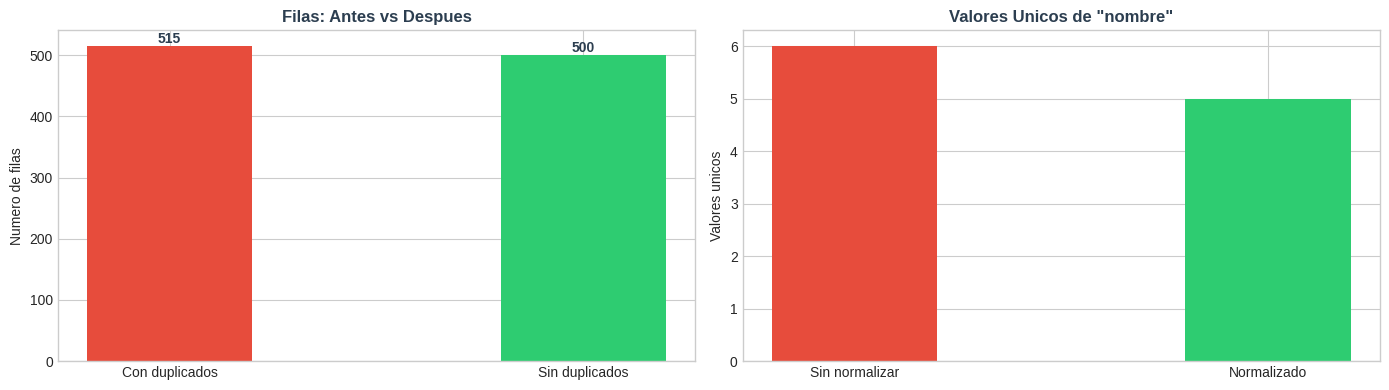

In [11]:
# === DETECCION Y ELIMINACION DE DUPLICADOS ===
print("=" * 60)
print("  DUPLICADOS: DETECCION Y ELIMINACION")
print("=" * 60)

df_dup = df_dirty.copy()

# --- ANTES ---
n_dup_exactos = df_dup.duplicated().sum()
print(f"\nANTES: {df_dup.shape[0]} filas totales")
print(f"Duplicados exactos: {n_dup_exactos}")

# Mostrar las filas duplicadas
print("\nPrimeras filas duplicadas encontradas:")
display(df_dup[df_dup.duplicated(keep=False)].head(10))

# --- Eliminar duplicados exactos ---
df_sin_dup = df_dup.drop_duplicates(keep='first')
print(f"\nDESPUES (drop_duplicates keep='first'): {df_sin_dup.shape[0]} filas")
print(f"Filas eliminadas: {df_dup.shape[0] - df_sin_dup.shape[0]}")

# --- Duplicados por subconjunto ---
print("\n" + "-" * 60)
print("  DUPLICADOS POR SUBCONJUNTO (nombre + departamento)")
print("-" * 60)
n_dup_sub = df_dup.duplicated(subset=['nombre', 'departamento']).sum()
print(f"Duplicados por nombre+departamento: {n_dup_sub}")

df_sin_dup_sub = df_dup.drop_duplicates(subset=['nombre', 'departamento'], keep='first')
print(f"Despues de eliminar: {df_sin_dup_sub.shape[0]} filas (de {df_dup.shape[0]})")

# --- Duplicados aproximados: limpiar primero, luego detectar ---
print("\n" + "-" * 60)
print("  DUPLICADOS APROXIMADOS (detectar variaciones en strings)")
print("-" * 60)
df_aprox = df_dup.copy()
df_aprox['nombre_norm'] = df_aprox['nombre'].str.lower().str.strip()
print(f"Valores unicos de 'nombre' SIN normalizar: {df_dup['nombre'].nunique()}")
print(f"Valores unicos de 'nombre' CON normalizar: {df_aprox['nombre_norm'].nunique()}")
print(f"\nValores originales vs normalizados:")
comparacion = df_aprox[['nombre', 'nombre_norm']].drop_duplicates().dropna()
display(comparacion.head(10))

# Visualizacion ANTES vs DESPUES
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(['Con duplicados'], [df_dup.shape[0]], color=C_DANGER, width=0.4)
axes[0].bar(['Sin duplicados'], [df_sin_dup.shape[0]], color=C_SUCCESS, width=0.4)
axes[0].set_title('Filas: Antes vs Despues', fontweight='bold', color=C_DARK)
axes[0].set_ylabel('Numero de filas')
for i, v in enumerate([df_dup.shape[0], df_sin_dup.shape[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', color=C_DARK)

# Valores unicos de nombre
axes[1].bar(['Sin normalizar', 'Normalizado'], 
            [df_dup['nombre'].nunique(), df_aprox['nombre_norm'].nunique()],
            color=[C_DANGER, C_SUCCESS], width=0.4)
axes[1].set_title('Valores Unicos de "nombre"', fontweight='bold', color=C_DARK)
axes[1].set_ylabel('Valores unicos')

plt.tight_layout()
plt.show()

### Buenas practicas con duplicados

<div style="background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">

- **Antes de eliminar duplicados**, normalizar strings (lower, strip) para detectar duplicados que difieren solo en formato
- **Usar `keep='first'`** para mantener la primera ocurrencia, o **`keep='last'`** para la ultima, o **`keep=False`** para eliminar todas
- **Duplicados por ID natural:** si hay una columna que deberia ser unica (como email, DNI), buscar duplicados en ella con `duplicated(subset=['id_natural'])`
- **Registrar cuantos duplicados se eliminan** para trazabilidad del proceso de limpieza
- En bases de datos transaccionales, un "duplicado" puede ser una transaccion legitima (compra repetida). Siempre validar con el contexto de negocio.
</div>

---
## Seccion 5: Deteccion y Tratamiento de Outliers

<div style="background: #fdedec; padding: 20px; border-left: 4px solid #e74c3c; border-radius: 5px;">
<strong style="color: #2c3e50;">Un outlier es una observacion que se desvía significativamente del resto.</strong> Pueden ser errores de medicion (deben eliminarse) o valores reales pero extremos (pueden winsorizarse o mantenerse segun el contexto).
</div>

### Metodos de Deteccion

**1. Metodo IQR (Rango Intercuartilico)**

La formula es:

- **Q1** = primer cuartil (percentil 25), es decir, el valor por debajo del cual cae el 25% de los datos
- **Q3** = tercer cuartil (percentil 75), es decir, el valor por debajo del cual cae el 75% de los datos
- **IQR** = Q3 - Q1, donde IQR es la diferencia entre el tercer y primer cuartil, representando la dispersion del 50% central de los datos
- **Limite inferior** = Q1 - 1.5 * IQR, donde 1.5 es un factor convencional que captura ~99.3% de datos normales
- **Limite superior** = Q3 + 1.5 * IQR
- Todo valor **x** tal que x < Limite inferior o x > Limite superior se considera outlier

**2. Metodo Z-Score**

La formula es: z = (x - mu) / sigma

- **x** = el valor individual que estamos evaluando
- **mu** (media) = la media aritmetica de toda la variable
- **sigma** (desviacion estandar) = la desviacion estandar de toda la variable
- **z** = cuantas desviaciones estandar se aleja x de la media
- Un valor con |z| > 3 (valor absoluto de z mayor a 3) se considera outlier

**3. Metodo MAD (Median Absolute Deviation)**

La formula es: MAD = mediana(|x_i - mediana(x)|)

- **x_i** = cada valor individual de la variable
- **mediana(x)** = la mediana de todos los valores de la variable
- **|x_i - mediana(x)|** = la desviacion absoluta de cada valor respecto a la mediana
- **MAD** = la mediana de todas esas desviaciones absolutas
- Es mas robusto que el Z-score porque usa medianas en lugar de medias (no se ve afectado por outliers extremos)
- Un valor se considera outlier si |x_i - mediana(x)| / MAD > 3.5

  METODO 1: IQR (Rango Intercuartilico)

Columna: salario
Q1 = 25,819
Q3 = 50,503
IQR = Q3 - Q1 = 24,684
Limite inferior = Q1 - 1.5*IQR = -11,206
Limite superior = Q3 + 1.5*IQR = 87,528
Outliers detectados: 20 de 482 (4.1%)

  METODO 2: Z-Score

Outliers con |z| > 3: 2
Valores: [500000. 500000.]

  METODO 3: MAD (Median Absolute Deviation)

Mediana = 36,819
MAD = 12,146
Outliers con MAD score > 3.5: 34


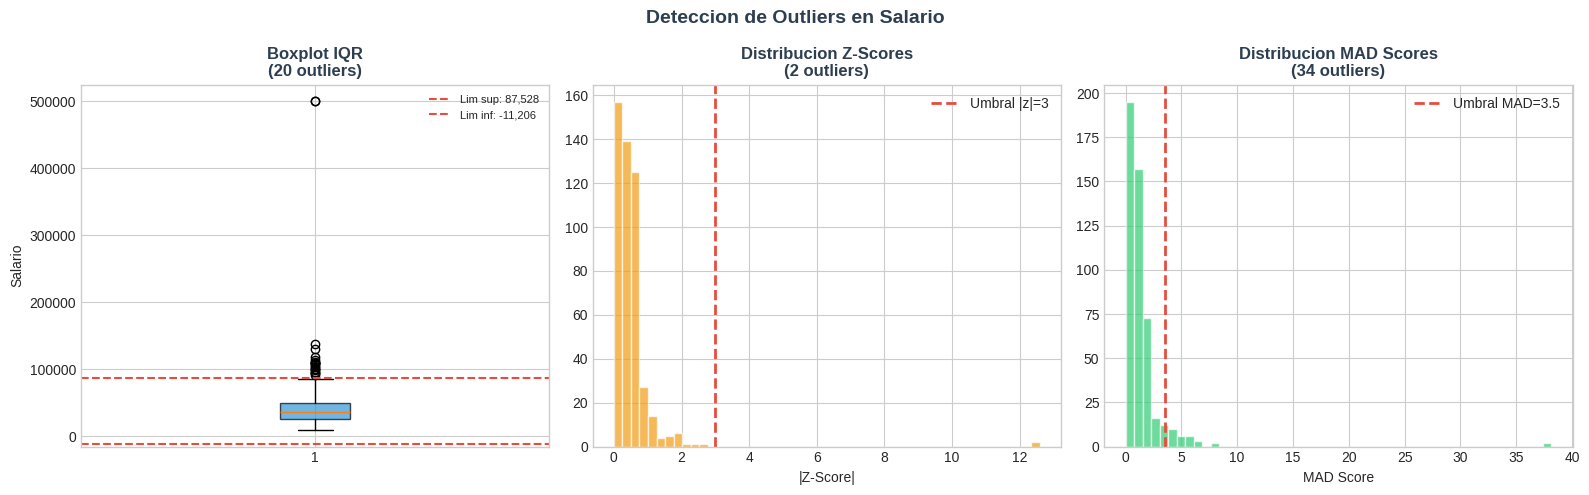

In [12]:
# === DETECCION DE OUTLIERS: IQR ===
print("=" * 60)
print("  METODO 1: IQR (Rango Intercuartilico)")
print("=" * 60)

df_out = df_dirty.copy()
col = 'salario'
datos = df_out[col].dropna()

Q1 = datos.quantile(0.25)
Q3 = datos.quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = datos[(datos < lim_inf) | (datos > lim_sup)]
print(f"\nColumna: {col}")
print(f"Q1 = {Q1:,.0f}")
print(f"Q3 = {Q3:,.0f}")
print(f"IQR = Q3 - Q1 = {IQR:,.0f}")
print(f"Limite inferior = Q1 - 1.5*IQR = {lim_inf:,.0f}")
print(f"Limite superior = Q3 + 1.5*IQR = {lim_sup:,.0f}")
print(f"Outliers detectados: {len(outliers_iqr)} de {len(datos)} ({len(outliers_iqr)/len(datos)*100:.1f}%)")

# === DETECCION DE OUTLIERS: Z-SCORE ===
print("\n" + "=" * 60)
print("  METODO 2: Z-Score")
print("=" * 60)

z_scores = np.abs(stats.zscore(datos))
outliers_z = datos[z_scores > 3]
print(f"\nOutliers con |z| > 3: {len(outliers_z)}")
print(f"Valores: {outliers_z.values[:10]}")

# === DETECCION DE OUTLIERS: MAD ===
print("\n" + "=" * 60)
print("  METODO 3: MAD (Median Absolute Deviation)")
print("=" * 60)

mediana = datos.median()
mad = np.median(np.abs(datos - mediana))
mad_scores = np.abs(datos - mediana) / mad
outliers_mad = datos[mad_scores > 3.5]
print(f"\nMediana = {mediana:,.0f}")
print(f"MAD = {mad:,.0f}")
print(f"Outliers con MAD score > 3.5: {len(outliers_mad)}")

# Boxplot ANTES
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Deteccion de Outliers en Salario', fontsize=14, fontweight='bold', color=C_DARK)

bp1 = axes[0].boxplot(datos, patch_artist=True, boxprops=dict(facecolor=C_PRIMARY, alpha=0.7))
axes[0].set_title(f'Boxplot IQR\n({len(outliers_iqr)} outliers)', fontweight='bold', color=C_DARK)
axes[0].set_ylabel('Salario')
axes[0].axhline(y=lim_sup, color=C_DANGER, linestyle='--', label=f'Lim sup: {lim_sup:,.0f}')
axes[0].axhline(y=lim_inf, color=C_DANGER, linestyle='--', label=f'Lim inf: {lim_inf:,.0f}')
axes[0].legend(fontsize=8)

axes[1].hist(z_scores, bins=50, color=C_ORANGE, alpha=0.7, edgecolor='white')
axes[1].axvline(x=3, color=C_DANGER, linestyle='--', linewidth=2, label='Umbral |z|=3')
axes[1].set_title(f'Distribucion Z-Scores\n({len(outliers_z)} outliers)', fontweight='bold', color=C_DARK)
axes[1].set_xlabel('|Z-Score|')
axes[1].legend()

axes[2].hist(mad_scores, bins=50, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[2].axvline(x=3.5, color=C_DANGER, linestyle='--', linewidth=2, label='Umbral MAD=3.5')
axes[2].set_title(f'Distribucion MAD Scores\n({len(outliers_mad)} outliers)', fontweight='bold', color=C_DARK)
axes[2].set_xlabel('MAD Score')
axes[2].legend()

plt.tight_layout()
plt.show()

### Comparacion de metodos de deteccion de outliers

<div style="background: #fdedec; padding: 15px; border-left: 4px solid #e74c3c; border-radius: 5px;">

| Caracteristica | IQR | Z-Score | MAD | Isolation Forest |
|---------------|-----|---------|-----|-----------------|
| **Supone normalidad** | No | Si | No | No |
| **Robusto a outliers extremos** | Si | No (la media se distorsiona) | Si | Si |
| **Univariado/Multivariado** | Univariado | Univariado | Univariado | Multivariado |
| **Parametro clave** | Factor 1.5 | Umbral z=3 | Umbral 3.5 | contamination |
| **Mejor para** | Datos no-normales | Datos gaussianos | Datos con muchos outliers | Relaciones complejas |

**Recomendacion:** usar IQR o MAD como primera aproximacion. Si hay relaciones entre variables, complementar con Isolation Forest. El Z-score solo es confiable con datos que siguen una distribucion normal.
</div>

### Tratamiento de Outliers: Winsorizar vs Eliminar vs Transformar

#### Que es Winsorizar?

**Winsorizar** (en honor a Charles Winsor) consiste en **reemplazar** los valores extremos por el valor del percentil elegido, en vez de eliminarlos.

**Formula:**

$$x_i^{winsor} = \begin{cases} q_{\alpha} & \text{si } x_i < q_{\alpha} \\ x_i & \text{si } q_{\alpha} \leq x_i \leq q_{1-\alpha} \\ q_{1-\alpha} & \text{si } x_i > q_{1-\alpha} \end{cases}$$

Donde:
- $x_i$: valor original de la observacion $i$
- $\alpha$: nivel de recorte (ej: 0.05 para winsorizar al 5%)
- $q_{\alpha}$: percentil inferior (ej: percentil 5)
- $q_{1-\alpha}$: percentil superior (ej: percentil 95)
- $x_i^{winsor}$: valor winsorizado

**Ejemplo con $\alpha = 0.05$:**
- Datos: [2, 5, 8, 10, 12, 15, 18, 200]
- $q_{0.05}$ = 2.75, $q_{0.95}$ = 72.5
- El valor 200 se reemplaza por 72.5
- El valor 2 queda igual (esta por encima de $q_{0.05}$)

#### Diferencia entre metodos

| Metodo | Que hace | Ventaja | Desventaja |
|--------|----------|---------|------------|
| **Winsorizar** | Reemplaza extremos por percentil | Conserva n muestras | Puede distorsionar la distribucion |
| **Trimming** | ELIMINA los extremos | Elimina influencia totalmente | Pierdes datos (n se reduce) |
| **Transformar (log)** | Comprime la escala | Mantiene orden y diferencias relativas | Cambia la interpretacion |
| **Dejar** | No hacer nada | Sin manipulacion | Modelos sensibles se distorsionan |

#### Cuando usar cada uno

| Situacion | Metodo recomendado | Ejemplo |
|-----------|-------------------|---------|
| Outlier es un valor REAL pero extremo | **Winsorizar** | Salario de CEO entre empleados |
| Outlier es un ERROR de medicion | **Eliminar** (trimming) | Edad = -5 o 999 |
| Distribucion muy sesgada (positiva) | **Transformar** (log, sqrt) | Precios, ingresos, poblacion |
| Usas modelos robustos (arboles) | **Dejar** | Random Forest, XGBoost |
| Los outliers son la SEÑAL | **Dejar** | Deteccion de fraude, anomalias |
| Dataset muy pequeño (<100) | **Winsorizar** (no puedes perder datos) | Estudios clinicos |

#### Niveles comunes de winsorización

| Nivel $\alpha$ | Percentiles | Agresividad | Uso tipico |
|----------------|-------------|-------------|------------|
| 1% | P1 - P99 | Suave | Solo extremos muy raros |
| 5% | P5 - P95 | Moderado | El mas comun |
| 10% | P10 - P90 | Agresivo | Datos muy ruidosos |

#### En Python

Dos formas de hacerlo:
```python
# Forma 1: Manual con clip()
q05 = df['salario'].quantile(0.05)
q95 = df['salario'].quantile(0.95)
df['salario_winsor'] = df['salario'].clip(lower=q05, upper=q95)

# Forma 2: scipy.stats.mstats.winsorize
from scipy.stats.mstats import winsorize
df['salario_winsor'] = winsorize(df['salario'], limits=[0.05, 0.05])
```

In [ ]:
# === WINSORIZAR: comparacion detallada ===
from scipy.stats.mstats import winsorize as scipy_winsorize

# Datos con outliers claros
np.random.seed(42)
datos_orig = np.concatenate([
    np.random.normal(50000, 10000, 200),  # Salarios normales
    np.array([200000, 250000, 300000, 500000, 5000]),  # Outliers altos y bajo
])
np.random.shuffle(datos_orig)

# Aplicar 4 metodos
q01, q99 = np.percentile(datos_orig, [1, 99])
q05, q95 = np.percentile(datos_orig, [5, 95])
q10, q90 = np.percentile(datos_orig, [10, 90])

datos_winsor_1 = np.clip(datos_orig, q01, q99)     # Winsorizar al 1%
datos_winsor_5 = np.clip(datos_orig, q05, q95)     # Winsorizar al 5%
datos_winsor_10 = np.clip(datos_orig, q10, q90)    # Winsorizar al 10%

# Trimming al 5% (eliminar, no reemplazar)
mask_trim = (datos_orig >= q05) & (datos_orig <= q95)
datos_trim = datos_orig[mask_trim]

# Log transform
datos_log = np.log1p(datos_orig)

# --- Visualizacion 1: Histogramas ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    (axes[0,0], datos_orig, 'Original\n(con outliers)', C_DANGER),
    (axes[0,1], datos_winsor_1, 'Winsorizar 1%-99%\n(suave)', C_ORANGE),
    (axes[0,2], datos_winsor_5, 'Winsorizar 5%-95%\n(moderado)', C_PRIMARY),
    (axes[1,0], datos_winsor_10, 'Winsorizar 10%-90%\n(agresivo)', C_PURPLE),
    (axes[1,1], datos_trim, f'Trimming 5%-95%\n(n={len(datos_orig)}→{len(datos_trim)})', C_SUCCESS),
    (axes[1,2], datos_log, 'Log transform\n(comprime escala)', C_DARK),
]

for ax, data, title, color in configs:
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linewidth=2, linestyle='--', label=f'Media={np.mean(data):,.0f}')
    ax.axvline(np.median(data), color='gray', linewidth=2, linestyle=':', label=f'Mediana={np.median(data):,.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold', color=C_DARK)
    ax.legend(fontsize=8)

plt.suptitle('Comparacion de metodos para tratar outliers', fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

# --- Tabla comparativa ---
print("\nCOMPARACION DE METODOS")
print("=" * 80)
print(f"{'Metodo':<25} {'n':>5} {'Media':>12} {'Mediana':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print("-" * 80)
for name, data in [('Original', datos_orig), ('Winsor 1%', datos_winsor_1), 
                    ('Winsor 5%', datos_winsor_5), ('Winsor 10%', datos_winsor_10),
                    ('Trimming 5%', datos_trim)]:
    print(f"{name:<25} {len(data):>5} {np.mean(data):>12,.0f} {np.median(data):>12,.0f} "
          f"{np.std(data):>12,.0f} {np.min(data):>12,.0f} {np.max(data):>12,.0f}")

# --- Visualizacion 2: Boxplots antes/despues ---
fig, ax = plt.subplots(figsize=(14, 5))
bp_data = [datos_orig, datos_winsor_1, datos_winsor_5, datos_winsor_10, datos_trim]
bp = ax.boxplot(bp_data, labels=['Original', 'Winsor 1%', 'Winsor 5%', 'Winsor 10%', 'Trim 5%'],
                patch_artist=True)
colors_bp = [C_DANGER, C_ORANGE, C_PRIMARY, C_PURPLE, C_SUCCESS]
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_title('Boxplots: efecto de cada metodo sobre la distribucion', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_ylabel('Salario')
plt.tight_layout()
plt.show()

print("\nConclusion:")
print("  - Winsorizar al 5% es el nivel mas usado (equilibrio entre conservar datos y reducir influencia)")
print("  - Trimming pierde datos (n baja) — usar solo si tienes muchas muestras")
print("  - Log transform es ideal para distribuciones muy sesgadas (positivas)")
print("  - Si usas arboles (RF, XGBoost): NO necesitas tratar outliers")

  OUTLIERS EN EDAD: Comparacion de 3 metodos

Edad - Estadisticas basicas:
  Media: 35.8, Mediana: 34.0
  Min: -5, Max: 150

Outliers detectados:
  IQR:     6 outliers
  Z-Score: 1 outliers
  MAD:     14 outliers

Valores extremos detectados por IQR: [-5.0, 1.0, 72.0, 73.0, 150.0]
Valores extremos detectados por Z-Score: [150.0]


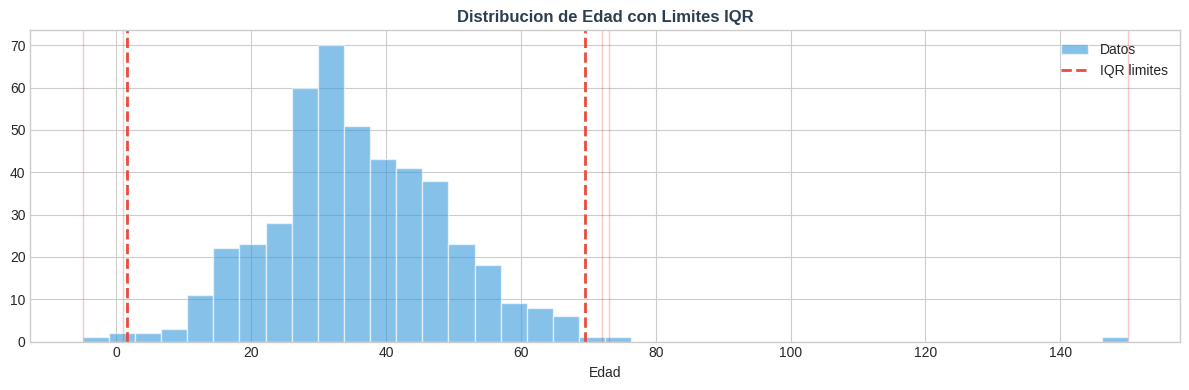

In [14]:
# === OUTLIERS EN EDAD: Aplicar multiples metodos ===
print("=" * 60)
print("  OUTLIERS EN EDAD: Comparacion de 3 metodos")
print("=" * 60)

datos_edad = df_dirty['edad'].dropna()

# IQR
Q1_e = datos_edad.quantile(0.25)
Q3_e = datos_edad.quantile(0.75)
IQR_e = Q3_e - Q1_e
out_iqr_e = datos_edad[(datos_edad < Q1_e - 1.5*IQR_e) | (datos_edad > Q3_e + 1.5*IQR_e)]

# Z-Score
z_e = np.abs(stats.zscore(datos_edad))
out_z_e = datos_edad[z_e > 3]

# MAD
med_e = datos_edad.median()
mad_e = np.median(np.abs(datos_edad - med_e))
mad_scores_e = np.abs(datos_edad - med_e) / mad_e if mad_e != 0 else np.zeros(len(datos_edad))
out_mad_e = datos_edad[mad_scores_e > 3.5]

print(f"\nEdad - Estadisticas basicas:")
print(f"  Media: {datos_edad.mean():.1f}, Mediana: {datos_edad.median():.1f}")
print(f"  Min: {datos_edad.min():.0f}, Max: {datos_edad.max():.0f}")
print(f"\nOutliers detectados:")
print(f"  IQR:     {len(out_iqr_e)} outliers")
print(f"  Z-Score: {len(out_z_e)} outliers")
print(f"  MAD:     {len(out_mad_e)} outliers")

# Los valores detectados
print(f"\nValores extremos detectados por IQR: {sorted(out_iqr_e.unique())}")
print(f"Valores extremos detectados por Z-Score: {sorted(out_z_e.unique())}")

# Visualizacion
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(datos_edad, bins=40, color=C_PRIMARY, alpha=0.6, edgecolor='white', label='Datos')
for val in out_iqr_e.unique():
    ax.axvline(val, color=C_DANGER, alpha=0.3, linewidth=1)
ax.axvline(Q1_e - 1.5*IQR_e, color=C_DANGER, linestyle='--', linewidth=2, label=f'IQR limites')
ax.axvline(Q3_e + 1.5*IQR_e, color=C_DANGER, linestyle='--', linewidth=2)
ax.set_title('Distribucion de Edad con Limites IQR', fontweight='bold', color=C_DARK)
ax.set_xlabel('Edad')
ax.legend()
plt.tight_layout()
plt.show()

---
## Seccion 6: Correccion de Tipos y Validacion

<div style="background: #eaf2f8; padding: 20px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">Los tipos de datos incorrectos impiden operaciones matematicas y comparaciones.</strong> Es comun encontrar numeros almacenados como strings, fechas en formatos inconsistentes, y valores fuera de rangos logicos.
</div>

### Problemas comunes de tipos

| Problema | Ejemplo | Solucion |
|----------|---------|----------|
| Numero como string | `"42"` en vez de `42` | `pd.to_numeric()` |
| Fecha como string | `"2020-01-15"` como object | `pd.to_datetime()` |
| Formatos mixtos de fecha | `"2020-01-15"` y `"15/01/2020"` | `pd.to_datetime(format='mixed')` |
| Valores fuera de rango | edad = -5, edad = 150 | Validacion con condiciones logicas |
| Strings inconsistentes | `"Madrid"`, `"madrid"`, `"MADRID"` | `.str.lower().str.strip()` |
| Caracteres especiales | Espacios extra, tabulaciones | `.str.strip()`, regex |

### Expresiones regulares (regex) mas comunes para limpieza

<div style="background: #fef9e7; padding: 15px; border-left: 4px solid #f39c12; border-radius: 5px;">

| Patron | Significado | Ejemplo de uso |
|--------|------------|----------------|
| `^` | Inicio de string | `^[A-Z]` = empieza con mayuscula |
| `$` | Fin de string | `\d$` = termina con digito |
| `\d` | Cualquier digito (0-9) | `\d{3}` = exactamente 3 digitos |
| `\w` | Letra, digito o guion bajo | `\w+` = una o mas "word characters" |
| `\s` | Espacio, tab, newline | `\s+` = uno o mas espacios |
| `[A-Za-z]` | Cualquier letra | `[A-Za-z]+` = una o mas letras |
| `.` | Cualquier caracter (excepto newline) | `a.b` = "a", cualquier caracter, "b" |
| `+` | Una o mas repeticiones | `\d+` = uno o mas digitos |
| `*` | Cero o mas repeticiones | `\s*` = cero o mas espacios |
| `?` | Cero o una repeticion | `colou?r` = "color" o "colour" |
| `{n}` | Exactamente n repeticiones | `\d{4}` = exactamente 4 digitos |
| `()` | Grupo de captura | `(\d{2})/(\d{2})` = captura dia/mes |
| `\|` | OR logico | `cat\|dog` = "cat" o "dog" |

**Uso en Pandas:** `df['col'].str.match(patron)`, `df['col'].str.replace(patron, reemplazo, regex=True)`, `df['col'].str.extract(patron)`
</div>

In [15]:
# === REGEX EN ACCION: Extraer y validar con expresiones regulares ===
print("=" * 60)
print("  REGEX EN ACCION")
print("=" * 60)

# Crear datos de ejemplo con formatos variados
datos_regex = pd.DataFrame({
    'telefono': ['+34 612 345 678', '612345678', '(612) 345-678', 'abc123', None, '912 123 456'],
    'email': ['juan@gmail.com', 'maria@empresa.es', 'invalido', 'pedro@', None, 'ana.torres@mail.com'],
    'codigo_postal': ['28001', '08080', '1234', 'ABCDE', None, '41001'],
})

print("\nDatos originales:")
display(datos_regex)

# Extraer solo digitos del telefono
print("\n--- Extraer digitos del telefono ---")
datos_regex['telefono_limpio'] = datos_regex['telefono'].str.replace(r'[^\d]', '', regex=True)
print("Patron: [^\\d] = todo lo que NO es digito -> reemplazar con ''")
display(datos_regex[['telefono', 'telefono_limpio']])

# Validar formato de email
print("\n--- Validar emails con regex ---")
patron_email = r'^[\w\.\-]+@[\w\.\-]+\.\w{2,}$'
datos_regex['email_valido'] = datos_regex['email'].str.match(patron_email, na=False)
print(f"Patron: {patron_email}")
print("  ^[\\w\\.\\-]+  = inicio: una o mas letras/digitos/punto/guion")
print("  @            = arroba literal")
print("  [\\w\\.\\-]+  = dominio: una o mas letras/digitos/punto/guion")
print("  \\.\\w{{2,}}$ = punto + al menos 2 letras al final (.com, .es)")
display(datos_regex[['email', 'email_valido']])

# Validar codigo postal (5 digitos)
print("\n--- Validar codigo postal (exactamente 5 digitos) ---")
patron_cp = r'^\d{5}$'
datos_regex['cp_valido'] = datos_regex['codigo_postal'].str.match(patron_cp, na=False)
print(f"Patron: {patron_cp}")
print("  ^\\d{{5}}$ = exactamente 5 digitos, nada mas")
display(datos_regex[['codigo_postal', 'cp_valido']])

  REGEX EN ACCION

Datos originales:


,telefono,email,codigo_postal
0,+34 612 345 678,juan@gmail.com,28001
1,612345678,maria@empresa.es,08080
2,(612) 345-678,invalido,1234
3,abc123,pedro@,ABCDE
4,None,None,None
5,912 123 456,ana.torres@mail.com,41001



--- Extraer digitos del telefono ---
Patron: [^\d] = todo lo que NO es digito -> reemplazar con ''


,telefono,telefono_limpio
0,+34 612 345 678,34612345678
1,612345678,612345678
2,(612) 345-678,612345678
3,abc123,123
4,None,None
5,912 123 456,912123456



--- Validar emails con regex ---
Patron: ^[\w\.\-]+@[\w\.\-]+\.\w{2,}$
  ^[\w\.\-]+  = inicio: una o mas letras/digitos/punto/guion
  @            = arroba literal
  [\w\.\-]+  = dominio: una o mas letras/digitos/punto/guion
  \.\w{{2,}}$ = punto + al menos 2 letras al final (.com, .es)


,email,email_valido
0,juan@gmail.com,True
1,maria@empresa.es,True
2,invalido,False
3,pedro@,False
4,None,False
5,ana.torres@mail.com,True



--- Validar codigo postal (exactamente 5 digitos) ---
Patron: ^\d{5}$
  ^\d{{5}}$ = exactamente 5 digitos, nada mas


,codigo_postal,cp_valido
0,28001,True
1,08080,True
2,1234,False
3,ABCDE,False
4,None,False
5,41001,True


In [16]:
# === CORRECCION DE TIPOS Y VALIDACION ===
import re

df_tipos = df_dirty.copy()
print("=" * 60)
print("  CORRECCION DE TIPOS DE DATOS")
print("=" * 60)

# --- 1. Strings a numeros ---
print("\n--- 1. Strings a numeros (pd.to_numeric) ---")
# Simular una columna que tiene numeros como strings
df_tipos['salario_str'] = df_tipos['salario'].astype(str)
print(f"ANTES: tipo de 'salario_str' = {df_tipos['salario_str'].dtype}")
df_tipos['salario_num'] = pd.to_numeric(df_tipos['salario_str'], errors='coerce')
print(f"DESPUES: tipo de 'salario_num' = {df_tipos['salario_num'].dtype}")

# --- 2. Parsear fechas con formatos mixtos ---
print("\n--- 2. Parseo de fechas con formatos mixtos ---")
print(f"ANTES: tipo de 'fecha_ingreso' = {df_tipos['fecha_ingreso'].dtype}")
print(f"Ejemplos de formatos encontrados:")
display(df_tipos['fecha_ingreso'].dropna().unique()[:8])

df_tipos['fecha_parsed'] = pd.to_datetime(df_tipos['fecha_ingreso'], format='mixed', dayfirst=True, errors='coerce')
print(f"\nDESPUES: tipo de 'fecha_parsed' = {df_tipos['fecha_parsed'].dtype}")
print(f"Fechas no parseadas (NaT): {df_tipos['fecha_parsed'].isnull().sum()}")
print(f"Rango: {df_tipos['fecha_parsed'].min()} a {df_tipos['fecha_parsed'].max()}")

# --- 3. Normalizar strings ---
print("\n--- 3. Normalizar strings (lower + strip) ---")
print("ANTES - valores unicos de 'departamento':")
print(f"  {df_tipos['departamento'].unique()}")

df_tipos['depto_clean'] = df_tipos['departamento'].str.lower().str.strip()
print(f"\nDESPUES - valores unicos de 'depto_clean':")
print(f"  {df_tipos['depto_clean'].unique()}")

df_tipos['nombre_clean'] = df_tipos['nombre'].str.strip().str.title()
print(f"\nANTES 'nombre' unicos: {df_tipos['nombre'].nunique()}")
print(f"DESPUES 'nombre_clean' unicos: {df_tipos['nombre_clean'].nunique()}")
display(df_tipos[['nombre', 'nombre_clean']].drop_duplicates().dropna().head(8))

# --- 4. Validar rangos ---
print("\n--- 4. Validacion de rangos logicos ---")
invalidos_edad = df_tipos[(df_tipos['edad'] < 0) | (df_tipos['edad'] > 120)]
print(f"Edades invalidas (< 0 o > 120): {len(invalidos_edad)}")
display(invalidos_edad[['id', 'nombre', 'edad']].head())

# Corregir: reemplazar invalidos con NaN
df_tipos.loc[(df_tipos['edad'] < 0) | (df_tipos['edad'] > 120), 'edad'] = np.nan
print(f"\nDESPUES de invalidar: nulos en edad = {df_tipos['edad'].isnull().sum()}")

# --- 5. Regex para validar formato ---
print("\n--- 5. Validacion con regex ---")
# Validar que nombre tenga al menos nombre y apellido (dos palabras)
patron_nombre = r'^[A-Za-z]+\s+[A-Za-z]+$'
df_tipos['nombre_valido'] = df_tipos['nombre_clean'].str.match(patron_nombre, na=False)
n_validos = df_tipos['nombre_valido'].sum()
n_total = df_tipos['nombre_clean'].notna().sum()
print(f"Nombres que cumplen patron 'Nombre Apellido': {n_validos} de {n_total}")
print(f"Patron regex usado: {patron_nombre}")
print(f"  ^ = inicio de string")
print(f"  [A-Za-z]+ = una o mas letras")
print(f"  \\s+ = uno o mas espacios")
print(f"  $ = fin de string")

  CORRECCION DE TIPOS DE DATOS

--- 1. Strings a numeros (pd.to_numeric) ---
ANTES: tipo de 'salario_str' = object
DESPUES: tipo de 'salario_num' = float64

--- 2. Parseo de fechas con formatos mixtos ---
ANTES: tipo de 'fecha_ingreso' = object
Ejemplos de formatos encontrados:


array(['2020-01-18', '2020-04-21', '2020-04-01', '2020-10-26',
       '2020-04-23', '2020-11-09', '2020-02-24', '2020-04-05'],
      dtype=object)


DESPUES: tipo de 'fecha_parsed' = datetime64[ns]
Fechas no parseadas (NaT): 28
Rango: 2020-01-01 00:00:00 a 2020-12-27 00:00:00

--- 3. Normalizar strings (lower + strip) ---
ANTES - valores unicos de 'departamento':
  ['VENTAS' 'RRHH' None 'ventas' 'IT' 'Marketing' 'Ventas' 'it']

DESPUES - valores unicos de 'depto_clean':
  ['ventas' 'rrhh' None 'it' 'marketing']

ANTES 'nombre' unicos: 6
DESPUES 'nombre_clean' unicos: 5


,nombre,nombre_clean
0,pedro Martinez,Pedro Martinez
1,Ana Torres,Ana Torres
2,LUIS sanchez,Luis Sanchez
4,pedro martinez,Pedro Martinez
8,MARIA LOPEZ,Maria Lopez
25,Juan Garcia,Juan Garcia



--- 4. Validacion de rangos logicos ---
Edades invalidas (< 0 o > 120): 2


,id,nombre,edad
20,21,None,150.0
30,31,Ana Torres,-5.0



DESPUES de invalidar: nulos en edad = 55

--- 5. Validacion con regex ---
Nombres que cumplen patron 'Nombre Apellido': 442 de 442
Patron regex usado: ^[A-Za-z]+\s+[A-Za-z]+$
  ^ = inicio de string
  [A-Za-z]+ = una o mas letras
  \s+ = uno o mas espacios
  $ = fin de string


### Validacion avanzada con funciones personalizadas

<div style="background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">En proyectos reales, es util crear funciones de validacion reutilizables</strong> que verifiquen automaticamente la calidad de los datos. Esto permite ejecutar validaciones de forma sistematica antes y despues de cada etapa de limpieza.
</div>

In [17]:
# === FUNCIONES DE VALIDACION REUTILIZABLES ===
def validar_dataset(df, nombre="Dataset"):
    """Genera un reporte de calidad del dataset."""
    print(f"\n{'=' * 60}")
    print(f"  REPORTE DE CALIDAD: {nombre}")
    print(f"{'=' * 60}")
    print(f"  Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"  Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  Duplicados: {df.duplicated().sum()}")
    
    # Nulos
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        print(f"\n  Columnas con nulos:")
        for col in nulos[nulos > 0].index:
            pct = nulos[col] / len(df) * 100
            print(f"    {col:.<30} {nulos[col]:>5} ({pct:.1f}%)")
    else:
        print(f"\n  Sin valores nulos")
    
    # Tipos
    print(f"\n  Tipos de datos:")
    for dtype, count in df.dtypes.value_counts().items():
        print(f"    {str(dtype):.<30} {count} columnas")
    
    # Valores unicos
    print(f"\n  Columnas con baja cardinalidad (< 10 unicos):")
    for col in df.columns:
        n_unique = df[col].nunique()
        if n_unique < 10:
            print(f"    {col:.<30} {n_unique} valores unicos")
    
    print(f"{'=' * 60}")

# Aplicar al dataset sucio
validar_dataset(df_dirty, "Dataset Sucio (original)")

# Aplicar a una version parcialmente limpia para comparar
df_parcial = df_dirty.drop_duplicates().copy()
df_parcial['departamento'] = df_parcial['departamento'].str.lower().str.strip()
validar_dataset(df_parcial, "Dataset (sin duplicados, strings normalizados)")


  REPORTE DE CALIDAD: Dataset Sucio (original)
  Dimensiones: 515 filas x 9 columnas
  Memoria: 0.15 MB
  Duplicados: 15

  Columnas con nulos:
    nombre........................    73 (14.2%)
    edad..........................    53 (10.3%)
    salario.......................    33 (6.4%)
    departamento..................    61 (11.8%)
    fecha_ingreso.................    28 (5.4%)
    satisfaccion..................    91 (17.7%)
    evaluacion....................    33 (6.4%)

  Tipos de datos:
    object........................ 5 columnas
    float64....................... 3 columnas
    int64......................... 1 columnas

  Columnas con baja cardinalidad (< 10 unicos):
    nombre........................ 6 valores unicos
    departamento.................. 7 valores unicos
    satisfaccion.................. 5 valores unicos
    ciudad........................ 6 valores unicos

  REPORTE DE CALIDAD: Dataset (sin duplicados, strings normalizados)
  Dimensiones: 500 filas x 9 co

---
## Seccion 7: Encoding de Variables Categoricas

<div style="background: #eafaf1; padding: 20px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Los algoritmos de ML trabajan con numeros, no con texto.</strong> Convertir variables categoricas a representaciones numericas es esencial. La eleccion del metodo de encoding depende del tipo de variable (nominal vs ordinal) y del modelo que se usara.
</div>

### Tipos de variables categoricas

| Tipo | Definicion | Ejemplo | Encoding recomendado |
|------|-----------|---------|---------------------|
| **Nominal** | Sin orden intrinseco | Ciudad, color, departamento | One-Hot, Frequency, Target |
| **Ordinal** | Con orden natural | Bajo < Medio < Alto | Ordinal, Label |
| **Binaria** | Solo 2 categorias | Si/No, Hombre/Mujer | Label (0/1) |

### Metodos de Encoding

| Metodo | Descripcion | Pros | Contras |
|--------|-------------|------|---------|
| **Label Encoding** | Asigna un entero a cada categoria | Simple, sin aumento de dimensiones | Implica orden falso en nominales |
| **One-Hot Encoding** | Crea una columna binaria por categoria | No implica orden | Explota dimensiones con muchas categorias |
| **Ordinal Encoding** | Enteros respetando orden definido | Preserva relacion ordinal | Requiere definir el orden manualmente |
| **Target Encoding** | Reemplaza con la media del target por categoria | Captura relacion con target | Riesgo de overfitting, requiere regularizacion |
| **Frequency Encoding** | Reemplaza con la frecuencia de la categoria | Simple, sin supuestos | Categorias con misma frecuencia se confunden |

### Que encoding para que modelo?

| Modelo | Encoding recomendado | Por que |
|--------|---------------------|---------|
| Regresion Lineal/Logistica | One-Hot | No asume orden entre categorias |
| Arboles (Random Forest, XGBoost) | Label u Ordinal | Los arboles pueden manejar splits en enteros |
| KNN, SVM | One-Hot | Distancias euclidianas requieren no-ordinalidad |
| Redes Neuronales | One-Hot o Embeddings | Dependiendo de la cardinalidad |

In [18]:
# === PREPARAR DATOS LIMPIOS PARA ENCODING ===
df_enc = df_dirty.copy()
df_enc['departamento'] = df_enc['departamento'].str.lower().str.strip()
df_enc['satisfaccion'] = df_enc['satisfaccion'].str.lower().str.strip()
df_enc['ciudad'] = df_enc['ciudad'].str.lower().str.strip()
df_enc = df_enc.dropna(subset=['departamento', 'satisfaccion', 'ciudad', 'salario']).reset_index(drop=True)

# === 1. LABEL ENCODING ===
print("=" * 60)
print("  1. LABEL ENCODING")
print("=" * 60)

le = LabelEncoder()
df_enc['depto_label'] = le.fit_transform(df_enc['departamento'])

print("\nMapeo Label Encoding (departamento):")
for clase, codigo in zip(le.classes_, range(len(le.classes_))):
    print(f"  '{clase}' -> {codigo}")
display(df_enc[['departamento', 'depto_label']].drop_duplicates().sort_values('depto_label'))

# === 2. ONE-HOT ENCODING ===
print("\n" + "=" * 60)
print("  2. ONE-HOT ENCODING")
print("=" * 60)

# Con pandas get_dummies
df_onehot = pd.get_dummies(df_enc[['departamento']], prefix='depto', drop_first=False)
print(f"\nColumnas creadas (sin drop_first): {list(df_onehot.columns)}")
print(f"Dimensiones: {df_onehot.shape}")

# Con drop_first=True para evitar la DUMMY TRAP
df_onehot_trap = pd.get_dummies(df_enc[['departamento']], prefix='depto', drop_first=True)
print(f"\nColumnas creadas (con drop_first=True): {list(df_onehot_trap.columns)}")
print(f"Dimensiones: {df_onehot_trap.shape}")

print("\n*** DUMMY TRAP (trampa de variables ficticias) ***")
print("Si tenemos k categorias, solo necesitamos k-1 columnas dummy.")
print("La categoria omitida se identifica cuando TODAS las dummies son 0.")
print("Usar k columnas causa multicolinealidad perfecta en regresion lineal.")

display(df_onehot.head())

  1. LABEL ENCODING

Mapeo Label Encoding (departamento):
  'it' -> 0
  'marketing' -> 1
  'rrhh' -> 2
  'ventas' -> 3


,departamento,depto_label
16,it,0
3,marketing,1
0,rrhh,2
1,ventas,3



  2. ONE-HOT ENCODING

Columnas creadas (sin drop_first): ['depto_it', 'depto_marketing', 'depto_rrhh', 'depto_ventas']
Dimensiones: (351, 4)

Columnas creadas (con drop_first=True): ['depto_marketing', 'depto_rrhh', 'depto_ventas']
Dimensiones: (351, 3)

*** DUMMY TRAP (trampa de variables ficticias) ***
Si tenemos k categorias, solo necesitamos k-1 columnas dummy.
La categoria omitida se identifica cuando TODAS las dummies son 0.
Usar k columnas causa multicolinealidad perfecta en regresion lineal.


,depto_it,depto_marketing,depto_rrhh,depto_ventas
0,False,False,True,False
1,False,False,False,True
2,False,False,True,False
3,False,True,False,False
4,False,False,False,True


### One-Hot Encoding con sklearn vs pandas

<div style="background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">

Hay dos formas principales de hacer One-Hot Encoding:

- **`pd.get_dummies()`**: facil de usar, pero NO guarda estado (no hay fit/transform). Si aparece una nueva categoria en produccion, no la maneja.
- **`OneHotEncoder` de sklearn**: tiene fit/transform, maneja categorias desconocidas con `handle_unknown='ignore'`, y se integra en Pipelines.

**En produccion, siempre usar OneHotEncoder de sklearn.** En exploracion rapida, get_dummies es conveniente.
</div>

In [19]:
# === ONE-HOT ENCODING: sklearn vs pandas ===
print("=" * 60)
print("  ONE-HOT: sklearn OneHotEncoder vs pd.get_dummies")
print("=" * 60)

# Datos de ejemplo
datos_train = pd.DataFrame({'color': ['rojo', 'azul', 'verde', 'rojo', 'azul']})
datos_test = pd.DataFrame({'color': ['rojo', 'azul', 'amarillo']})  # 'amarillo' es nueva!

# --- pd.get_dummies ---
print("\n--- pd.get_dummies ---")
dummies_train = pd.get_dummies(datos_train, prefix='color')
dummies_test = pd.get_dummies(datos_test, prefix='color')
print("Train:")
display(dummies_train)
print("Test (nota: 'amarillo' crea columna extra, 'verde' desaparece):")
display(dummies_test)

# --- sklearn OneHotEncoder ---
print("\n--- sklearn OneHotEncoder (con handle_unknown='ignore') ---")
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_train = ohe.fit_transform(datos_train[['color']])
ohe_test = ohe.transform(datos_test[['color']])

print(f"Categorias aprendidas: {ohe.categories_[0]}")
print("Train:")
display(pd.DataFrame(ohe_train, columns=ohe.get_feature_names_out(['color'])))
print("Test ('amarillo' se convierte en vector de ceros, estructura consistente):")
display(pd.DataFrame(ohe_test, columns=ohe.get_feature_names_out(['color'])))

  ONE-HOT: sklearn OneHotEncoder vs pd.get_dummies

--- pd.get_dummies ---
Train:


,color_azul,color_rojo,color_verde
0,False,True,False
1,True,False,False
2,False,False,True
3,False,True,False
4,True,False,False


Test (nota: 'amarillo' crea columna extra, 'verde' desaparece):


,color_amarillo,color_azul,color_rojo
0,False,False,True
1,False,True,False
2,True,False,False



--- sklearn OneHotEncoder (con handle_unknown='ignore') ---
Categorias aprendidas: ['azul' 'rojo' 'verde']
Train:


,color_azul,color_rojo,color_verde
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


Test ('amarillo' se convierte en vector de ceros, estructura consistente):


,color_azul,color_rojo,color_verde
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,0.0


In [20]:
# === 3. ORDINAL ENCODING ===
print("=" * 60)
print("  3. ORDINAL ENCODING (con orden definido)")
print("=" * 60)

orden_satisfaccion = [['bajo', 'medio', 'alto']]
oe = OrdinalEncoder(categories=orden_satisfaccion)
df_enc['satisfaccion_ordinal'] = oe.fit_transform(df_enc[['satisfaccion']])

print("\nMapeo Ordinal (satisfaccion):")
for cat, val in zip(orden_satisfaccion[0], range(len(orden_satisfaccion[0]))):
    print(f"  '{cat}' -> {val}")
display(df_enc[['satisfaccion', 'satisfaccion_ordinal']].drop_duplicates().sort_values('satisfaccion_ordinal'))

# === 4. TARGET ENCODING ===
print("\n" + "=" * 60)
print("  4. TARGET ENCODING (media del target por categoria)")
print("=" * 60)

# Usar 'salario' como target para encoding de departamento
target_means = df_enc.groupby('departamento')['salario'].mean()
df_enc['depto_target'] = df_enc['departamento'].map(target_means)

print("\nMedia de salario por departamento (Target Encoding):")
for depto, media in target_means.items():
    print(f"  '{depto}' -> {media:,.0f}")
display(df_enc[['departamento', 'depto_target']].drop_duplicates().sort_values('depto_target'))

# === 5. FREQUENCY ENCODING ===
print("\n" + "=" * 60)
print("  5. FREQUENCY ENCODING (frecuencia relativa)")
print("=" * 60)

freq_map = df_enc['ciudad'].value_counts(normalize=True)
df_enc['ciudad_freq'] = df_enc['ciudad'].map(freq_map)

print("\nFrecuencia relativa por ciudad:")
for ciudad, freq in freq_map.items():
    print(f"  '{ciudad}' -> {freq:.4f} ({freq*100:.1f}%)")
display(df_enc[['ciudad', 'ciudad_freq']].drop_duplicates().sort_values('ciudad_freq', ascending=False))

  3. ORDINAL ENCODING (con orden definido)

Mapeo Ordinal (satisfaccion):
  'bajo' -> 0
  'medio' -> 1
  'alto' -> 2


,satisfaccion,satisfaccion_ordinal
4,bajo,0.0
2,medio,1.0
0,alto,2.0



  4. TARGET ENCODING (media del target por categoria)

Media de salario por departamento (Target Encoding):
  'it' -> 41,297
  'marketing' -> 40,578
  'rrhh' -> 44,934
  'ventas' -> 39,945


,departamento,depto_target
1,ventas,39944.787966
3,marketing,40577.862970
16,it,41296.713149
0,rrhh,44934.248000



  5. FREQUENCY ENCODING (frecuencia relativa)

Frecuencia relativa por ciudad:
  'barcelona' -> 0.3476 (34.8%)
  'madrid' -> 0.3134 (31.3%)
  'sevilla' -> 0.1852 (18.5%)
  'valencia' -> 0.1538 (15.4%)


,ciudad,ciudad_freq
1,barcelona,0.347578
0,madrid,0.313390
10,sevilla,0.185185
5,valencia,0.153846


### Errores comunes en encoding categorico

<div style="background: #fdedec; padding: 15px; border-left: 4px solid #e74c3c; border-radius: 5px;">

**Error 1: Usar Label Encoding en variables nominales para modelos lineales.**
Si codificamos `{Madrid: 0, Barcelona: 1, Sevilla: 2}`, el modelo interpreta que Sevilla > Barcelona > Madrid, lo cual no tiene sentido para una variable nominal.

**Error 2: No usar drop_first en One-Hot para regresion lineal.**
Si tenemos 3 categorias y creamos 3 columnas dummy, la tercera es perfectamente predecible con las otras dos (multicolinealidad perfecta). Esto causa problemas numericos en regresion.

**Error 3: Hacer Target Encoding sin regularizacion ni cross-validation.**
Calcular la media del target por categoria usando los mismos datos de entrenamiento causa overfitting. Usar cross-validation leave-one-out o smoothing para mitigar.

**Error 4: No normalizar strings antes del encoding.**
Si "Ventas", "ventas" y "VENTAS" no se unifican antes del encoding, se crean 3 categorias distintas para lo mismo.
</div>

In [21]:
# === TARGET ENCODING CON SMOOTHING ===
print("=" * 60)
print("  TARGET ENCODING CON SMOOTHING (regularizado)")
print("=" * 60)

print("""
El Target Encoding basico tiene riesgo de overfitting, especialmente
para categorias con pocos ejemplos. El smoothing mezcla la media de 
la categoria con la media global, ponderado por el tamano del grupo:

  encoded = (n * media_grupo + m * media_global) / (n + m)

Donde:
  - n = numero de observaciones en esa categoria
  - media_grupo = media del target para esa categoria
  - m = parametro de smoothing (hiperparametro, tipicamente 10-100)
  - media_global = media del target en todo el dataset

Con pocas observaciones (n pequeno), el valor se acerca a la media_global.
Con muchas observaciones (n grande), el valor se acerca a la media_grupo.
""")

# Implementacion
df_te = df_enc.copy()
media_global = df_te['salario'].mean()
m = 20  # parametro de smoothing

print(f"Media global de salario: {media_global:,.0f}")
print(f"Parametro de smoothing m = {m}\n")

for depto in df_te['departamento'].unique():
    mask = df_te['departamento'] == depto
    n_grupo = mask.sum()
    media_grupo = df_te.loc[mask, 'salario'].mean()
    encoded_smooth = (n_grupo * media_grupo + m * media_global) / (n_grupo + m)
    encoded_simple = media_grupo
    
    print(f"  '{depto}': n={n_grupo:>3}, media_grupo={media_grupo:>10,.0f}, "
          f"simple={encoded_simple:>10,.0f}, smooth={encoded_smooth:>10,.0f}")

print(f"\nObservacion: las categorias con menos ejemplos se acercan mas a la media global.")

  TARGET ENCODING CON SMOOTHING (regularizado)

El Target Encoding basico tiene riesgo de overfitting, especialmente
para categorias con pocos ejemplos. El smoothing mezcla la media de 
la categoria con la media global, ponderado por el tamano del grupo:

  encoded = (n * media_grupo + m * media_global) / (n + m)

Donde:
  - n = numero de observaciones en esa categoria
  - media_grupo = media del target para esa categoria
  - m = parametro de smoothing (hiperparametro, tipicamente 10-100)
  - media_global = media del target en todo el dataset

Con pocas observaciones (n pequeno), el valor se acerca a la media_global.
Con muchas observaciones (n grande), el valor se acerca a la media_grupo.

Media global de salario: 41,049
Parametro de smoothing m = 20

  'rrhh': n= 45, media_grupo=    44,934, simple=    44,934, smooth=    43,739
  'ventas': n=162, media_grupo=    39,945, simple=    39,945, smooth=    40,066
  'marketing': n= 44, media_grupo=    40,578, simple=    40,578, smooth=    40,

### Tabla Comparativa de Encodings Aplicados

<div style="background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Resumen visual:</strong> A continuacion se muestra como cada metodo transforma la misma variable categorica de forma diferente.
</div>

  TABLA COMPARATIVA: Todos los Encodings


,Original,Label,Target (media salario),Freq,depto_it,depto_marketing,depto_rrhh,depto_ventas
0,it,0,41296.713149,0.313390,True,False,False,False
1,marketing,1,40577.862970,0.347578,False,True,False,False
2,rrhh,2,44934.248000,0.313390,False,False,True,False
3,ventas,3,39944.787966,0.347578,False,False,False,True


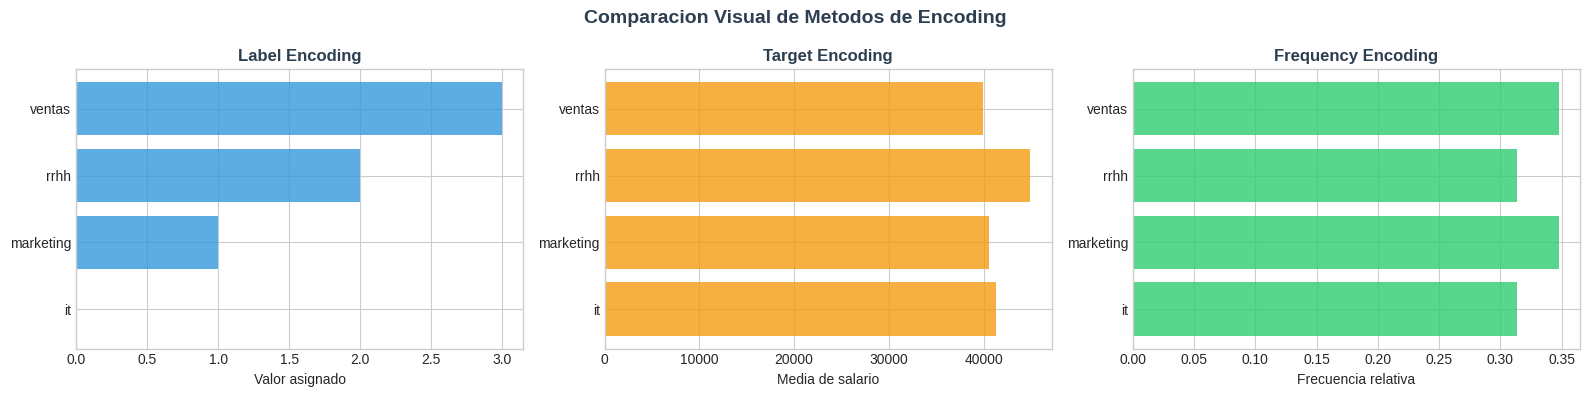

In [22]:
# === TABLA COMPARATIVA DE TODOS LOS ENCODINGS ===
print("=" * 60)
print("  TABLA COMPARATIVA: Todos los Encodings")
print("=" * 60)

comparacion_enc = df_enc[['departamento', 'depto_label', 'depto_target']].drop_duplicates().sort_values('departamento')
comparacion_enc = comparacion_enc.merge(
    df_enc[['departamento', 'ciudad_freq']].drop_duplicates().groupby('departamento').first().reset_index(),
    on='departamento', how='left'
)
# Anadir one-hot
for col in df_onehot.columns:
    vals = df_onehot.groupby(df_enc['departamento'])[col].first()
    comparacion_enc = comparacion_enc.merge(
        vals.reset_index().rename(columns={'departamento': 'departamento'}),
        on='departamento', how='left'
    )

comparacion_enc.columns = ['Original', 'Label', 'Target (media salario)', 'Freq'] + list(df_onehot.columns)
display(comparacion_enc)

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Comparacion Visual de Metodos de Encoding', fontsize=14, fontweight='bold', color=C_DARK)

# Label
deptos = comparacion_enc['Original']
axes[0].barh(deptos, comparacion_enc['Label'], color=C_PRIMARY, alpha=0.8)
axes[0].set_title('Label Encoding', fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Valor asignado')

# Target
axes[1].barh(deptos, comparacion_enc['Target (media salario)'], color=C_ORANGE, alpha=0.8)
axes[1].set_title('Target Encoding', fontweight='bold', color=C_DARK)
axes[1].set_xlabel('Media de salario')

# Frequency
axes[2].barh(deptos, comparacion_enc['Freq'], color=C_SUCCESS, alpha=0.8)
axes[2].set_title('Frequency Encoding', fontweight='bold', color=C_DARK)
axes[2].set_xlabel('Frecuencia relativa')

plt.tight_layout()
plt.show()

---
## Seccion 8: Escalado y Normalizacion

<div style="background: #fef9e7; padding: 20px; border-left: 4px solid #f39c12; border-radius: 5px;">
<strong style="color: #2c3e50;">El escalado es crucial para modelos basados en distancias o gradientes.</strong> Sin escalado, una variable con rango [0, 100000] dominaria sobre otra con rango [0, 1], independientemente de su importancia real.
</div>

### Formulas de Escalado (con explicacion de cada simbolo)

**1. MinMaxScaler**

x_scaled = (x - x_min) / (x_max - x_min)

- **x** = el valor original que queremos escalar
- **x_min** = el valor minimo de toda la columna
- **x_max** = el valor maximo de toda la columna
- **x_scaled** = el valor resultante, siempre en el rango [0, 1]
- Si x = x_min, entonces x_scaled = 0. Si x = x_max, entonces x_scaled = 1.

**2. StandardScaler (Z-score normalization)**

z = (x - mu) / sigma

- **x** = el valor original
- **mu** = la media aritmetica de toda la columna, calculada como mu = (1/n) * sum(x_i) para i=1..n, donde n es el numero de observaciones y x_i es cada valor individual
- **sigma** = la desviacion estandar de la columna, calculada como sigma = sqrt((1/n) * sum((x_i - mu)^2)), donde sqrt es la raiz cuadrada y sum es la suma de las desviaciones cuadradas
- **z** = cuantas desviaciones estandar se aleja x de la media
- El resultado tiene media = 0 y desviacion estandar = 1

**3. RobustScaler**

x_scaled = (x - mediana) / IQR

- **x** = el valor original
- **mediana** = el valor central cuando todos los datos estan ordenados (percentil 50)
- **IQR** = rango intercuartilico = Q3 - Q1, donde Q3 es el percentil 75 y Q1 es el percentil 25
- Es robusto porque mediana e IQR no se ven afectados por valores extremos (a diferencia de media y desviacion estandar)

**4. MaxAbsScaler**

x_scaled = x / max(|x|)

- **x** = el valor original
- **max(|x|)** = el mayor valor absoluto en toda la columna
- **x_scaled** = resultado en el rango [-1, 1]
- Util para datos dispersos (sparse) porque no centra los datos (no desplaza el cero)

**5. PowerTransformer (Yeo-Johnson)**

Aplica una transformacion de potencia para hacer los datos mas gaussianos. La transformacion depende del parametro lambda (estimado automaticamente) y se comporta diferente segun el signo de x:
- Para x >= 0: si lambda distinto de 0, aplica ((x+1)^lambda - 1) / lambda; si lambda = 0, aplica log(x+1)
- Para x < 0: si lambda distinto de 2, aplica -((-x+1)^(2-lambda) - 1) / (2-lambda); si lambda = 2, aplica -log(-x+1)
- **lambda** = parametro de forma estimado por maxima verosimilitud para lograr normalidad
- **x** = valor original
- A diferencia de Box-Cox, Yeo-Johnson acepta valores negativos

In [23]:
# === DEMO: Efecto del escalado en un ejemplo numerico ===
print("=" * 60)
print("  DEMO: Efecto numerico del escalado paso a paso")
print("=" * 60)

# Ejemplo pequeno para entender cada formula
ejemplo = pd.DataFrame({
    'edad': [25, 30, 35, 40, 50],
    'salario': [20000, 35000, 42000, 55000, 80000]
})

print("\nDatos originales:")
display(ejemplo)

# MinMaxScaler paso a paso
print("\n--- MinMaxScaler: x_scaled = (x - x_min) / (x_max - x_min) ---")
for col in ejemplo.columns:
    x_min = ejemplo[col].min()
    x_max = ejemplo[col].max()
    print(f"\n  {col}: x_min={x_min}, x_max={x_max}")
    for val in ejemplo[col]:
        scaled = (val - x_min) / (x_max - x_min)
        print(f"    ({val} - {x_min}) / ({x_max} - {x_min}) = {scaled:.4f}")

# StandardScaler paso a paso
print("\n--- StandardScaler: z = (x - mu) / sigma ---")
for col in ejemplo.columns:
    mu = ejemplo[col].mean()
    sigma = ejemplo[col].std(ddof=0)  # ddof=0 como sklearn
    print(f"\n  {col}: mu={mu:.1f}, sigma={sigma:.1f}")
    for val in ejemplo[col]:
        z = (val - mu) / sigma
        print(f"    ({val} - {mu:.1f}) / {sigma:.1f} = {z:.4f}")

# RobustScaler paso a paso
print("\n--- RobustScaler: x_scaled = (x - mediana) / IQR ---")
for col in ejemplo.columns:
    med = ejemplo[col].median()
    q1 = ejemplo[col].quantile(0.25)
    q3 = ejemplo[col].quantile(0.75)
    iqr = q3 - q1
    print(f"\n  {col}: mediana={med}, Q1={q1}, Q3={q3}, IQR={iqr}")
    for val in ejemplo[col]:
        scaled = (val - med) / iqr
        print(f"    ({val} - {med}) / {iqr} = {scaled:.4f}")

  DEMO: Efecto numerico del escalado paso a paso

Datos originales:


,edad,salario
0,25,20000
1,30,35000
2,35,42000
3,40,55000
4,50,80000



--- MinMaxScaler: x_scaled = (x - x_min) / (x_max - x_min) ---

  edad: x_min=25, x_max=50
    (25 - 25) / (50 - 25) = 0.0000
    (30 - 25) / (50 - 25) = 0.2000
    (35 - 25) / (50 - 25) = 0.4000
    (40 - 25) / (50 - 25) = 0.6000
    (50 - 25) / (50 - 25) = 1.0000

  salario: x_min=20000, x_max=80000
    (20000 - 20000) / (80000 - 20000) = 0.0000
    (35000 - 20000) / (80000 - 20000) = 0.2500
    (42000 - 20000) / (80000 - 20000) = 0.3667
    (55000 - 20000) / (80000 - 20000) = 0.5833
    (80000 - 20000) / (80000 - 20000) = 1.0000

--- StandardScaler: z = (x - mu) / sigma ---

  edad: mu=36.0, sigma=8.6
    (25 - 36.0) / 8.6 = -1.2787
    (30 - 36.0) / 8.6 = -0.6975
    (35 - 36.0) / 8.6 = -0.1162
    (40 - 36.0) / 8.6 = 0.4650
    (50 - 36.0) / 8.6 = 1.6275

  salario: mu=46400.0, sigma=20244.5
    (20000 - 46400.0) / 20244.5 = -1.3041
    (35000 - 46400.0) / 20244.5 = -0.5631
    (42000 - 46400.0) / 20244.5 = -0.2173
    (55000 - 46400.0) / 20244.5 = 0.4248
    (80000 - 46400.0) / 

In [24]:
# === APLICAR TODOS LOS SCALERS ===
print("=" * 60)
print("  COMPARACION DE SCALERS")
print("=" * 60)

# Preparar datos numericos limpios
df_scale = df_dirty[['edad', 'salario', 'evaluacion']].dropna().copy()
print(f"\nDatos originales:")
display(df_scale.describe().round(2))

# Aplicar cada scaler
scalers = {
    'MinMax': MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust': RobustScaler(),
    'MaxAbs': MaxAbsScaler(),
    'PowerTransformer': PowerTransformer(method='yeo-johnson'),
}

resultados = {}
for nombre, scaler in scalers.items():
    scaled = pd.DataFrame(scaler.fit_transform(df_scale), columns=df_scale.columns)
    resultados[nombre] = scaled
    print(f"\n--- {nombre}Scaler ---")
    print(f"  Rango edad:    [{scaled['edad'].min():.4f}, {scaled['edad'].max():.4f}]")
    print(f"  Rango salario: [{scaled['salario'].min():.4f}, {scaled['salario'].max():.4f}]")
    print(f"  Media edad:    {scaled['edad'].mean():.4f}, Std: {scaled['edad'].std():.4f}")

# Tabla resumen
print("\n" + "=" * 60)
print("  TABLA RESUMEN: Rango y estadisticas por scaler")
print("=" * 60)
resumen_scalers = []
for nombre, df_s in resultados.items():
    for col in df_s.columns:
        resumen_scalers.append({
            'Scaler': nombre, 'Variable': col,
            'Min': df_s[col].min(), 'Max': df_s[col].max(),
            'Media': df_s[col].mean(), 'Std': df_s[col].std()
        })
display(pd.DataFrame(resumen_scalers).round(4))

  COMPARACION DE SCALERS

Datos originales:


,edad,salario,evaluacion
count,404.00,404.00,404.00
mean,35.87,43123.15,5.52
std,13.95,38526.42,2.48
min,-5.00,9348.27,1.00
25%,27.00,25919.08,3.40
50%,34.00,36695.77,5.50
75%,44.00,49809.65,7.70
max,150.00,500000.00,10.00



--- MinMaxScaler ---
  Rango edad:    [0.0000, 1.0000]
  Rango salario: [0.0000, 1.0000]
  Media edad:    0.2637, Std: 0.0900

--- StandardScaler ---
  Rango edad:    [-2.9329, 8.1904]
  Rango salario: [-0.8778, 11.8735]
  Media edad:    0.0000, Std: 1.0012

--- RobustScaler ---
  Rango edad:    [-2.2941, 6.8235]
  Rango salario: [-1.1447, 19.3928]
  Media edad:    0.1099, Std: 0.8207

--- MaxAbsScaler ---
  Rango edad:    [-0.0333, 1.0000]
  Rango salario: [0.0187, 1.0000]
  Media edad:    0.2391, Std: 0.0930

--- PowerTransformerScaler ---
  Rango edad:    [-4.2703, 6.7767]
  Rango salario: [-3.1406, 3.8476]
  Media edad:    0.0000, Std: 1.0012

  TABLA RESUMEN: Rango y estadisticas por scaler


,Scaler,Variable,Min,Max,Media,Std
0,MinMax,edad,0.0000,1.0000,0.2637,0.0900
1,MinMax,salario,0.0000,1.0000,0.0688,0.0785
2,MinMax,evaluacion,0.0000,1.0000,0.5021,0.2760
3,Standard,edad,-2.9329,8.1904,0.0000,1.0012
4,Standard,salario,-0.8778,11.8735,-0.0000,1.0012
5,Standard,evaluacion,-1.8215,1.8061,0.0000,1.0012
6,Robust,edad,-2.2941,6.8235,0.1099,0.8207
7,Robust,salario,-1.1447,19.3928,0.2690,1.6126
8,Robust,evaluacion,-1.0465,1.0465,0.0044,0.5777
9,MaxAbs,edad,-0.0333,1.0000,0.2391,0.0930


### Cual scaler elegir? Arbol de decision

<div style="background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">

1. **Hay outliers significativos?**
   - Si -> **RobustScaler** (usa mediana e IQR, inmune a outliers)
   - No -> continuar

2. **La distribucion es muy sesgada (asimetrica)?**
   - Si -> **PowerTransformer** (la hace mas gaussiana primero)
   - No -> continuar

3. **Necesitas valores en [0, 1]?**
   - Si -> **MinMaxScaler** (garantiza rango exacto)
   - No -> continuar

4. **Los datos son sparse (muchos ceros)?**
   - Si -> **MaxAbsScaler** (no centra, preserva la dispersión)
   - No -> **StandardScaler** (la opcion por defecto mas segura)

**En caso de duda, StandardScaler es la opcion mas segura.** Es la eleccion por defecto de la mayoria de practicantes de ML.
</div>

### fit(), transform(), fit_transform() y Data Leakage

<div style="background: #fdedec; padding: 20px; border-left: 4px solid #e74c3c; border-radius: 5px;">
<strong style="color: #2c3e50;">Data Leakage (fuga de datos) ocurre cuando informacion del conjunto de test "se filtra" al entrenamiento.</strong>

El error mas comun es hacer `fit_transform()` en TODO el dataset antes de dividirlo en train/test. Esto significa que la media, desviacion estandar, min, max del scaler incluyen datos del test, dando al modelo informacion que no deberia tener.

**La regla de oro:**
1. Dividir datos en train y test PRIMERO
2. `fit()` solo en train (aprende los parametros: media, std, min, max)
3. `transform()` en train y test (aplica la misma transformacion a ambos)
4. NUNCA hacer `fit()` en test

| Metodo | Que hace | Cuando usarlo |
|--------|---------|---------------|
| `fit(X_train)` | Calcula parametros (media, std, etc.) desde X_train | Solo en datos de entrenamiento |
| `transform(X)` | Aplica la transformacion usando parametros ya calculados | En train Y en test |
| `fit_transform(X_train)` | Equivale a fit(X_train) + transform(X_train) | Solo en datos de entrenamiento |
</div>

### Que modelos necesitan escalado?

| Modelo | Necesita escalado? | Por que |
|--------|-------------------|---------|
| Regresion Lineal/Logistica | Si (para regularizacion) | L1/L2 penalizan coeficientes; sin escalar, variables grandes dominan |
| KNN | Si | Usa distancia euclidiana; variables con mayor rango dominan |
| SVM | Si | Kernel y margen dependen de distancias |
| Redes Neuronales | Si | Gradiente descendente converge mas rapido con datos escalados |
| Arboles de decision | No | Splits se basan en umbrales, no en magnitud |
| Random Forest / XGBoost | No | Son conjuntos de arboles |
| Naive Bayes | No | Se basa en probabilidades, no en distancias |

### Errores comunes en escalado

<div style="background: #fdedec; padding: 15px; border-left: 4px solid #e74c3c; border-radius: 5px;">

**Error 1: Escalar antes de dividir train/test (Data Leakage).**
El scaler "ve" datos del test, contaminando las estadisticas de entrenamiento.

**Error 2: Escalar la variable target en regresion.**
Solo se escalan las features (X), no el target (y). Si se escala el target, las predicciones estaran en la escala transformada.

**Error 3: Usar MinMaxScaler con outliers extremos.**
Un outlier como salario=500000 hara que todos los demas valores se compriman cerca de 0. Usar RobustScaler en su lugar.

**Error 4: Escalar variables binarias o one-hot encoded.**
Las columnas 0/1 ya estan en un rango util. Escalarlas no aporta valor y dificulta la interpretacion.

**Error 5: No guardar el scaler para produccion.**
El mismo objeto scaler (con los mismos parametros de fit) debe usarse para transformar datos nuevos en produccion. Usar `joblib.dump(scaler, 'scaler.pkl')`.
</div>

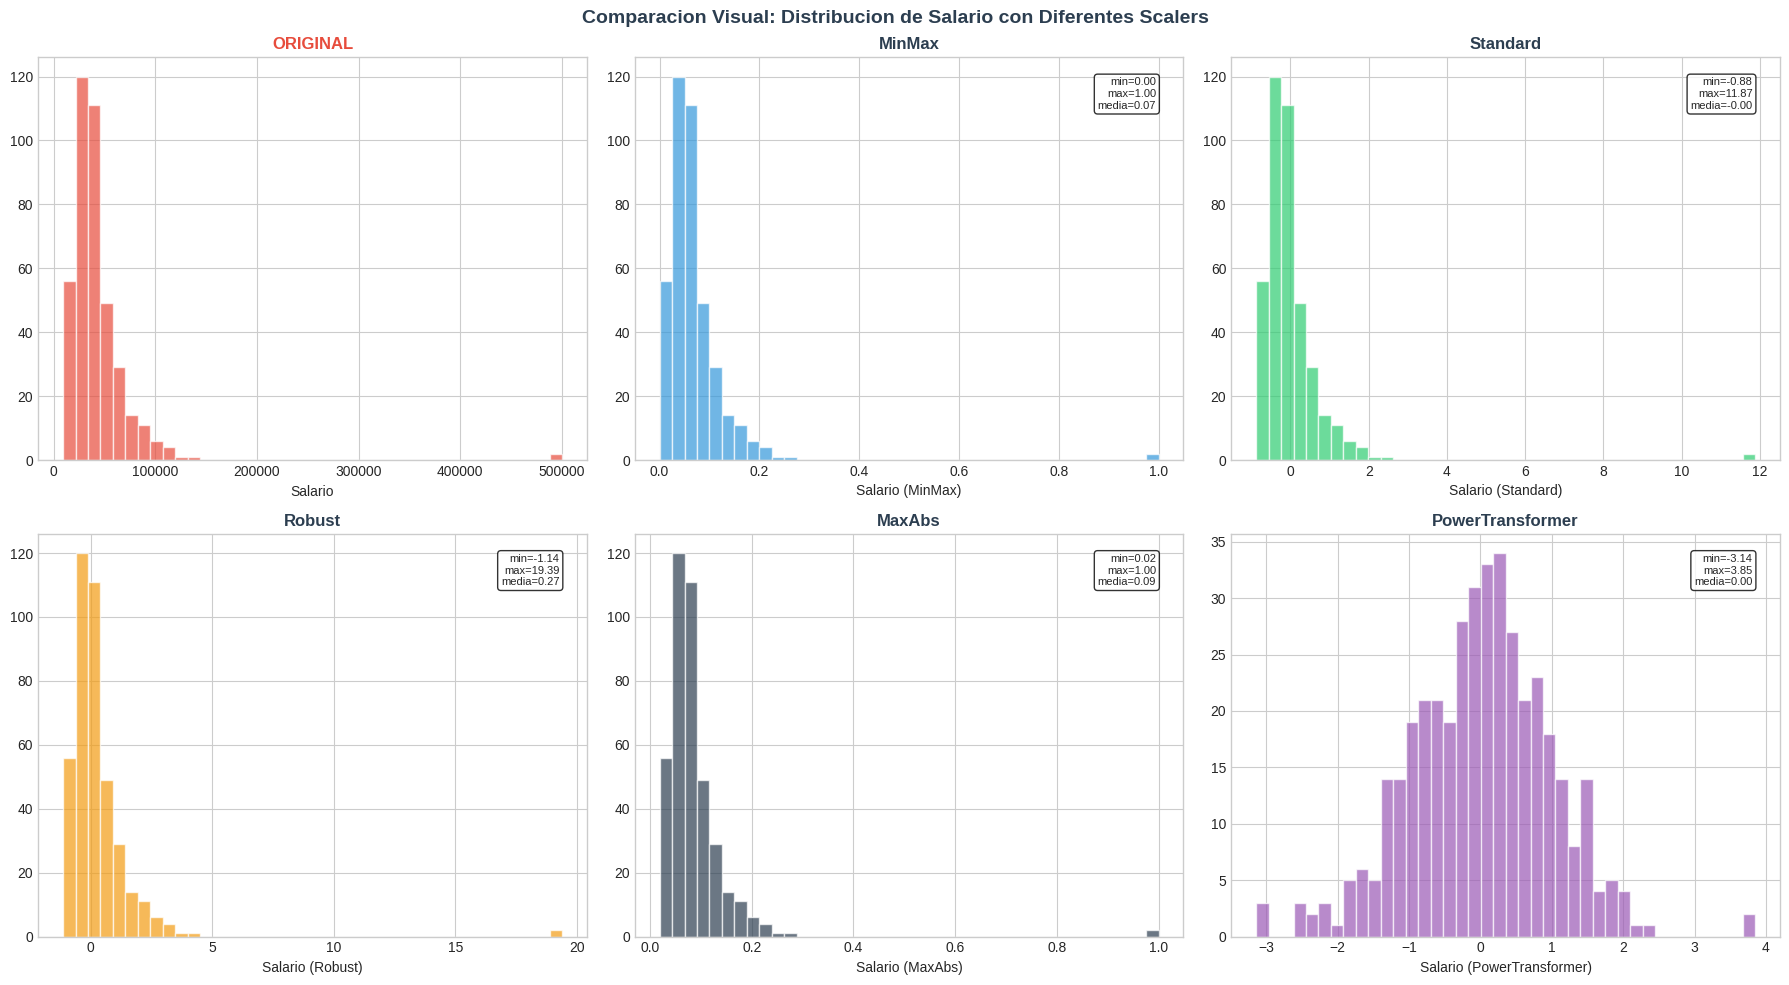

  DEMO: fit/transform CORRECTO vs INCORRECTO

INCORRECTO (fit en todo el dataset):
  Media usada para escalar: 43123.15

CORRECTO (fit solo en train):
  Media usada para escalar: 42836.95
  Diferencia de medias: 286.21

  X_train escalado: media=0.0000, std=1.0000
  X_test escalado:  media=0.0428, std=1.6290
  (El test NO tiene media=0 ni std=1, porque usa los parametros del train)


In [25]:
# === VISUALIZACION COMPARATIVA DE SCALERS ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparacion Visual: Distribucion de Salario con Diferentes Scalers',
             fontsize=14, fontweight='bold', color=C_DARK)

# Original
axes[0, 0].hist(df_scale['salario'], bins=40, color=C_DANGER, alpha=0.7, edgecolor='white')
axes[0, 0].set_title('ORIGINAL', fontweight='bold', color=C_DANGER)
axes[0, 0].set_xlabel('Salario')

colores = [C_PRIMARY, C_SUCCESS, C_ORANGE, C_DARK, '#9b59b6']
posiciones = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for (nombre, df_s), color, pos in zip(resultados.items(), colores, posiciones):
    axes[pos].hist(df_s['salario'], bins=40, color=color, alpha=0.7, edgecolor='white')
    axes[pos].set_title(f'{nombre}', fontweight='bold', color=C_DARK)
    axes[pos].set_xlabel(f'Salario ({nombre})')
    stats_text = f'min={df_s["salario"].min():.2f}\nmax={df_s["salario"].max():.2f}\nmedia={df_s["salario"].mean():.2f}'
    axes[pos].text(0.95, 0.95, stats_text, transform=axes[pos].transAxes,
                   fontsize=8, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# === DEMO: fit/transform CORRECTO vs INCORRECTO ===
print("=" * 60)
print("  DEMO: fit/transform CORRECTO vs INCORRECTO")
print("=" * 60)

from sklearn.model_selection import train_test_split

X = df_scale.copy()
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# INCORRECTO: fit_transform en todo
scaler_mal = StandardScaler()
X_todo_scaled = scaler_mal.fit_transform(X)  # MAL: fit en todo
print(f"\nINCORRECTO (fit en todo el dataset):")
print(f"  Media usada para escalar: {scaler_mal.mean_[1]:.2f}")

# CORRECTO: fit solo en train
scaler_bien = StandardScaler()
X_train_scaled = scaler_bien.fit_transform(X_train)  # fit solo en train
X_test_scaled = scaler_bien.transform(X_test)         # transform en test

print(f"\nCORRECTO (fit solo en train):")
print(f"  Media usada para escalar: {scaler_bien.mean_[1]:.2f}")
print(f"  Diferencia de medias: {abs(scaler_mal.mean_[1] - scaler_bien.mean_[1]):.2f}")
print(f"\n  X_train escalado: media={X_train_scaled[:, 1].mean():.4f}, std={X_train_scaled[:, 1].std():.4f}")
print(f"  X_test escalado:  media={X_test_scaled[:, 1].mean():.4f}, std={X_test_scaled[:, 1].std():.4f}")
print(f"  (El test NO tiene media=0 ni std=1, porque usa los parametros del train)")

  DEMO: Por que KNN necesita escalado
Sin escalado:
  La distancia esta dominada por 'salario' (rango 20000-80000)
  vs 'edad' (rango 20-60)
  Los 5 vecinos mas cercanos son aquellos con salario similar,
  INDEPENDIENTEMENTE de la edad.

Con escalado:
  Ambas variables contribuyen equitativamente a la distancia.
  Los vecinos son cercanos tanto en edad como en salario.


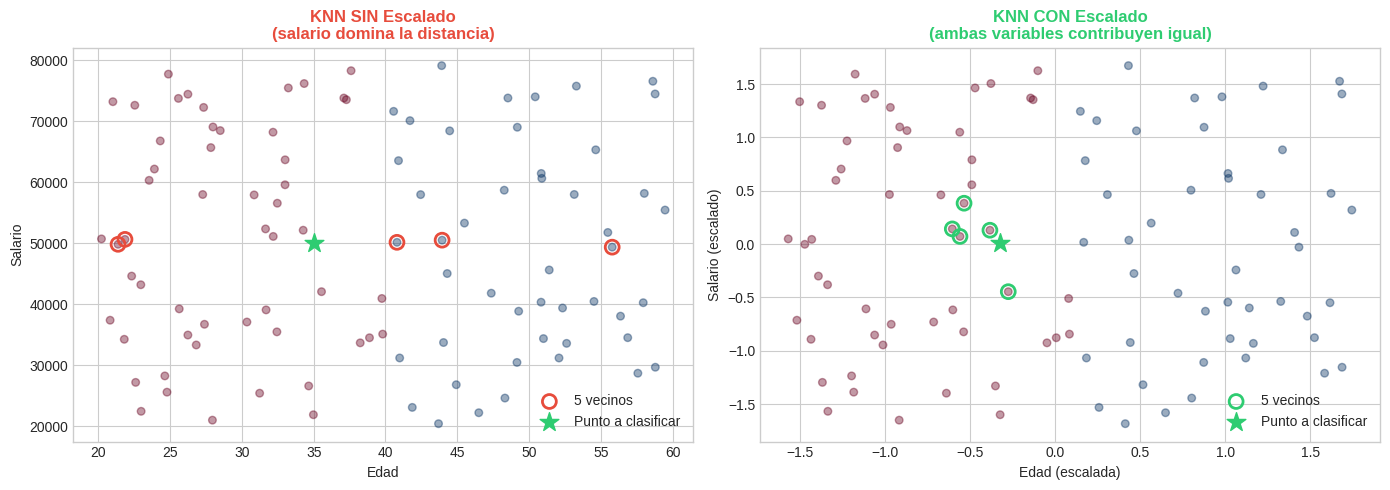

In [26]:
# === EFECTO DEL ESCALADO EN KNN: Demo visual ===
print("=" * 60)
print("  DEMO: Por que KNN necesita escalado")
print("=" * 60)

# Datos sin escalar
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)
n_demo = 100
X_demo = pd.DataFrame({
    'edad': np.random.uniform(20, 60, n_demo),
    'salario': np.random.uniform(20000, 80000, n_demo),
})
y_demo = (X_demo['edad'] > 40).astype(int)

# Punto a clasificar
punto = pd.DataFrame({'edad': [35], 'salario': [50000]})

# Distancia euclidiana sin escalar
dist_sin = np.sqrt((X_demo['edad'] - 35)**2 + (X_demo['salario'] - 50000)**2)
vecinos_sin = dist_sin.nsmallest(5).index

# Distancia euclidiana con escalado
scaler_demo = StandardScaler()
X_scaled_demo = pd.DataFrame(scaler_demo.fit_transform(X_demo), columns=X_demo.columns)
punto_scaled = scaler_demo.transform(punto)
dist_con = np.sqrt((X_scaled_demo['edad'] - punto_scaled[0][0])**2 + 
                    (X_scaled_demo['salario'] - punto_scaled[0][1])**2)
vecinos_con = dist_con.nsmallest(5).index

print("Sin escalado:")
print(f"  La distancia esta dominada por 'salario' (rango 20000-80000)")
print(f"  vs 'edad' (rango 20-60)")
print(f"  Los 5 vecinos mas cercanos son aquellos con salario similar,")
print(f"  INDEPENDIENTEMENTE de la edad.")

print("\nCon escalado:")
print(f"  Ambas variables contribuyen equitativamente a la distancia.")
print(f"  Los vecinos son cercanos tanto en edad como en salario.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin escalar
axes[0].scatter(X_demo['edad'], X_demo['salario'], c=y_demo, cmap='RdBu', alpha=0.4, s=30)
axes[0].scatter(X_demo.loc[vecinos_sin, 'edad'], X_demo.loc[vecinos_sin, 'salario'],
               c='none', edgecolors=C_DANGER, s=100, linewidths=2, label='5 vecinos')
axes[0].scatter(35, 50000, c=C_SUCCESS, s=200, marker='*', zorder=5, label='Punto a clasificar')
axes[0].set_title('KNN SIN Escalado\n(salario domina la distancia)', fontweight='bold', color=C_DANGER)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Salario')
axes[0].legend()

# Con escalar
axes[1].scatter(X_scaled_demo['edad'], X_scaled_demo['salario'], c=y_demo, cmap='RdBu', alpha=0.4, s=30)
axes[1].scatter(X_scaled_demo.loc[vecinos_con, 'edad'], X_scaled_demo.loc[vecinos_con, 'salario'],
               c='none', edgecolors=C_SUCCESS, s=100, linewidths=2, label='5 vecinos')
axes[1].scatter(punto_scaled[0][0], punto_scaled[0][1], c=C_SUCCESS, s=200, marker='*', zorder=5, label='Punto a clasificar')
axes[1].set_title('KNN CON Escalado\n(ambas variables contribuyen igual)', fontweight='bold', color=C_SUCCESS)
axes[1].set_xlabel('Edad (escalada)')
axes[1].set_ylabel('Salario (escalado)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Seccion 9: Feature Engineering

<div style="background: #eafaf1; padding: 20px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Feature Engineering es el arte de crear nuevas variables a partir de las existentes.</strong> Un buen feature engineering puede mejorar dramaticamente el rendimiento de un modelo, a veces mas que cambiar el algoritmo.
</div>

### Tecnicas comunes

| Tecnica | Descripcion | Ejemplo |
|---------|-------------|---------|
| **Extraer de fechas** | Obtener anno, mes, dia, dia de la semana | `fecha.dt.month` |
| **Binning** | Convertir numerica continua en categorias | Edad -> [Joven, Adulto, Senior] |
| **Ratios** | Crear proporciones entre variables | salario / edad |
| **Log transform** | Reducir asimetria de distribuciones sesgadas | `np.log1p(salario)` |
| **Interacciones** | Multiplicar o combinar variables | edad * evaluacion |
| **Polinomicas** | Elevar variables a potencias | edad^2 |

### Cuando crear nuevas features?

<div style="background: #fef9e7; padding: 15px; border-left: 4px solid #f39c12; border-radius: 5px;">

**Feature Engineering es iterativo:** no se sabe de antemano que features seran utiles. El proceso es:

1. **Crear candidatas** basadas en conocimiento del dominio
2. **Entrenar un modelo** y evaluar importancia de features
3. **Eliminar features irrelevantes** y crear nuevas hipotesis
4. **Repetir** hasta que el rendimiento deje de mejorar

**Senales de que necesitas feature engineering:**
- El modelo tiene un rendimiento mediocre con las features originales
- Hay informacion implicita en las fechas (estacionalidad, dia de la semana)
- Variables numericas tienen relaciones no lineales con el target
- El dominio del negocio sugiere ratios o combinaciones relevantes
</div>

  FEATURE ENGINEERING: Creacion de nuevas variables

--- 1. Extraer de fechas ---
Nuevas columnas de fecha:


,fecha_parsed,anno,mes,dia_semana,trimestre,es_fin_semana
0,2020-01-18,2020,1,5,1,1
1,2020-04-21,2020,4,1,2,0
2,2020-04-01,2020,4,2,2,0
3,2020-10-26,2020,10,0,4,0
4,2020-04-23,2020,4,3,2,0



--- 2. Binning: edad en categorias ---
Distribucion de grupos de edad:
grupo_edad
Joven        69
Adulto      130
Senior      126
Veterano     53
Name: count, dtype: int64

Distribucion de salario por cuartiles:
salario_cuartil
Q1    95
Q2    95
Q3    95
Q4    95
Name: count, dtype: int64

--- 3. Ratios ---
salario_por_edad: media=1,559
evaluacion_salario: media=23,537

--- 4. Transformacion logaritmica ---


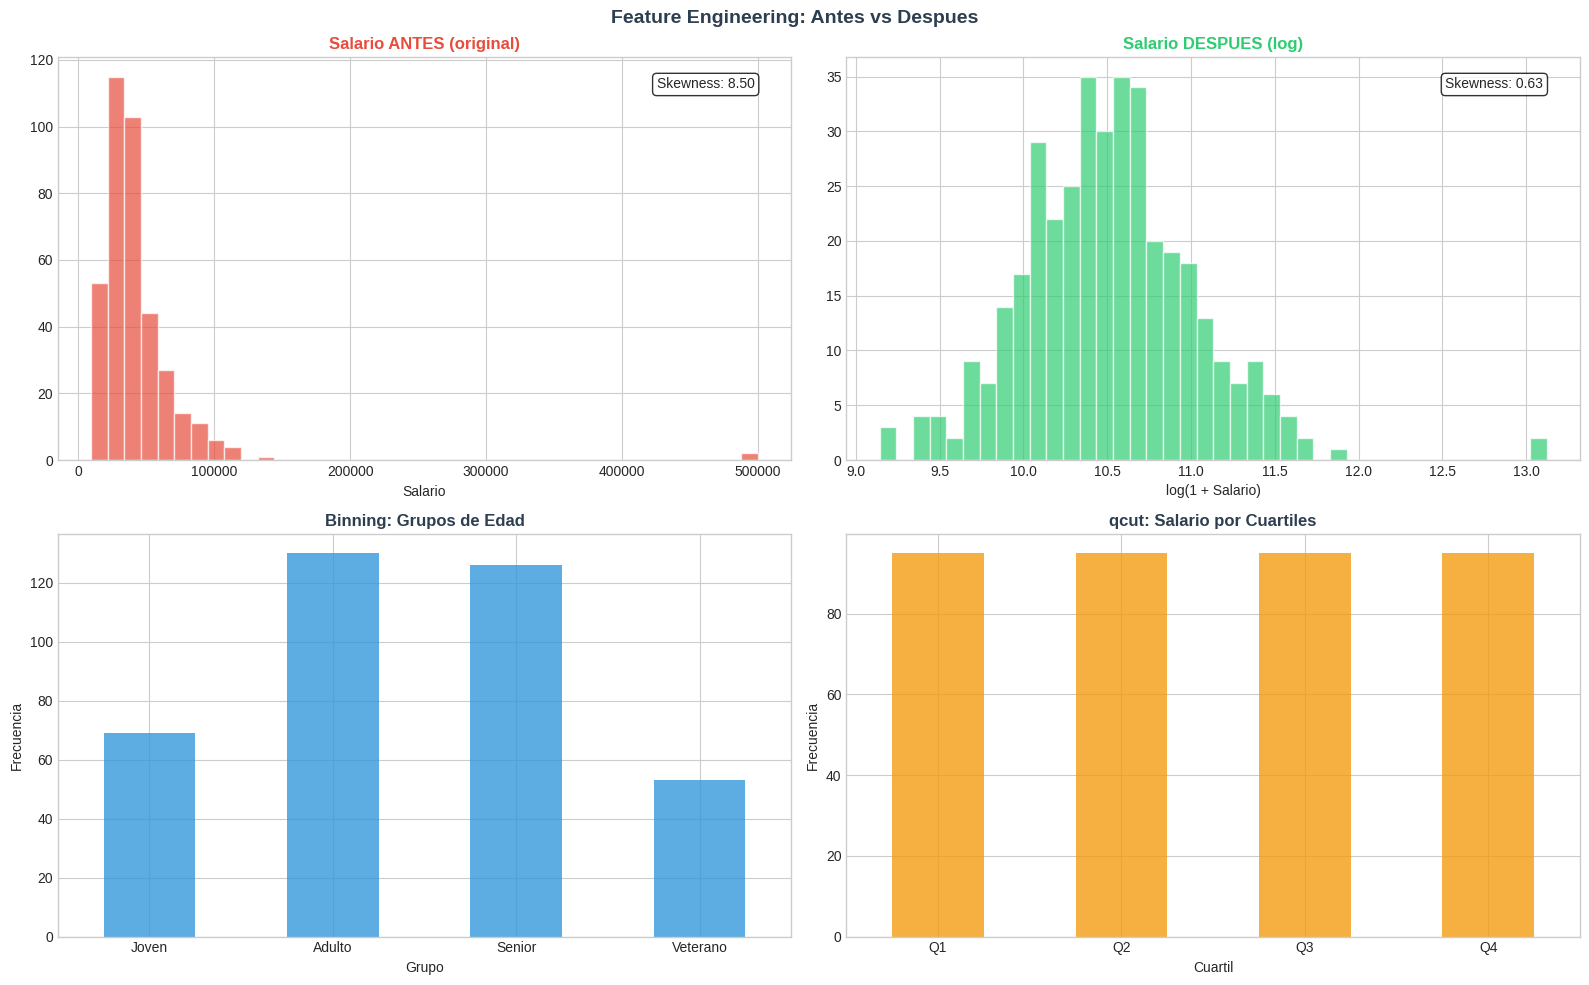


Resumen: 11 nuevas variables creadas


In [27]:
# === FEATURE ENGINEERING ===
df_fe = df_dirty.copy()
df_fe['departamento'] = df_fe['departamento'].str.lower().str.strip()
df_fe['fecha_parsed'] = pd.to_datetime(df_fe['fecha_ingreso'], format='mixed', dayfirst=True, errors='coerce')
df_fe = df_fe.dropna(subset=['edad', 'salario', 'evaluacion', 'fecha_parsed']).reset_index(drop=True)

print("=" * 60)
print("  FEATURE ENGINEERING: Creacion de nuevas variables")
print("=" * 60)

# --- 1. Extraer componentes de fechas ---
print("\n--- 1. Extraer de fechas ---")
df_fe['anno'] = df_fe['fecha_parsed'].dt.year
df_fe['mes'] = df_fe['fecha_parsed'].dt.month
df_fe['dia_semana'] = df_fe['fecha_parsed'].dt.dayofweek  # 0=lunes, 6=domingo
df_fe['trimestre'] = df_fe['fecha_parsed'].dt.quarter
df_fe['es_fin_semana'] = (df_fe['dia_semana'] >= 5).astype(int)

print("Nuevas columnas de fecha:")
display(df_fe[['fecha_parsed', 'anno', 'mes', 'dia_semana', 'trimestre', 'es_fin_semana']].head())

# --- 2. Binning (discretizacion) ---
print("\n--- 2. Binning: edad en categorias ---")
bins = [0, 25, 35, 50, 120]
labels = ['Joven', 'Adulto', 'Senior', 'Veterano']
df_fe['grupo_edad'] = pd.cut(df_fe['edad'], bins=bins, labels=labels)
print("Distribucion de grupos de edad:")
print(df_fe['grupo_edad'].value_counts().sort_index())

# qcut: bins de igual frecuencia
df_fe['salario_cuartil'] = pd.qcut(df_fe['salario'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(f"\nDistribucion de salario por cuartiles:")
print(df_fe['salario_cuartil'].value_counts().sort_index())

# --- 3. Ratios ---
print("\n--- 3. Ratios ---")
df_fe['salario_por_edad'] = df_fe['salario'] / df_fe['edad']
df_fe['evaluacion_salario'] = df_fe['evaluacion'] * df_fe['salario'] / 10
print(f"salario_por_edad: media={df_fe['salario_por_edad'].mean():,.0f}")
print(f"evaluacion_salario: media={df_fe['evaluacion_salario'].mean():,.0f}")

# --- 4. Transformacion logaritmica ---
print("\n--- 4. Transformacion logaritmica ---")
df_fe['log_salario'] = np.log1p(df_fe['salario'])  # log1p = log(1+x), evita log(0)

# Comparacion visual ANTES/DESPUES
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Engineering: Antes vs Despues', fontsize=14, fontweight='bold', color=C_DARK)

# Log transform
axes[0, 0].hist(df_fe['salario'], bins=40, color=C_DANGER, alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Salario ANTES (original)', fontweight='bold', color=C_DANGER)
axes[0, 0].set_xlabel('Salario')
skew_antes = df_fe['salario'].skew()
axes[0, 0].text(0.95, 0.95, f'Skewness: {skew_antes:.2f}', transform=axes[0, 0].transAxes,
                fontsize=10, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0, 1].hist(df_fe['log_salario'], bins=40, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Salario DESPUES (log)', fontweight='bold', color=C_SUCCESS)
axes[0, 1].set_xlabel('log(1 + Salario)')
skew_despues = df_fe['log_salario'].skew()
axes[0, 1].text(0.95, 0.95, f'Skewness: {skew_despues:.2f}', transform=axes[0, 1].transAxes,
                fontsize=10, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Binning
df_fe['grupo_edad'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color=C_PRIMARY, alpha=0.8)
axes[1, 0].set_title('Binning: Grupos de Edad', fontweight='bold', color=C_DARK)
axes[1, 0].set_xlabel('Grupo')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=0)

# Salario por cuartil
df_fe['salario_cuartil'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color=C_ORANGE, alpha=0.8)
axes[1, 1].set_title('qcut: Salario por Cuartiles', fontweight='bold', color=C_DARK)
axes[1, 1].set_xlabel('Cuartil')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nResumen: {len([c for c in df_fe.columns if c not in df_dirty.columns])} nuevas variables creadas")

  FEATURE ENGINEERING AVANZADO

--- Interacciones entre variables ---
edad_x_evaluacion: correlacion con salario = -0.061
salario_por_evaluacion: correlacion con edad = -0.005

--- Variables polinomicas ---
edad^2 creada: min=1, max=22500

--- Encoding ciclico para mes (seno/coseno) ---
Los meses son ciclicos: diciembre (12) esta cerca de enero (1).
El encoding ciclico captura esta relacion usando seno y coseno:
  mes_sin = sin(2 * pi * mes / 12)
    - sin = funcion seno trigonometrica
    - pi = 3.14159... (constante matematica)
    - 12 = total de meses en un anno (periodo del ciclo)
  mes_cos = cos(2 * pi * mes / 12)
    - cos = funcion coseno trigonometrica
  Juntos, sin y cos crean un circulo que respeta la ciclicidad.


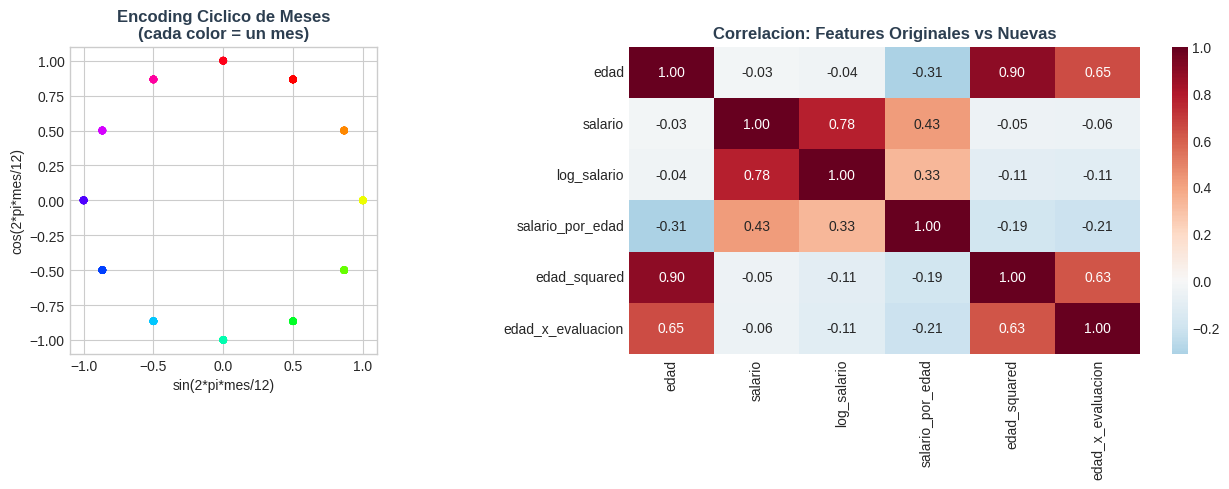


Total de features nuevas creadas: 17
  - fecha_parsed
  - anno
  - mes
  - dia_semana
  - trimestre
  - es_fin_semana
  - grupo_edad
  - salario_cuartil
  - salario_por_edad
  - evaluacion_salario
  - log_salario
  - edad_x_evaluacion
  - salario_por_evaluacion
  - edad_squared
  - log_edad
  - mes_sin
  - mes_cos


In [28]:
# === FEATURE ENGINEERING AVANZADO: Interacciones y polinomicas ===
print("=" * 60)
print("  FEATURE ENGINEERING AVANZADO")
print("=" * 60)

# Interacciones
print("\n--- Interacciones entre variables ---")
df_fe['edad_x_evaluacion'] = df_fe['edad'] * df_fe['evaluacion']
df_fe['salario_por_evaluacion'] = df_fe['salario'] / (df_fe['evaluacion'] + 0.1)

print(f"edad_x_evaluacion: correlacion con salario = {df_fe['edad_x_evaluacion'].corr(df_fe['salario']):.3f}")
print(f"salario_por_evaluacion: correlacion con edad = {df_fe['salario_por_evaluacion'].corr(df_fe['edad']):.3f}")

# Variables polinomicas
print("\n--- Variables polinomicas ---")
df_fe['edad_squared'] = df_fe['edad'] ** 2
df_fe['log_edad'] = np.log1p(df_fe['edad'])
print(f"edad^2 creada: min={df_fe['edad_squared'].min():.0f}, max={df_fe['edad_squared'].max():.0f}")

# Encoding ciclico para meses (para series temporales)
print("\n--- Encoding ciclico para mes (seno/coseno) ---")
print("Los meses son ciclicos: diciembre (12) esta cerca de enero (1).")
print("El encoding ciclico captura esta relacion usando seno y coseno:")
print("  mes_sin = sin(2 * pi * mes / 12)")
print("    - sin = funcion seno trigonometrica")
print("    - pi = 3.14159... (constante matematica)")
print("    - 12 = total de meses en un anno (periodo del ciclo)")
print("  mes_cos = cos(2 * pi * mes / 12)")
print("    - cos = funcion coseno trigonometrica")
print("  Juntos, sin y cos crean un circulo que respeta la ciclicidad.")

df_fe['mes_sin'] = np.sin(2 * np.pi * df_fe['mes'] / 12)
df_fe['mes_cos'] = np.cos(2 * np.pi * df_fe['mes'] / 12)

# Visualizar encoding ciclico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot del encoding ciclico
axes[0].scatter(df_fe['mes_sin'], df_fe['mes_cos'], c=df_fe['mes'], cmap='hsv', alpha=0.5, s=20)
axes[0].set_xlabel('sin(2*pi*mes/12)')
axes[0].set_ylabel('cos(2*pi*mes/12)')
axes[0].set_title('Encoding Ciclico de Meses\n(cada color = un mes)', fontweight='bold', color=C_DARK)
axes[0].set_aspect('equal')

# Correlacion de nuevas features
nuevas_cols = ['edad', 'salario', 'log_salario', 'salario_por_edad', 'edad_squared', 'edad_x_evaluacion']
corr = df_fe[nuevas_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[1], fmt='.2f')
axes[1].set_title('Correlacion: Features Originales vs Nuevas', fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.show()

# Resumen de todas las features creadas
nuevas = [c for c in df_fe.columns if c not in df_dirty.columns]
print(f"\nTotal de features nuevas creadas: {len(nuevas)}")
for f in nuevas:
    print(f"  - {f}")

---
## Seccion 10: Pipelines de sklearn

<div style="background: #eaf2f8; padding: 20px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">Un Pipeline encadena pasos de preprocesamiento y modelo en un solo objeto.</strong> Esto evita data leakage, simplifica el codigo, y permite usar cross-validation de forma segura.

**ColumnTransformer** permite aplicar transformaciones diferentes a diferentes columnas en un solo paso. Combinado con Pipeline, crea un flujo de preprocesamiento completo y reproducible.
</div>

### Ventajas de usar Pipelines

| Ventaja | Sin Pipeline | Con Pipeline |
|---------|-------------|--------------|
| Data leakage | Facil de cometer errores | Imposible si se usa correctamente |
| Reproducibilidad | Multiples pasos manuales | Un solo objeto fit/transform |
| Cross-validation | Hay que repetir pasos manualmente | Automatico dentro de GridSearchCV |
| Produccion | Codigo fragil y dificil de mantener | Un solo .pkl para deploy |

### Estructura de un ColumnTransformer

<div style="background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">

```
ColumnTransformer(transformers=[
    ('nombre_paso', Pipeline_o_Transformer, lista_de_columnas),
    ...
], remainder='drop' | 'passthrough')
```

- **`transformers`**: lista de tuplas (nombre, transformador, columnas)
- **`nombre`**: identificador unico del paso (para referencia en GridSearch)
- **`Pipeline_o_Transformer`**: puede ser un solo transformer (StandardScaler) o un Pipeline con multiples pasos
- **`lista_de_columnas`**: columnas a las que se aplica ese transformador
- **`remainder='drop'`**: descarta columnas no mencionadas
- **`remainder='passthrough'`**: pasa columnas no mencionadas sin transformar

El resultado es una matriz donde las columnas transformadas se concatenan en el orden definido.
</div>

In [29]:
# === PIPELINE COMPLETO CON COLUMNTRANSFORMER ===
print("=" * 60)
print("  PIPELINE COMPLETO: ColumnTransformer + Pipeline")
print("=" * 60)

# Preparar datos
df_pipe = df_dirty.copy()
df_pipe['departamento'] = df_pipe['departamento'].str.lower().str.strip()
df_pipe['satisfaccion'] = df_pipe['satisfaccion'].str.lower().str.strip()
df_pipe['ciudad'] = df_pipe['ciudad'].str.lower().str.strip()
df_pipe = df_pipe.dropna(subset=['departamento', 'satisfaccion', 'ciudad']).reset_index(drop=True)

# Definir columnas
cols_numericas = ['edad', 'salario', 'evaluacion']
cols_categoricas_nominal = ['departamento', 'ciudad']
cols_categoricas_ordinal = ['satisfaccion']

# Pipeline para columnas numericas
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Pipeline para columnas categoricas nominales
pipeline_cat_nominal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
])

# Pipeline para columnas categoricas ordinales
pipeline_cat_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['bajo', 'medio', 'alto']])),
])

# ColumnTransformer: combinar todos los pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, cols_numericas),
        ('cat_nom', pipeline_cat_nominal, cols_categoricas_nominal),
        ('cat_ord', pipeline_cat_ordinal, cols_categoricas_ordinal),
    ],
    remainder='drop'  # 'drop' = descartar columnas no mencionadas
)

# Dividir datos
X = df_pipe[cols_numericas + cols_categoricas_nominal + cols_categoricas_ordinal]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"\nDimensiones ANTES del preprocesamiento:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

# fit_transform en train, transform en test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas resultantes
feature_names_num = cols_numericas
feature_names_cat = preprocessor.named_transformers_['cat_nom'].named_steps['onehot'].get_feature_names_out(cols_categoricas_nominal)
feature_names_ord = cols_categoricas_ordinal
all_features = list(feature_names_num) + list(feature_names_cat) + list(feature_names_ord)

print(f"\nDimensiones DESPUES del preprocesamiento:")
print(f"  X_train: {X_train_processed.shape}")
print(f"  X_test: {X_test_processed.shape}")
print(f"\nColumnas resultantes ({len(all_features)}):")
for f in all_features:
    print(f"  - {f}")

# Mostrar resultado
df_resultado = pd.DataFrame(X_train_processed, columns=all_features)
print(f"\nPrimeras 5 filas del dataset procesado:")
display(df_resultado.head())

# Pipeline completo con modelo (ejemplo)
from sklearn.linear_model import LogisticRegression

print("\n" + "=" * 60)
print("  PIPELINE COMPLETO CON MODELO (ejemplo)")
print("=" * 60)
print("""
# Ejemplo de pipeline completo (no ejecutado, solo demostrativo):

pipeline_completo = Pipeline([
    ('preprocesamiento', preprocessor),
    ('modelo', LogisticRegression(max_iter=1000))
])

# Uso:
# pipeline_completo.fit(X_train, y_train)
# predicciones = pipeline_completo.predict(X_test)
# score = pipeline_completo.score(X_test, y_test)

# Para GridSearch:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler()],
#     'modelo__C': [0.1, 1, 10],
# }
# grid = GridSearchCV(pipeline_completo, param_grid, cv=5)
# grid.fit(X_train, y_train)
""")

  PIPELINE COMPLETO: ColumnTransformer + Pipeline

Dimensiones ANTES del preprocesamiento:
  X_train: (300, 6)
  X_test: (75, 6)

Dimensiones DESPUES del preprocesamiento:
  X_train: (300, 10)
  X_test: (75, 10)

Columnas resultantes (10):
  - edad
  - salario
  - evaluacion
  - departamento_marketing
  - departamento_rrhh
  - departamento_ventas
  - ciudad_madrid
  - ciudad_sevilla
  - ciudad_valencia
  - satisfaccion

Primeras 5 filas del dataset procesado:


,edad,salario,evaluacion,departamento_marketing,departamento_rrhh,departamento_ventas,ciudad_madrid,ciudad_sevilla,ciudad_valencia,satisfaccion
0,-0.504290,0.625217,-0.027798,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.083232,-0.876963,-1.485187,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.137089,-0.988655,-0.635043,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.156673,-0.921760,1.551039,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.357410,-0.110479,0.660413,0.0,0.0,0.0,1.0,0.0,0.0,2.0



  PIPELINE COMPLETO CON MODELO (ejemplo)

# Ejemplo de pipeline completo (no ejecutado, solo demostrativo):

pipeline_completo = Pipeline([
    ('preprocesamiento', preprocessor),
    ('modelo', LogisticRegression(max_iter=1000))
])

# Uso:
# pipeline_completo.fit(X_train, y_train)
# predicciones = pipeline_completo.predict(X_test)
# score = pipeline_completo.score(X_test, y_test)

# Para GridSearch:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'preprocesamiento__num__scaler': [StandardScaler(), RobustScaler()],
#     'modelo__C': [0.1, 1, 10],
# }
# grid = GridSearchCV(pipeline_completo, param_grid, cv=5)
# grid.fit(X_train, y_train)



  VISUALIZACION DE LA ESTRUCTURA DEL PIPELINE


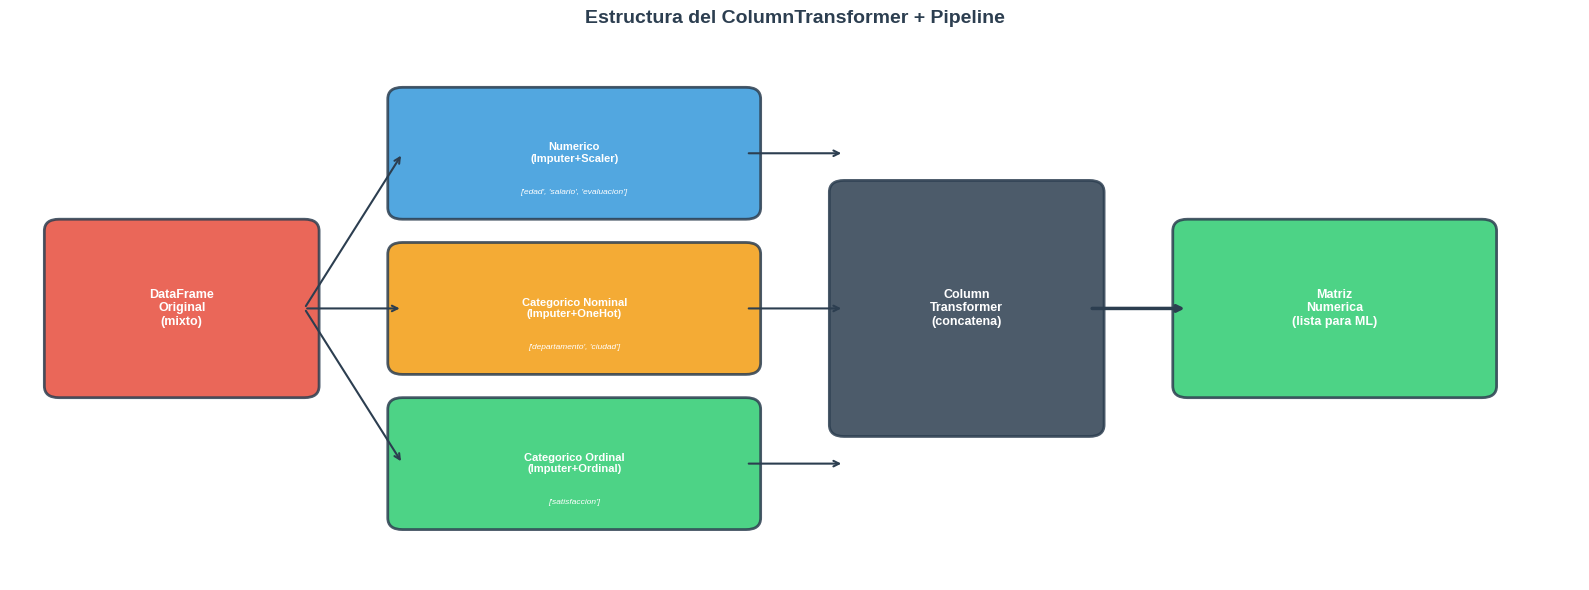


Pasos del ColumnTransformer:

  'num' -> columnas: ['edad', 'salario', 'evaluacion']
    Paso 'imputer': SimpleImputer
    Paso 'scaler': StandardScaler

  'cat_nom' -> columnas: ['departamento', 'ciudad']
    Paso 'imputer': SimpleImputer
    Paso 'onehot': OneHotEncoder

  'cat_ord' -> columnas: ['satisfaccion']
    Paso 'imputer': SimpleImputer
    Paso 'ordinal': OrdinalEncoder


In [30]:
# === VISUALIZAR ESTRUCTURA DEL PIPELINE ===
print("=" * 60)
print("  VISUALIZACION DE LA ESTRUCTURA DEL PIPELINE")
print("=" * 60)

# Diagrama del ColumnTransformer
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_title('Estructura del ColumnTransformer + Pipeline', fontsize=14,
             fontweight='bold', color=C_DARK, pad=10)

# Input
rect = mpatches.FancyBboxPatch((0.5, 2.5), 2.5, 2, boxstyle="round,pad=0.15",
                                facecolor=C_DANGER, edgecolor=C_DARK, linewidth=2, alpha=0.85)
ax.add_patch(rect)
ax.text(1.75, 3.5, 'DataFrame\nOriginal\n(mixto)', ha='center', va='center',
        fontsize=9, fontweight='bold', color='white')

# Flechas de entrada
for y in [5.5, 3.5, 1.5]:
    ax.annotate('', xy=(4, y), xytext=(3, 3.5),
                arrowprops=dict(arrowstyle='->', color=C_DARK, lw=1.5))

# Pipelines individuales
pipes = [
    ('Numerico\n(Imputer+Scaler)', C_PRIMARY, 5.5, ['edad', 'salario', 'evaluacion']),
    ('Categorico Nominal\n(Imputer+OneHot)', C_ORANGE, 3.5, ['departamento', 'ciudad']),
    ('Categorico Ordinal\n(Imputer+Ordinal)', C_SUCCESS, 1.5, ['satisfaccion']),
]

for nombre, color, y, cols in pipes:
    rect = mpatches.FancyBboxPatch((4, y-0.7), 3.5, 1.4, boxstyle="round,pad=0.15",
                                    facecolor=color, edgecolor=C_DARK, linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(5.75, y, nombre, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')
    ax.text(5.75, y-0.5, str(cols), ha='center', va='center',
            fontsize=6, color='white', style='italic')
    ax.annotate('', xy=(8.5, y), xytext=(7.5, y),
                arrowprops=dict(arrowstyle='->', color=C_DARK, lw=1.5))

# Concatenar
rect = mpatches.FancyBboxPatch((8.5, 2), 2.5, 3, boxstyle="round,pad=0.15",
                                facecolor=C_DARK, edgecolor=C_DARK, linewidth=2, alpha=0.85)
ax.add_patch(rect)
ax.text(9.75, 3.5, 'Column\nTransformer\n(concatena)', ha='center', va='center',
        fontsize=9, fontweight='bold', color='white')

# Flecha a output
ax.annotate('', xy=(12, 3.5), xytext=(11, 3.5),
            arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2.5))

# Output
rect = mpatches.FancyBboxPatch((12, 2.5), 3, 2, boxstyle="round,pad=0.15",
                                facecolor=C_SUCCESS, edgecolor=C_DARK, linewidth=2, alpha=0.85)
ax.add_patch(rect)
ax.text(13.5, 3.5, 'Matriz\nNumerica\n(lista para ML)', ha='center', va='center',
        fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# Mostrar los pasos del preprocessor
print("\nPasos del ColumnTransformer:")
for nombre, pipe, cols in preprocessor.transformers:
    print(f"\n  '{nombre}' -> columnas: {cols}")
    if hasattr(pipe, 'steps'):
        for step_name, step in pipe.steps:
            print(f"    Paso '{step_name}': {type(step).__name__}")

---
## Seccion 11: SQL vs Python - Tabla Comparativa

<div style="background: #fef9e7; padding: 20px; border-left: 4px solid #f39c12; border-radius: 5px;">
<strong style="color: #2c3e50;">Muchas operaciones de limpieza se pueden hacer tanto en SQL como en Python.</strong> SQL es preferible cuando los datos estan en una base de datos y son muy grandes (procesamiento en servidor). Python/Pandas es preferible para transformaciones complejas, visualizacion, y cuando los datos caben en memoria.
</div>

### Tabla Comparativa: Misma operacion en SQL y Python

| Operacion | SQL | Python (Pandas) |
|-----------|-----|-----------------|
| **Ver primeras filas** | `SELECT * FROM tabla LIMIT 10` | `df.head(10)` |
| **Contar filas** | `SELECT COUNT(*) FROM tabla` | `len(df)` |
| **Contar nulos** | `SELECT COUNT(*) FROM tabla WHERE col IS NULL` | `df['col'].isnull().sum()` |
| **Eliminar nulos** | `DELETE FROM tabla WHERE col IS NULL` | `df.dropna(subset=['col'])` |
| **Imputar con media** | `UPDATE tabla SET col = (SELECT AVG(col) FROM tabla) WHERE col IS NULL` | `df['col'].fillna(df['col'].mean())` |
| **Eliminar duplicados** | `SELECT DISTINCT * FROM tabla` | `df.drop_duplicates()` |
| **Normalizar strings** | `SELECT LOWER(TRIM(col)) FROM tabla` | `df['col'].str.lower().str.strip()` |
| **Parsear fecha** | `SELECT CAST(col AS DATE) FROM tabla` | `pd.to_datetime(df['col'])` |
| **Filtrar outliers IQR** | `SELECT * FROM tabla WHERE col BETWEEN Q1-1.5*IQR AND Q3+1.5*IQR` | `df[(df['col'] >= lim_inf) & (df['col'] <= lim_sup)]` |
| **Group by + agregacion** | `SELECT depto, AVG(salario) FROM tabla GROUP BY depto` | `df.groupby('depto')['salario'].mean()` |
| **Renombrar columna** | `ALTER TABLE tabla RENAME COLUMN old TO new` | `df.rename(columns={'old': 'new'})` |
| **Crear columna** | `ALTER TABLE tabla ADD col2 AS col1 * 2` | `df['col2'] = df['col1'] * 2` |
| **Reemplazar valores** | `UPDATE tabla SET col = 'nuevo' WHERE col = 'viejo'` | `df['col'].replace('viejo', 'nuevo')` |
| **Encoding (CASE)** | `SELECT CASE WHEN col='A' THEN 1 ELSE 0 END FROM tabla` | `df['col'].map({'A': 1, 'B': 0})` |

### Cuando usar SQL vs Python para limpieza?

<div style="display: flex; gap: 15px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 200px; background: #eaf2f8; padding: 15px; border-left: 4px solid #3498db; border-radius: 5px;">
<strong style="color: #2c3e50;">Usar SQL cuando:</strong><br>
- Los datos estan en una base de datos relacional<br>
- El dataset tiene millones de filas (procesamiento en servidor)<br>
- Necesitas JOINs entre multiples tablas<br>
- La limpieza es simple (filtrar, agrupar, normalizar strings)<br>
- Quieres crear vistas limpias reutilizables
</div>
<div style="flex: 1; min-width: 200px; background: #eafaf1; padding: 15px; border-left: 4px solid #2ecc71; border-radius: 5px;">
<strong style="color: #2c3e50;">Usar Python cuando:</strong><br>
- Necesitas transformaciones complejas (encoding, scaling)<br>
- Quieres visualizar distribuciones y patrones<br>
- Necesitas ML-specific tools (KNN Imputer, Isolation Forest)<br>
- Los datos ya estan en CSV/Parquet/memoria<br>
- Necesitas reproducibilidad con Pipelines de sklearn
</div>
</div>

In [31]:
# === EJEMPLO COMPLETO: MISMA LIMPIEZA EN SQL Y PYTHON ===
print("=" * 60)
print("  EJEMPLO: Misma limpieza en SQL vs Python")
print("=" * 60)

print("""
PROBLEMA: Obtener el salario promedio por departamento, excluyendo nulos
          y normalizando los nombres de departamento a minusculas.

--- SQL ---
SELECT 
    LOWER(TRIM(departamento)) AS departamento_clean,
    COUNT(*) AS n_empleados,
    ROUND(AVG(salario), 2) AS salario_promedio,
    ROUND(MIN(salario), 2) AS salario_min,
    ROUND(MAX(salario), 2) AS salario_max
FROM empleados
WHERE salario IS NOT NULL
  AND departamento IS NOT NULL
GROUP BY LOWER(TRIM(departamento))
ORDER BY salario_promedio DESC;

--- Python ---
""")

# Ejecutar la version Python
df_sql_demo = df_dirty.copy()
resultado_python = (
    df_sql_demo
    .dropna(subset=['salario', 'departamento'])
    .assign(departamento_clean=lambda x: x['departamento'].str.lower().str.strip())
    .groupby('departamento_clean')
    .agg(
        n_empleados=('salario', 'count'),
        salario_promedio=('salario', 'mean'),
        salario_min=('salario', 'min'),
        salario_max=('salario', 'max'),
    )
    .round(2)
    .sort_values('salario_promedio', ascending=False)
)

print("Resultado (Python):")
display(resultado_python)

print("""
Observacion: Ambas consultas producen el mismo resultado.
- SQL procesa los datos en el servidor de base de datos (escalable a millones de filas).
- Python procesa en memoria local (mas flexible para transformaciones complejas).
- Para datasets < 1M filas, ambos son viables. Para datasets mayores, SQL primero.
""")

  EJEMPLO: Misma limpieza en SQL vs Python

PROBLEMA: Obtener el salario promedio por departamento, excluyendo nulos
          y normalizando los nombres de departamento a minusculas.

--- SQL ---
SELECT 
    LOWER(TRIM(departamento)) AS departamento_clean,
    COUNT(*) AS n_empleados,
    ROUND(AVG(salario), 2) AS salario_promedio,
    ROUND(MIN(salario), 2) AS salario_min,
    ROUND(MAX(salario), 2) AS salario_max
FROM empleados
WHERE salario IS NOT NULL
  AND departamento IS NOT NULL
GROUP BY LOWER(TRIM(departamento))
ORDER BY salario_promedio DESC;

--- Python ---

Resultado (Python):


,n_empleados,salario_promedio,salario_min,salario_max
departamento_clean,,,,
rrhh,56,43661.20,11946.50,99699.80
ventas,189,41086.82,9348.27,138241.23
it,125,41015.10,9780.11,129756.73
marketing,54,40185.14,16606.40,118404.14



Observacion: Ambas consultas producen el mismo resultado.
- SQL procesa los datos en el servidor de base de datos (escalable a millones de filas).
- Python procesa en memoria local (mas flexible para transformaciones complejas).
- Para datasets < 1M filas, ambos son viables. Para datasets mayores, SQL primero.



In [32]:
# === EJEMPLO SQL AVANZADO: Limpieza con Window Functions ===
print("=" * 60)
print("  SQL AVANZADO: Window Functions para limpieza")
print("=" * 60)

print("""
--- Detectar duplicados y quedarse con el mas reciente (SQL) ---

WITH ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY LOWER(TRIM(nombre)), LOWER(TRIM(departamento))
               ORDER BY fecha_ingreso DESC
           ) AS rn
    FROM empleados
)
SELECT * FROM ranked WHERE rn = 1;

Explicacion:
  - PARTITION BY: agrupa filas que tienen el mismo nombre+departamento (normalizados)
  - ROW_NUMBER(): asigna un numero secuencial dentro de cada grupo
  - ORDER BY fecha_ingreso DESC: el mas reciente obtiene rn=1
  - WHERE rn = 1: solo mantiene la fila mas reciente de cada grupo

--- Equivalente en Python ---
""")

df_sql2 = df_dirty.copy()
df_sql2['nombre_norm'] = df_sql2['nombre'].str.lower().str.strip()
df_sql2['depto_norm'] = df_sql2['departamento'].str.lower().str.strip()
df_sql2['fecha_parsed'] = pd.to_datetime(df_sql2['fecha_ingreso'], format='mixed', dayfirst=True, errors='coerce')

# Equivalente a ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)
df_sql2 = df_sql2.sort_values('fecha_parsed', ascending=False)
df_dedup = df_sql2.drop_duplicates(subset=['nombre_norm', 'depto_norm'], keep='first')

print(f"ANTES: {len(df_sql2)} filas")
print(f"DESPUES (quedarse con el mas reciente por nombre+depto): {len(df_dedup)} filas")

print("""
--- Imputar con la media del grupo (SQL) ---

UPDATE empleados e
SET salario = (
    SELECT AVG(salario) 
    FROM empleados e2 
    WHERE LOWER(TRIM(e2.departamento)) = LOWER(TRIM(e.departamento))
      AND e2.salario IS NOT NULL
)
WHERE e.salario IS NULL;
""")

  SQL AVANZADO: Window Functions para limpieza

--- Detectar duplicados y quedarse con el mas reciente (SQL) ---

WITH ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY LOWER(TRIM(nombre)), LOWER(TRIM(departamento))
               ORDER BY fecha_ingreso DESC
           ) AS rn
    FROM empleados
)
SELECT * FROM ranked WHERE rn = 1;

Explicacion:
  - PARTITION BY: agrupa filas que tienen el mismo nombre+departamento (normalizados)
  - ROW_NUMBER(): asigna un numero secuencial dentro de cada grupo
  - ORDER BY fecha_ingreso DESC: el mas reciente obtiene rn=1
  - WHERE rn = 1: solo mantiene la fila mas reciente de cada grupo

--- Equivalente en Python ---

ANTES: 515 filas
DESPUES (quedarse con el mas reciente por nombre+depto): 30 filas

--- Imputar con la media del grupo (SQL) ---

UPDATE empleados e
SET salario = (
    SELECT AVG(salario) 
    FROM empleados e2 
    WHERE LOWER(TRIM(e2.departamento)) = LOWER(TRIM(e.departamento))
      AND e2.salario 

---
## Seccion 12: Checklist Final y Tabla Resumen

<div style="background: linear-gradient(135deg, #2c3e50 0%, #3498db 100%); padding: 25px; border-radius: 10px; color: white;">
<h3 style="color: white; margin-top: 0;">Checklist de Verificacion Pre-Modelo</h3>
<p>Antes de alimentar datos a cualquier modelo de Machine Learning, verifica cada uno de estos puntos:</p>
</div>

### Checklist obligatorio

- [ ] **Sin valores nulos** en features que se usaran en el modelo
- [ ] **Sin duplicados** no deseados
- [ ] **Tipos correctos:** numericos como float/int, categoricos como category/object, fechas como datetime
- [ ] **Outliers tratados:** eliminados, winsorizados, o transformados segun el caso
- [ ] **Strings normalizados:** sin espacios extra, en formato consistente
- [ ] **Rangos validos:** edad > 0, porcentajes entre 0-100, etc.
- [ ] **Encoding aplicado:** todas las categoricas convertidas a numerico
- [ ] **Escalado aplicado:** si el modelo lo requiere (KNN, SVM, Regresion, NN)
- [ ] **Sin data leakage:** fit solo en train, transform en train y test
- [ ] **Dimensiones verificadas:** X_train, X_test, y_train, y_test tienen las formas correctas
- [ ] **Features relevantes:** no incluir ID, columnas constantes, o features con alta correlacion con el target que representen fuga de datos

### Tabla Resumen de Todas las Tecnicas

| Etapa | Tecnica | Herramienta (Python) | Cuando usarla |
|-------|---------|---------------------|---------------|
| **Nulos** | Eliminar filas | `df.dropna()` | <5% nulos, MCAR |
| **Nulos** | Media/Mediana | `df.fillna(media)` o `SimpleImputer` | Numericas, MCAR |
| **Nulos** | Moda | `df.fillna(moda)` o `SimpleImputer(strategy='most_frequent')` | Categoricas |
| **Nulos** | KNN Imputer | `KNNImputer(n_neighbors=5)` | MAR, relaciones entre variables |
| **Nulos** | Por grupo | `df.groupby().transform(fillna)` | MAR con variable explicativa |
| **Duplicados** | Exactos | `df.drop_duplicates()` | Siempre verificar |
| **Duplicados** | Por subconjunto | `df.drop_duplicates(subset=[...])` | Claves naturales |
| **Outliers** | IQR | `Q1 - 1.5*IQR, Q3 + 1.5*IQR` | Distribucion no-normal |
| **Outliers** | Z-Score | `scipy.stats.zscore()` | Distribucion normal |
| **Outliers** | MAD | `mediana(abs(x - mediana))` | Robusto a outliers extremos |
| **Outliers** | Isolation Forest | `IsolationForest()` | Datos multivariados |
| **Outliers** | Winsorizar | `df.clip(lower, upper)` | Preservar datos pero limitar extremos |
| **Tipos** | Numerico | `pd.to_numeric(errors='coerce')` | Strings que son numeros |
| **Tipos** | Fecha | `pd.to_datetime(format='mixed')` | Fechas como strings |
| **Tipos** | Strings | `.str.lower().str.strip()` | Inconsistencias de formato |
| **Encoding** | Label | `LabelEncoder()` | Binarias u ordinales para arboles |
| **Encoding** | One-Hot | `pd.get_dummies(drop_first=True)` | Nominales, modelos lineales |
| **Encoding** | Ordinal | `OrdinalEncoder(categories=[...])` | Variables con orden natural |
| **Encoding** | Target | `groupby(cat)[target].mean()` | Alta cardinalidad, arboles |
| **Encoding** | Frequency | `value_counts(normalize=True)` | Simple, sin supuestos |
| **Escalado** | MinMax | `MinMaxScaler()` | Rango [0,1], sin outliers |
| **Escalado** | Standard | `StandardScaler()` | Media=0, std=1, general |
| **Escalado** | Robust | `RobustScaler()` | Con outliers |
| **Escalado** | MaxAbs | `MaxAbsScaler()` | Datos sparse |
| **Escalado** | Power | `PowerTransformer('yeo-johnson')` | Hacer datos mas gaussianos |
| **Features** | Fechas | `.dt.month, .dt.dayofweek` | Extraer componentes temporales |
| **Features** | Binning | `pd.cut(), pd.qcut()` | Discretizar numericas |
| **Features** | Ratios | `df['a'] / df['b']` | Crear proporciones |
| **Features** | Log | `np.log1p()` | Reducir asimetria |
| **Pipeline** | Pipeline + CT | `Pipeline + ColumnTransformer` | Siempre en produccion |

### Errores mas frecuentes en limpieza de datos (resumen)

<div style="background: #fdedec; padding: 20px; border-left: 4px solid #e74c3c; border-radius: 5px;">

| # | Error | Consecuencia | Solucion |
|---|-------|-------------|----------|
| 1 | No explorar antes de limpiar | Se omiten problemas criticos | Siempre empezar con info(), describe(), isnull() |
| 2 | Eliminar nulos sin analizar el mecanismo | Sesgo en el modelo si no es MCAR | Analizar si es MCAR, MAR o MNAR |
| 3 | Escalar antes de dividir train/test | Data leakage | fit() solo en train |
| 4 | No normalizar strings antes de encoding | Categorias duplicadas | lower().strip() antes de encoding |
| 5 | Usar Label Encoding en nominales para regresion | Orden falso entre categorias | Usar One-Hot para nominales |
| 6 | Ignorar outliers | Distorsionan media, std, y modelos | Detectar con IQR/MAD, tratar segun contexto |
| 7 | No guardar el pipeline para produccion | Resultados no reproducibles | Serializar con joblib/pickle |
| 8 | Imputar despues de dividir datos usando estadisticas globales | Data leakage sutil | Imputar dentro del Pipeline |
| 9 | No verificar el dataset final | Errores residuales | Checklist de verificacion post-limpieza |
| 10 | Feature engineering sin conocimiento del dominio | Features irrelevantes o ruidosas | Colaborar con expertos del negocio |
</div>

In [33]:
# === FUNCION COMPLETA: Limpiar dataset de principio a fin ===
print("=" * 60)
print("  FUNCION REUTILIZABLE: limpiar_dataset()")
print("=" * 60)

def limpiar_dataset(df, config=None):
    """
    Funcion completa de limpieza de datos.
    
    Parametros:
    -----------
    df : pd.DataFrame
        Dataset a limpiar
    config : dict (opcional)
        Configuracion de limpieza:
        - cols_str: columnas de texto a normalizar
        - cols_num: columnas numericas
        - cols_fecha: columnas de fecha
        - rangos: dict de {columna: (min, max)} para validacion
    
    Retorna:
    --------
    pd.DataFrame : Dataset limpio
    dict : Reporte de cambios realizados
    """
    if config is None:
        config = {}
    
    df_clean = df.copy()
    reporte = {}
    
    # 1. Eliminar duplicados
    n_antes = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    reporte['duplicados_eliminados'] = n_antes - len(df_clean)
    
    # 2. Normalizar strings
    cols_str = config.get('cols_str', df_clean.select_dtypes(include='object').columns)
    for col in cols_str:
        df_clean[col] = df_clean[col].str.lower().str.strip()
    reporte['cols_normalizadas'] = list(cols_str)
    
    # 3. Parsear fechas
    cols_fecha = config.get('cols_fecha', [])
    for col in cols_fecha:
        df_clean[col] = pd.to_datetime(df_clean[col], format='mixed', dayfirst=True, errors='coerce')
    reporte['cols_fecha_parseadas'] = cols_fecha
    
    # 4. Validar rangos
    rangos = config.get('rangos', {})
    invalidos_total = 0
    for col, (vmin, vmax) in rangos.items():
        mask = (df_clean[col] < vmin) | (df_clean[col] > vmax)
        invalidos_total += mask.sum()
        df_clean.loc[mask, col] = np.nan
    reporte['valores_invalidos_corregidos'] = invalidos_total
    
    # 5. Imputar nulos numericos con mediana
    cols_num = config.get('cols_num', df_clean.select_dtypes(include=np.number).columns)
    nulos_imputados = 0
    for col in cols_num:
        n_nulos = df_clean[col].isnull().sum()
        if n_nulos > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            nulos_imputados += n_nulos
    reporte['nulos_numericos_imputados'] = nulos_imputados
    
    # 6. Imputar nulos categoricos con moda
    for col in cols_str:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    
    reporte['forma_final'] = df_clean.shape
    reporte['nulos_restantes'] = df_clean.isnull().sum().sum()
    
    return df_clean, reporte

# Aplicar la funcion
df_limpio, reporte = limpiar_dataset(df_dirty, config={
    'cols_str': ['nombre', 'departamento', 'satisfaccion', 'ciudad'],
    'cols_num': ['edad', 'salario', 'evaluacion'],
    'cols_fecha': ['fecha_ingreso'],
    'rangos': {'edad': (0, 120)},
})

print("\nReporte de limpieza:")
for clave, valor in reporte.items():
    print(f"  {clave:.<40} {valor}")

print(f"\nDataset limpio:")
display(df_limpio.head())

  FUNCION REUTILIZABLE: limpiar_dataset()

Reporte de limpieza:
  duplicados_eliminados................... 15
  cols_normalizadas....................... ['nombre', 'departamento', 'satisfaccion', 'ciudad']
  cols_fecha_parseadas.................... ['fecha_ingreso']
  valores_invalidos_corregidos............ 2
  nulos_numericos_imputados............... 120
  forma_final............................. (500, 9)
  nulos_restantes......................... 27

Dataset limpio:


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
0,1,pedro martinez,31.0,23073.425589,ventas,2020-01-18,bajo,5.0,sevilla
1,2,ana torres,29.0,61594.486576,rrhh,2020-04-21,alto,5.3,madrid
2,3,luis sanchez,42.0,45608.292605,ventas,2020-04-01,bajo,2.9,valencia
3,4,pedro martinez,53.0,21144.784963,ventas,2020-10-26,alto,2.0,barcelona
4,5,pedro martinez,49.0,18697.442936,it,2020-04-23,bajo,8.5,valencia


  VERIFICACION FINAL: Dataset sucio -> Dataset limpio

1. Duplicados eliminados: 15 filas
2. Strings normalizados (lower + strip + title)
3. Fechas parseadas: 473 validas de 500
4. Edades invalidas marcadas como NaN: 2
5. Salario winsorizado: [16,616, 84,500]
6. Nulos imputados: 100 nulos restantes (excluyendo fecha)

  RESUMEN
  Dataset ANTES:  515 filas x 9 columnas, 372 nulos
  Dataset DESPUES: 500 filas x 9 columnas, 100 nulos (solo en fecha)
  Duplicados eliminados: 15


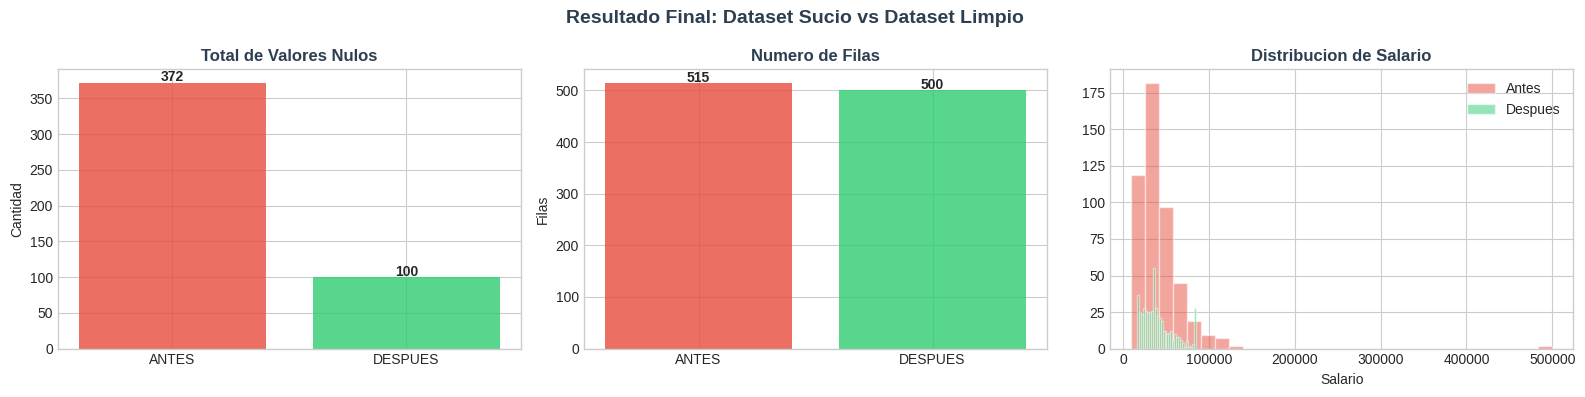


  FIN DE LA GUIA COMPLETA DE LIMPIEZA DE DATOS


In [34]:
# === VERIFICACION FINAL: Aplicar todo el pipeline al dataset sucio ===
print("=" * 70)
print("  VERIFICACION FINAL: Dataset sucio -> Dataset limpio")
print("=" * 70)

df_final = df_dirty.copy()

# Paso 1: Eliminar duplicados
n_antes = len(df_final)
df_final = df_final.drop_duplicates()
print(f"\n1. Duplicados eliminados: {n_antes - len(df_final)} filas")

# Paso 2: Normalizar strings
df_final['nombre'] = df_final['nombre'].str.strip().str.title()
df_final['departamento'] = df_final['departamento'].str.lower().str.strip()
df_final['satisfaccion'] = df_final['satisfaccion'].str.lower().str.strip()
df_final['ciudad'] = df_final['ciudad'].str.lower().str.strip()
print(f"2. Strings normalizados (lower + strip + title)")

# Paso 3: Corregir tipos y fechas
df_final['fecha_ingreso'] = pd.to_datetime(df_final['fecha_ingreso'], format='mixed', dayfirst=True, errors='coerce')
print(f"3. Fechas parseadas: {df_final['fecha_ingreso'].notna().sum()} validas de {len(df_final)}")

# Paso 4: Validar rangos
invalidos = ((df_final['edad'] < 0) | (df_final['edad'] > 120)).sum()
df_final.loc[(df_final['edad'] < 0) | (df_final['edad'] > 120), 'edad'] = np.nan
print(f"4. Edades invalidas marcadas como NaN: {invalidos}")

# Paso 5: Tratar outliers (winsorizar salario)
p5_sal = df_final['salario'].quantile(0.05)
p95_sal = df_final['salario'].quantile(0.95)
df_final['salario'] = df_final['salario'].clip(lower=p5_sal, upper=p95_sal)
print(f"5. Salario winsorizado: [{p5_sal:,.0f}, {p95_sal:,.0f}]")

# Paso 6: Imputar nulos
df_final['edad'] = df_final['edad'].fillna(df_final['edad'].median())
df_final['salario'] = df_final['salario'].fillna(df_final['salario'].median())
df_final['evaluacion'] = df_final['evaluacion'].fillna(df_final['evaluacion'].median())
df_final['satisfaccion'] = df_final['satisfaccion'].fillna(df_final['satisfaccion'].mode()[0])
df_final['departamento'] = df_final['departamento'].fillna(df_final['departamento'].mode()[0])
df_final['ciudad'] = df_final['ciudad'].fillna(df_final['ciudad'].mode()[0])
print(f"6. Nulos imputados: {df_final.isnull().sum().sum()} nulos restantes (excluyendo fecha)")

# Resumen final
print(f"\n{'=' * 70}")
print(f"  RESUMEN")
print(f"{'=' * 70}")
print(f"  Dataset ANTES:  {df_dirty.shape[0]} filas x {df_dirty.shape[1]} columnas, {df_dirty.isnull().sum().sum()} nulos")
print(f"  Dataset DESPUES: {df_final.shape[0]} filas x {df_final.shape[1]} columnas, {df_final.isnull().sum().sum()} nulos (solo en fecha)")
print(f"  Duplicados eliminados: {df_dirty.shape[0] - df_final.shape[0]}")

# Comparacion visual final
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Resultado Final: Dataset Sucio vs Dataset Limpio', fontsize=14,
             fontweight='bold', color=C_DARK)

# Nulos
nulos_antes = df_dirty.isnull().sum().sum()
nulos_despues = df_final.isnull().sum().sum()
axes[0].bar(['ANTES', 'DESPUES'], [nulos_antes, nulos_despues], 
            color=[C_DANGER, C_SUCCESS], alpha=0.8)
axes[0].set_title('Total de Valores Nulos', fontweight='bold', color=C_DARK)
axes[0].set_ylabel('Cantidad')
for i, v in enumerate([nulos_antes, nulos_despues]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Filas
axes[1].bar(['ANTES', 'DESPUES'], [df_dirty.shape[0], df_final.shape[0]], 
            color=[C_DANGER, C_SUCCESS], alpha=0.8)
axes[1].set_title('Numero de Filas', fontweight='bold', color=C_DARK)
axes[1].set_ylabel('Filas')
for i, v in enumerate([df_dirty.shape[0], df_final.shape[0]]):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Distribucion de salario
axes[2].hist(df_dirty['salario'].dropna(), bins=30, alpha=0.5, color=C_DANGER, label='Antes', edgecolor='white')
axes[2].hist(df_final['salario'].dropna(), bins=30, alpha=0.5, color=C_SUCCESS, label='Despues', edgecolor='white')
axes[2].set_title('Distribucion de Salario', fontweight='bold', color=C_DARK)
axes[2].set_xlabel('Salario')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n{'=' * 70}")
print(f"  FIN DE LA GUIA COMPLETA DE LIMPIEZA DE DATOS")
print(f"{'=' * 70}")

---

<div style="background: linear-gradient(135deg, #2c3e50 0%, #2ecc71 100%); padding: 30px; border-radius: 10px; color: white; text-align: center;">
<h2 style="color: white; margin-top: 0;">Guia Completa de Limpieza y Preprocesamiento de Datos</h2>
<p style="font-size: 16px;">
Esta guia cubrio las 12 secciones esenciales del preprocesamiento de datos:<br>
Pipeline de limpieza, exploracion, valores nulos, duplicados, outliers, tipos y validacion,<br>
encoding categorico, escalado, feature engineering, pipelines de sklearn, SQL vs Python, y checklist final.<br><br>
<strong>Recuerda:</strong> datos limpios son la base de todo modelo exitoso.
</p>
</div>